# Xenium Human Lung Cancer (FFPE) workflow in R

The same end-to-end analysis as `01_core_python.ipynb` (Python), rebuilt with R and Bioconductor tools on the same dataset. The goal is not only to translate the code but to **cross-check every key result between two independent toolchains**, and to use the R tool where it is the stronger method.

**Dataset:** 10x Genomics Xenium v1, human lung cancer (FFPE), Human Multi-Tissue and Cancer panel (377 genes), 162,254 cells, Xenium Onboard Analysis 2.0.0.

**Environment:** conda environment `spatialR_env` (R 4.5.3, Bioconductor 3.22), Jupyter kernel **R (spatialR_env)**. Every package, its version and its purpose are listed in `spatial_transcriptomic_analysis_R_packages.md`.

**Data location:** raw and processed files live outside the repository in `~/data/xenium_lung/` (R outputs in `~/data/xenium_lung/processed/R/`).

### Proposed pipeline

Step numbers match the Python notebook, so the two can be read side by side.

| # | Step | Main R / Bioconductor tools | Cross-check against the Python result |
|---|---|---|---|
| 1 | **Download Dataset A**: verify the files on disk, download only what is missing | `download.file`, `tools::md5sum` | Same files and sizes |
| 2 | **Input data overview**: annotated folder tree and a data card of every file (headers only) | `fs`, `arrow` (Parquet schemas), `hdf5r` (matrix layout), `terra` (OME-TIFF dimensions and pyramid levels) | Same file inventory |
| 3 | **Load** the Xenium bundle into a Seurat object and **explore the raw tables** (transcripts, cells, boundaries) | **Seurat `LoadXenium()`**, `arrow`, `dplyr` | Matrix total = 9,182,510 gene transcripts |
| 4 | **Quality control**: per-cell metrics, thresholds, filtering | Seurat, `cells.parquet` (cell and nucleus area) | Same thresholds keep 154,394 cells |
| 5 | **Normalise and cluster**: normalisation, PCA, Leiden, UMAP, marker genes | Seurat, **presto** (fast Wilcoxon) | Cluster agreement (ARI) with scanpy and the 10x clustering |
| 6 | **Annotate cell types**: marker scores, subclustering of T/NK and myeloid cells, reference-based labels | `AddModuleScore`, **SingleR** + **celldex** | Agreement with the Python manual annotation |
| 7 | **Spatial analysis**: neighbourhood enrichment, tissue domains / niches, immune infiltration, TLS-like aggregates | **imcRtools**, **Banksy**, `RANN`, `dbscan` | Same co-localisation and exclusion patterns |
| 8 | **Align the H&E image** with the 10x affine matrix and overlay cell types | `terra` (GDAL overviews), alignment matrix | Alignment QC (hematoxylin vs cell density: DAPI cannot be decoded in R); per-cell hematoxylin identical to Python |
| 9 | **TIME deep-dive**: checkpoint expression, CD8 T-cell states by location, spatial ligand-receptor contacts, immune phenotypes (inflamed / excluded / desert), immunosuppressive balance | `dplyr`, permutation tests, **CellChat v2** (spatial mode) | Same TIME findings (immune phenotypes identical: 65 / 26 / 9%) |
| 10 | **Spatial statistics**: Moran's I, co-occurrence, Ripley's L, network centrality, ligand-receptor analysis | `spdep` (Moran's I), **spatstat**, `igraph` | Same patterns (Moran's I rho 0.996); spatstat uses the real tissue outline instead of a convex hull |

**Where R adds something the Python notebook does not:** reference-based annotation with SingleR (Step 6), a dedicated spatial-domain method, Banksy (Step 7), spatially constrained cell-cell communication with CellChat (Step 9), and Ripley's statistics with a true tissue window in spatstat (Step 10).

**Where R is weaker:** handling very large pyramidal microscopy images (Step 8). That step is kept light and says so.

## Setup

Libraries, data locations and two plotting helpers used throughout. The cell stops with a clear message if the notebook is not running in the **R (spatialR_env)** kernel. Paths are printed relative to the home folder, never in full.

In [21]:
# This notebook needs the spatialR_env kernel
if (!grepl("spatialR_env", R.home())) stop("Wrong kernel. Use Kernel > Change Kernel > 'R (spatialR_env)'.")

suppressPackageStartupMessages({
  library(Seurat)
  library(arrow)
  library(dplyr)
  library(ggplot2)
  library(patchwork)
  library(hdf5r)
})
options(repr.plot.width = 14, repr.plot.height = 5, warn = 1)

DATA_ROOT <- path.expand("~/data/xenium_lung")
SAMPLE <- "Xenium_V1_humanLung_Cancer_FFPE"
SAMPLE_DIR <- file.path(DATA_ROOT, SAMPLE)
OUTS_DIR <- file.path(SAMPLE_DIR, "outs")
R_DIR <- file.path(DATA_ROOT, "processed", "R")          # R outputs, outside OneDrive
dir.create(R_DIR, recursive = TRUE, showWarnings = FALSE)
show_path <- function(p) sub(path.expand("~"), "~", p, fixed = TRUE)   # never print full paths

# Progress reporting for long cells. In Jupyter, base R's txtProgressBar redraws one line in place
# (the 'progress' package prints a new line per update; 'cli' / 'pbapply' bars stay silent).
SHOW_PROGRESS <- TRUE   # FALSE = no progress bars (timing lines are always printed)
progress_bar <- function(n) if (SHOW_PROGRESS) txtProgressBar(min = 0, max = n, style = 3, width = 50)
progress_tick <- function(pb, i) if (!is.null(pb)) setTxtProgressBar(pb, i)
progress_close <- function(pb) if (!is.null(pb)) { close(pb); cat("\n") }
timed <- function(label, expr) {   # evaluate one stage and print its runtime on one line
  t0 <- Sys.time(); result <- force(expr)
  cat(sprintf("  %-40s %6.0f s\n", label, as.numeric(difftime(Sys.time(), t0, units = "secs"))))
  invisible(result)
}

# Tissue map in true micron coordinates (Seurat's Image*Plot functions swap x / y by default,
# which shows this wide section in portrait); y is reversed to match the image orientation
tissue_plot <- function(obj, colour_by, title, size = 0.15) {
  xy <- GetTissueCoordinates(obj, image = "fov")
  d <- data.frame(x = xy$x / 1000, y = xy$y / 1000, value = FetchData(obj, colour_by)[xy$cell, 1])
  p <- ggplot(d, aes(x, y, colour = value)) + geom_point(size = size, stroke = 0) + coord_equal() +
    scale_y_reverse() + labs(title = title, x = "x (mm)", y = "y (mm)", colour = NULL) + theme_classic(base_size = 10)
  p
}

# Read one categorical .obs column from a Python .h5ad file (for cross-checks)
read_h5ad_obs <- function(path, column) {      # read one categorical .obs column from an .h5ad file
  h <- H5File$new(path, mode = "r"); on.exit(h$close_all())
  read_strings <- function(node)   # anndata >= 0.12 stores strings as a group (values + mask)
    if (inherits(node, "H5Group")) node[["values"]]$read() else node$read()
  ids <- read_strings(h[["obs"]][["_index"]])
  g <- h[[paste0("obs/", column)]]
  setNames(as.character(read_strings(g[["categories"]])[g[["codes"]]$read() + 1]), ids)
}

# One small panel per cluster: that cluster in colour over all other cells in grey
cluster_panels <- function(obj, cluster_col, ncol = 2) {
  xy <- GetTissueCoordinates(obj, image = "fov")
  d <- data.frame(x = xy$x / 1000, y = xy$y / 1000, cluster = FetchData(obj, cluster_col)[xy$cell, 1])
  n <- table(d$cluster)
  d$panel <- factor(sprintf("cluster %s  (%s cells, %.1f%%)", d$cluster, trimws(format(n[as.character(d$cluster)], big.mark = ",")),
                            100 * n[as.character(d$cluster)] / nrow(d)), levels = unique(sprintf(
                    "cluster %s  (%s cells, %.1f%%)", names(n), trimws(format(n, big.mark = ",")), 100 * n / nrow(d))))
  ggplot(d, aes(x, y)) +
    geom_point(data = d[, c("x", "y")], colour = "#e3e6ea", size = 0.02, stroke = 0) +
    geom_point(aes(colour = cluster), size = 0.12, stroke = 0, show.legend = FALSE) +
    facet_wrap(~panel, ncol = ncol) + coord_equal() + scale_y_reverse() + theme_void(base_size = 9) +
    theme(strip.text = element_text(hjust = 0, margin = margin(2, 0, 2, 0)))
}

cat("R", paste(R.version$major, R.version$minor, sep = "."), "| Seurat", as.character(packageVersion("Seurat")),
    "| outputs ->", show_path(R_DIR), "\n")

R 4.5.3 | Seurat 5.5.1 | outputs -> ~/data/xenium_lung/processed/R 


## Step 1: Download Dataset A

The data were downloaded once, by the Python workflow, to `~/data/xenium_lung/`. By default this step therefore makes **no network connection**: it only confirms that the five files are on disk and reports their sizes.

Set `DOWNLOAD_DATA <- TRUE` to run the full download path instead (for a fresh machine): each file's size on disk is compared with the 10x server, only missing or incomplete files are downloaded, and `curl` resumes a partial file from where it stopped. The output bundle is unzipped only if `outs/` does not exist yet.

**Cross-check:** same five files, same sizes as the Python Step 1.

In [22]:
DOWNLOAD_DATA <- FALSE   # TRUE = check the 10x server and download missing or incomplete files

BASE_URL <- paste0("https://cf.10xgenomics.com/samples/xenium/2.0.0/", SAMPLE)
FILES <- paste0(SAMPLE, c("_metrics_summary.csv", "_gene_panel.json", "_he_imagealignment.csv",
                          "_outs.zip", "_he_image.ome.tif"))

if (DOWNLOAD_DATA) {
  dir.create(SAMPLE_DIR, recursive = TRUE, showWarnings = FALSE)
  remote_size <- function(url) {
    h <- curl::curl_fetch_memory(url, handle = curl::new_handle(nobody = TRUE, accept_encoding = "identity"))
    as.numeric(curl::parse_headers_list(h$headers)[["content-length"]])
  }
  status <- do.call(rbind, lapply(FILES, function(f) {
    local <- file.path(SAMPLE_DIR, f)
    size_remote <- remote_size(file.path(BASE_URL, f))
    size_local <- if (file.exists(local)) file.size(local) else 0
    action <- if (size_local == size_remote) "present, complete" else {
      # curl resumes a partial file from where it stopped
      curl::curl_download(file.path(BASE_URL, f), local, mode = "ab",
                          handle = curl::new_handle(resume_from = size_local, accept_encoding = "identity"))
      if (file.size(local) == size_remote) "downloaded" else "INCOMPLETE: re-run this cell"
    }
    data.frame(file = f, size_GB = round(size_remote / 1e9, 3), status = action)
  }))
  if (!file.exists(file.path(OUTS_DIR, "experiment.xenium")))
    unzip(file.path(SAMPLE_DIR, paste0(SAMPLE, "_outs.zip")), exdir = OUTS_DIR)
} else {
  # Offline check: files must already be on disk
  present <- file.exists(file.path(SAMPLE_DIR, FILES))
  status <- data.frame(file = FILES,
                       size_GB = ifelse(present, round(file.size(file.path(SAMPLE_DIR, FILES)) / 1e9, 3), NA),
                       status = ifelse(present, "present (download skipped)", "MISSING: set DOWNLOAD_DATA <- TRUE"))
}
status
cat("outs/ extracted:", file.exists(file.path(OUTS_DIR, "experiment.xenium")), "\n")

file,size_GB,status
<chr>,<dbl>,<chr>
Xenium_V1_humanLung_Cancer_FFPE_metrics_summary.csv,0.000,present (download skipped)
Xenium_V1_humanLung_Cancer_FFPE_gene_panel.json,0.000,present (download skipped)
Xenium_V1_humanLung_Cancer_FFPE_he_imagealignment.csv,0.000,present (download skipped)
Xenium_V1_humanLung_Cancer_FFPE_outs.zip,7.988,present (download skipped)
Xenium_V1_humanLung_Cancer_FFPE_he_image.ome.tif,1.191,present (download skipped)


outs/ extracted: TRUE 


## Step 2: Input data overview

Get to know the input before analysing it. Nothing large is loaded: only file listings and file headers are read.

### 2a. Annotated folder tree

| Role | Meaning |
|---|---|
| `CORE` | Primary inputs (transcripts, cells, boundaries, count matrix) |
| `IMAGE` | Microscopy images |
| `META` / `QC` | Run metadata and quality reports |
| `BASELINE` | 10x's own clustering, to benchmark against |
| `EXPLORER` | Xenium Explorer viewer formats |
| `COPY` | Same content as a `CORE` file in another format |
| `ARCHIVE` | Compressed download bundle |

In [23]:
# Step 2a: annotated folder tree with sizes, role tags and plain-language descriptions
P <- paste0(SAMPLE, "_")
FILE_INFO <- list(   # path relative to the sample folder -> c(role, description)
  setNames(list(c("ARCHIVE", "Original 10x download of outs/. Safe to delete once unzipped")), paste0(P, "outs.zip")),
  setNames(list(c("IMAGE", "H&E stain of the same section (RGB, pyramidal)")), paste0(P, "he_image.ome.tif")),
  setNames(list(c("META", "3x3 affine matrix: H&E pixels -> Xenium morphology pixels")), paste0(P, "he_imagealignment.csv")),
  setNames(list(c("META", "Panel definition (copy of outs/gene_panel.json)")), paste0(P, "gene_panel.json")),
  setNames(list(c("QC", "Run QC numbers (copy of outs/metrics_summary.csv)")), paste0(P, "metrics_summary.csv")),
  list("outs" = c("", "Xenium Onboard Analysis 2.0 output bundle"),
       "outs/experiment.xenium" = c("META", "Run manifest (JSON): panel, pixel size, file pointers"),
       "outs/gene_panel.json" = c("META", "Panel: 377 genes + negative controls, probe and codeword details"),
       "outs/metrics_summary.csv" = c("QC", "One-row QC table: cells, transcripts, Q20 rate, control rate"),
       "outs/analysis_summary.html" = c("QC", "10x web report (QC plots + clustering)"),
       "outs/transcripts.parquet" = c("CORE", "Every decoded transcript: gene, x/y/z (um), quality qv, cell_id"),
       "outs/transcripts.csv.gz" = c("COPY", "Same as transcripts.parquet, as CSV"),
       "outs/transcripts.zarr.zip" = c("EXPLORER", "Transcripts for the Xenium Explorer viewer"),
       "outs/cells.parquet" = c("CORE", "One row per cell: centroid x/y (um), cell/nucleus area, counts"),
       "outs/cells.csv.gz" = c("COPY", "Same as cells.parquet, as CSV"),
       "outs/cells.zarr.zip" = c("EXPLORER", "Cell + nucleus masks for Xenium Explorer"),
       "outs/cell_boundaries.parquet" = c("CORE", "Cell outline polygons: vertex x/y (um) per cell_id"),
       "outs/cell_boundaries.csv.gz" = c("COPY", "Same as cell_boundaries.parquet, as CSV"),
       "outs/nucleus_boundaries.parquet" = c("CORE", "Nucleus outline polygons: vertex x/y (um) per cell_id"),
       "outs/nucleus_boundaries.csv.gz" = c("COPY", "Same as nucleus_boundaries.parquet, as CSV"),
       "outs/cell_feature_matrix.h5" = c("CORE", "Cell x feature count matrix (genes + controls)"),
       "outs/cell_feature_matrix.tar.gz" = c("COPY", "Same matrix in MEX format"),
       "outs/cell_feature_matrix.zarr.zip" = c("EXPLORER", "Count matrix for Xenium Explorer"),
       "outs/morphology.ome.tif" = c("IMAGE", "3D DAPI (nuclei) z-stack, full resolution, pyramidal"),
       "outs/morphology_focus" = c("IMAGE", "2D in-focus images, one stain per file (segmentation stains)"),
       "outs/analysis.tar.gz" = c("BASELINE", "10x clustering, differential expression, PCA, UMAP, t-SNE"),
       "outs/analysis.zarr.zip" = c("EXPLORER", "10x clustering results for Xenium Explorer"),
       "outs/aux_outputs.tar.gz" = c("QC", "Technical extras: per-cycle raw images, FOV tile positions")))
FILE_INFO <- do.call(c, FILE_INFO)

human <- function(b) {
  u <- c("B", "KB", "MB", "GB"); i <- pmax(1, pmin(4, floor(log(pmax(b, 1), 1000)) + 1))
  ifelse(i == 1, sprintf("%.0f B", b), sprintf("%.1f %s", b / 1000^(i - 1), u[i]))
}
path_size <- function(p) if (dir.exists(p)) sum(file.size(list.files(p, recursive = TRUE, full.names = TRUE))) else file.size(p)

rows <- list(); role_bytes <- c()
add <- function(prefix, name, size, role = "", desc = "")
  rows[[length(rows) + 1]] <<- data.frame(path = paste0(prefix, name), size = human(size),
                                          role = ifelse(role == "", "", paste0("[", role, "]")), description = desc)
walk <- function(dir, prefix = "") {
  entries <- list.files(dir, full.names = TRUE)
  entries <- entries[order(dir.exists(entries), tolower(basename(entries)))]
  for (k in seq_along(entries)) {
    e <- entries[k]; last <- k == length(entries)
    rel <- sub(paste0(SAMPLE_DIR, "/"), "", e, fixed = TRUE)
    info <- if (!is.null(FILE_INFO[[rel]])) FILE_INFO[[rel]] else c("", "")
    if (!dir.exists(e) && info[1] != "") role_bytes[info[1]] <<- sum(role_bytes[info[1]], file.size(e), na.rm = TRUE)
    add(prefix, paste0(if (last) "└── " else "├── ", basename(e), if (dir.exists(e)) "/" else ""), path_size(e), info[1], info[2])
    if (dir.exists(e)) walk(e, paste0(prefix, if (last) "    " else "│   "))
  }
}
add("", paste0(SAMPLE, "/"), path_size(SAMPLE_DIR), "", "Dataset A: human lung cancer, FFPE, Xenium v1 (377 genes)")
walk(SAMPLE_DIR)
tree <- do.call(rbind, rows)
# format() pads by displayed width (sprintf pads by bytes, which misaligns the multi-byte tree characters)
cat(paste(format(tree$path), format(tree$size, justify = "right"), format(tree$role), tree$description, sep = "  "), sep = "\n")

cat("\nDisk usage by role:\n")
rb <- sort(role_bytes, decreasing = TRUE)
cat(sprintf("  %-9s %9s  %5.1f%%", names(rb), human(rb), 100 * rb / sum(rb)), sep = "\n")

Xenium_V1_humanLung_Cancer_FFPE/                            17.2 GB              Dataset A: human lung cancer, FFPE, Xenium v1 (377 genes)
├── Xenium_V1_humanLung_Cancer_FFPE_gene_panel.json        209.1 KB  [META]      Panel definition (copy of outs/gene_panel.json)
├── Xenium_V1_humanLung_Cancer_FFPE_he_image.ome.tif         1.2 GB  [IMAGE]     H&E stain of the same section (RGB, pyramidal)
├── Xenium_V1_humanLung_Cancer_FFPE_he_imagealignment.csv     126 B  [META]      3x3 affine matrix: H&E pixels -> Xenium morphology pixels
├── Xenium_V1_humanLung_Cancer_FFPE_metrics_summary.csv      1.7 KB  [QC]        Run QC numbers (copy of outs/metrics_summary.csv)
├── Xenium_V1_humanLung_Cancer_FFPE_outs.zip                 8.0 GB  [ARCHIVE]   Original 10x download of outs/. Safe to delete once unzipped
└── outs/                                                    8.0 GB              Xenium Onboard Analysis 2.0 output bundle
    ├── analysis_summary.html                               10.4 MB  

### 2b. Data card: what is inside each file

- `jsonlite` reads the run manifest; `arrow::open_dataset()` reads only Parquet **footers** (schema and row count) and fetches 3 preview rows lazily; `hdf5r` reads the count-matrix layout; `terra` (GDAL) reads the H&E image header, including its 5 pyramid levels.
- The H&E alignment matrix is decomposed into scale and rotation: the H&E was scanned rotated by ~90° and at a different pixel size.
- **R-specific limitation:** the Xenium morphology images (DAPI and stains) use JPEG 2000 compression inside TIFF, which this GDAL build cannot decode. They are handled in Step 8.

In [24]:
# Step 2b: data card, read from file headers only (nothing large is loaded)
exp <- jsonlite::fromJSON(file.path(OUTS_DIR, "experiment.xenium"))
keys <- c("run_name", "region_name", "preservation_method", "panel_name", "panel_design_id",
          "panel_num_targets_predesigned", "num_cells", "transcripts_per_cell", "pixel_size",
          "analysis_sw_version", "segmentation_stain")
cat("RUN METADATA (experiment.xenium)\n"); print(data.frame(value = unlist(exp[keys])))

cat("\nTABLES (Parquet schemas; arrow reads only the file footer)\n")
for (f in c("transcripts.parquet", "cells.parquet", "cell_boundaries.parquet", "nucleus_boundaries.parquet")) {
  ds <- arrow::open_dataset(file.path(OUTS_DIR, f))
  cat(sprintf("\n%s: %s rows\n", f, format(nrow(ds), big.mark = ",")))
  print(data.frame(column = names(ds), type = sapply(ds$schema$fields, function(x) x$type$ToString())), row.names = FALSE)
  print(ds |> head(3) |> dplyr::collect() |> as.data.frame())
}

cat("\nCOUNT MATRIX (cell_feature_matrix.h5)\n")
h <- H5File$new(file.path(OUTS_DIR, "cell_feature_matrix.h5"), mode = "r")
shape <- h[["matrix/shape"]]$read(); nnz <- h[["matrix/data"]]$dims
ftype <- h[["matrix/features/feature_type"]]$read(); h$close_all()
cat(sprintf("%s cells x %s features; %.1f%% non-zero\n", format(shape[2], big.mark = ","), shape[1], 100 * nnz / prod(shape)))
print(table(feature_type = ftype))

cat("\nH&E IMAGE (via GDAL, header only)\n")
he_info <- terra::describe(file.path(SAMPLE_DIR, paste0(SAMPLE, "_he_image.ome.tif")))
cat(grep("Size is|Overviews", he_info, value = TRUE)[1:2], sep = "\n")
px <- regmatches(he_info, regexpr('PhysicalSizeX="[0-9.]+', he_info))
cat("Pixel size:", sub('PhysicalSizeX="', "", px[1]), "um\n")

M <- matrix(scan(file.path(SAMPLE_DIR, paste0(SAMPLE, "_he_imagealignment.csv")), sep = ",", quiet = TRUE),
            nrow = 3, byrow = TRUE)
cat(sprintf("\nH&E -> Xenium alignment: scale %.4f, rotation %.1f degrees, translation (%.1f, %.1f) px\n",
            sqrt(abs(det(M[1:2, 1:2]))), atan2(M[2, 1], M[1, 1]) * 180 / pi, M[1, 3], M[2, 3]))
cat("Note: the Xenium morphology images use JPEG 2000 compression, which this GDAL build cannot decode;\n",
    "their dimensions are listed in experiment.xenium and they are handled in Step 8.\n")

RUN METADATA (experiment.xenium)
                                                                             value
run_name                                          Human Multi-Tissue Cancer (FFPE)
region_name                                                      Human_Lung_Cancer
preservation_method                                                           FFPE
panel_name                    Xenium Human Multi-Tissue and Cancer Gene Expression
panel_design_id                                                          hMulti_v1
panel_num_targets_predesigned                                                  377
num_cells                                                                   162254
transcripts_per_cell                                                            46
pixel_size                                                                  0.2125
analysis_sw_version                                   xenium-2.0.0.6-35-ga7e17149a
segmentation_stain                                    

## Step 3: Load with Seurat and explore the raw tables

`Seurat::LoadXenium()` reads the whole bundle into one Seurat object: the gene-expression assay, three control assays (negative-control probes, negative-control codewords, unassigned codewords), cell centroids and the transcript positions. Seurat applies the standard quality filter (`qv >= 20`) to transcripts on loading.

### 3a. Load the dataset

In [25]:
t0 <- Sys.time()
# suppressWarnings: Seurat renames control features (e.g. NegControlProbe_00042 -> NegControlProbe-00042),
# which is harmless; suppressMessages hides its loading notices
xen <- suppressMessages(suppressWarnings(LoadXenium(OUTS_DIR, fov = "fov", assay = "Xenium")))
cat(sprintf("Loaded in %.0f s\n\n", as.numeric(difftime(Sys.time(), t0, units = "secs"))))
xen

# SeuratObject::Assays written explicitly: SummarizedExperiment (loaded in Steps 6-7) masks Assays(),
# so re-running this cell later in a session would otherwise fail
assay_names <- SeuratObject::Assays(xen)
assay_summary <- data.frame(
  assay = assay_names,
  features = sapply(assay_names, function(a) nrow(xen[[a]])),
  total_counts = sapply(assay_names, function(a) sum(LayerData(xen, assay = a, layer = "counts"))),
  meaning = c("Gene expression (377-gene panel)", "Unassigned codewords (decoding errors)",
              "Negative-control codewords", "Negative-control probes (background)"))
assay_summary

Loaded in 19 s



An object of class Seurat 
541 features across 162254 samples within 4 assays 
Active assay: Xenium (377 features, 0 variable features)
 1 layer present: counts
 3 other assays present: BlankCodeword, ControlCodeword, ControlProbe
 1 spatial field of view present: fov

,assay,features,total_counts,meaning
,<chr>,<dbl>,<dbl>,<chr>
Xenium,Xenium,377,9182510,Gene expression (377-gene panel)
BlankCodeword,BlankCodeword,103,695,Unassigned codewords (decoding errors)
ControlCodeword,ControlCodeword,41,171,Negative-control codewords
ControlProbe,ControlProbe,20,393,Negative-control probes (background)


### 3b. Sanity checks against the raw files

A loader should never be trusted blindly. Three checks against `cells.parquet` and the total verified in the Python workflow, then a whole-slide map of transcripts per cell.

,passed
,<lgl>
cells == cells.parquet rows,TRUE
"gene counts == Python-verified total (9,182,510)",TRUE
per-cell counts == cells.parquet transcript_counts,TRUE


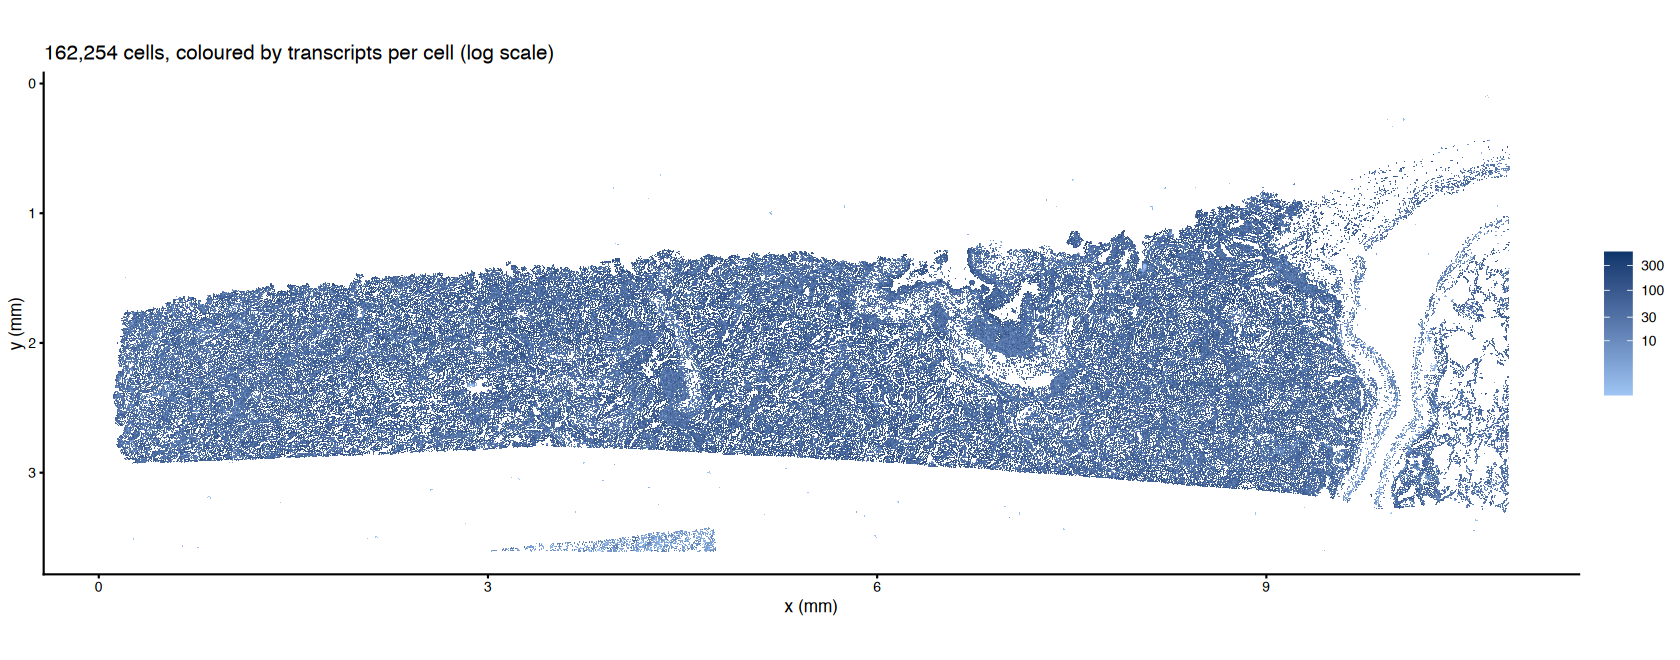

In [26]:
cells_pq <- as.data.frame(read_parquet(file.path(OUTS_DIR, "cells.parquet")))
checks <- c(
  "cells == cells.parquet rows" = ncol(xen) == nrow(cells_pq),
  "gene counts == Python-verified total (9,182,510)" = sum(xen$nCount_Xenium) == 9182510,
  "per-cell counts == cells.parquet transcript_counts" =
    all(xen$nCount_Xenium == cells_pq$transcript_counts[match(colnames(xen), cells_pq$cell_id)]))
data.frame(passed = checks)

# Whole-slide overview: every cell at its centroid, coloured by transcripts per cell
options(repr.plot.width = 14, repr.plot.height = 5.5)
xen$log_counts <- log1p(xen$nCount_Xenium)
tissue_plot(xen, "log_counts", sprintf("%s cells, coloured by transcripts per cell (log scale)", format(ncol(xen), big.mark = ","))) +
  scale_colour_gradient(low = "#9ec5f4", high = "#0d366b", breaks = log1p(c(10, 30, 100, 300)), labels = c(10, 30, 100, 300))

### 3c. Explore the raw transcripts with arrow

The same analysis as Python Step 3c, written with `arrow` + `dplyr`: which transcripts are genes vs. controls, how many pass `qv >= 20`, how many fall inside cells, and an exact reconstruction of the count-matrix total.

**Cross-check:** identical numbers to Python (12,140,711 gene transcripts; 87.4% pass Q20; 9,182,510 assigned to cells).

In [27]:
# Raw transcripts with arrow: read only the needed columns
tx <- read_parquet(file.path(OUTS_DIR, "transcripts.parquet"),
                   col_select = c("feature_name", "qv", "cell_id", "overlaps_nucleus"))
tx <- tx |> mutate(category = case_when(
  startsWith(feature_name, "NegControlProbe") ~ "Negative control probe",
  startsWith(feature_name, "NegControlCodeword") ~ "Negative control codeword",
  startsWith(feature_name, "UnassignedCodeword") ~ "Unassigned codeword",
  startsWith(feature_name, "DeprecatedCodeword") ~ "Deprecated codeword",
  TRUE ~ "Gene"))

tx |> group_by(category) |>
  summarise(transcripts = n(), frac_q20 = mean(qv >= 20), frac_in_cells = mean(cell_id != "UNASSIGNED")) |>
  arrange(desc(transcripts))

usable <- tx$category == "Gene" & tx$qv >= 20
in_cell <- tx$cell_id != "UNASSIGNED"
cat(sprintf("Gene transcripts with qv >= 20: %s; assigned to a cell: %s (%.1f%%); equals the matrix total: %s\n",
            format(sum(usable), big.mark = ","), format(sum(usable & in_cell), big.mark = ","),
            100 * mean(in_cell[usable]), sum(usable & in_cell) == sum(xen$nCount_Xenium)))
rm(tx); invisible(gc())

category,transcripts,frac_q20,frac_in_cells
<chr>,<int>,<dbl>,<dbl>
Gene,12140711,0.87354711,0.8659708
Unassigned codeword,14878,0.09087243,0.7084958
Negative control codeword,5877,0.03709376,0.7415348
Negative control probe,3555,0.14599156,0.7234880


Gene transcripts with qv >= 20: 10,605,483; assigned to a cell: 9,182,510 (86.6%); equals the matrix total: TRUE


## Step 4: Quality control

The same rules and thresholds as the Python workflow (Step 4b), so the two filtered datasets can be compared cell for cell:

| Rule | Type | Rationale |
|---|---|---|
| `nCount_Xenium >= 10` | fixed | Below ~10 transcripts a cell cannot be typed reliably on a 377-gene panel |
| `nFeature_Xenium >= 5` | fixed | At least a handful of distinct genes |
| cell area within 3 MADs (log scale) | data-driven | Removes fragments and merged cells |
| control fraction <= 5% | background | Drops cells dominated by negative-control signal |

### 4a. Per-cell QC metrics

Seurat provides counts and genes per cell; cell and nucleus area come from `cells.parquet`.

In [28]:
# Per-cell QC metrics: Seurat counts + cell / nucleus area from cells.parquet
meta <- cells_pq[match(colnames(xen), cells_pq$cell_id), ]
xen$cell_area <- meta$cell_area
xen$nucleus_area <- meta$nucleus_area
xen$nucleus_count <- if ("nucleus_count" %in% names(meta)) meta$nucleus_count else NA
xen$control_counts <- xen$nCount_ControlProbe + xen$nCount_ControlCodeword
# Control fraction = control counts / gene counts. This matches the Python workflow exactly
# (scanpy's calculate_qc_metrics sets total_counts to gene counts). Dividing by genes + controls
# instead is equally defensible but flags 6 fewer cells: small definitions change cell numbers.
xen$control_frac <- ifelse(xen$nCount_Xenium > 0, xen$control_counts / xen$nCount_Xenium, 0)

qc <- xen@meta.data[, c("nCount_Xenium", "nFeature_Xenium", "cell_area", "nucleus_area", "control_counts")]
t(sapply(qc, function(v) round(quantile(v, c(.01, .05, .25, .5, .75, .95, .99), na.rm = TRUE), 2)))

,1%,5%,25%,50%,75%,95%,99%
nCount_Xenium,3.00,10.00,27.00,46.00,75.00,140.00,202.47
nFeature_Xenium,3.00,8.00,19.00,29.00,40.00,57.00,71.00
cell_area,11.83,20.23,38.74,60.51,94.87,163.33,229.62
nucleus_area,5.69,8.35,17.39,27.77,46.51,76.95,101.65
control_counts,0.00,0.00,0.00,0.00,0.00,0.00,0.00


### 4b. Thresholds and distributions

**A cross-check that caught a definition difference.** The first R version divided control counts by *all* counts (genes + controls) and kept 154,400 cells, 6 more than Python. The Python control fraction uses gene counts as the denominator (scanpy's `calculate_qc_metrics` sets `total_counts` to gene counts). Both are defensible; matching the Python definition makes the two pipelines agree exactly. Small definitional choices change cell numbers, which is why independent re-implementation is valuable.

Cell area bounds (3 MADs, log scale): 7.7 - 435.4 um^2


,cells_flagged,pct
,<dbl>,<dbl>
low_counts,7782,4.80
low_genes,3210,1.98
small_area,316,0.19
large_area,10,0.01
high_control,42,0.03


Pass: 154,394 cells (95.2%). Python workflow kept 154,394: TRUE


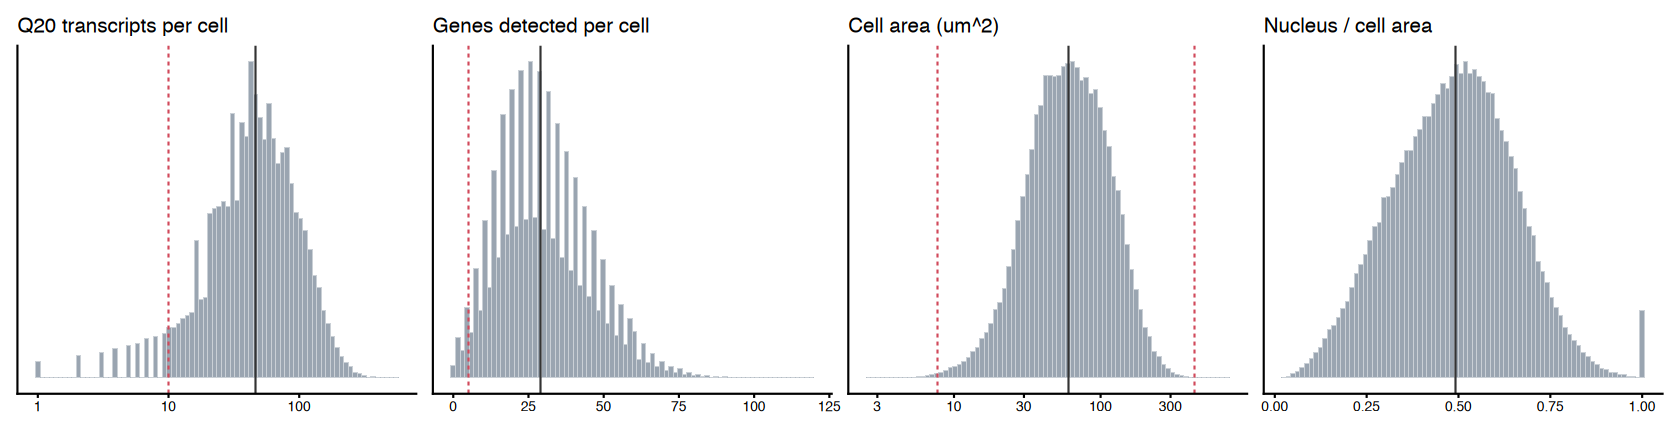

In [29]:
# Same thresholds as the Python workflow (Step 4b), so results are directly comparable
MIN_COUNTS <- 10
MIN_GENES <- 5
AREA_NMADS <- 3
MAX_CONTROL_FRAC <- 0.05

log_area <- log1p(xen$cell_area)
area_bounds <- expm1(median(log_area) + c(-1, 1) * AREA_NMADS * mad(log_area))   # mad() includes the 1.4826 factor

flags <- data.frame(
  low_counts = xen$nCount_Xenium < MIN_COUNTS,
  low_genes = xen$nFeature_Xenium < MIN_GENES,
  small_area = xen$cell_area < area_bounds[1],
  large_area = xen$cell_area > area_bounds[2],
  high_control = xen$control_frac > MAX_CONTROL_FRAC)
xen$qc_pass <- !apply(flags, 1, any)
cat(sprintf("Cell area bounds (3 MADs, log scale): %.1f - %.1f um^2\n", area_bounds[1], area_bounds[2]))
data.frame(cells_flagged = colSums(flags), pct = round(100 * colMeans(flags), 2))
cat(sprintf("Pass: %s cells (%.1f%%). Python workflow kept 154,394: %s\n",
            format(sum(xen$qc_pass), big.mark = ","), 100 * mean(xen$qc_pass), sum(xen$qc_pass) == 154394))

options(repr.plot.width = 14, repr.plot.height = 3.6)
hist_panel <- function(v, title, cuts = NULL, log_x = FALSE) {
  d <- data.frame(v = v[is.finite(v) & (!log_x | v > 0)])
  p <- ggplot(d, aes(v)) + geom_histogram(bins = 80, fill = "#9aa5b1", colour = "white", linewidth = 0.1) +
    geom_vline(xintercept = median(d$v), colour = "#333333") + labs(title = title, x = NULL, y = NULL) +
    theme_classic(base_size = 10) + theme(axis.text.y = element_blank(), axis.ticks.y = element_blank())
  if (!is.null(cuts)) p <- p + geom_vline(xintercept = cuts, colour = "#d1495b", linetype = "dashed")
  if (log_x) p <- p + scale_x_log10()
  p
}
hist_panel(xen$nCount_Xenium, "Q20 transcripts per cell", MIN_COUNTS, TRUE) +
  hist_panel(xen$nFeature_Xenium, "Genes detected per cell", MIN_GENES) +
  hist_panel(xen$cell_area, "Cell area (um^2)", area_bounds, TRUE) +
  hist_panel(xen$nucleus_area / xen$cell_area, "Nucleus / cell area") + plot_layout(nrow = 1)

### 4c. Filter and save

The filtered Seurat object is saved as `.rds` in `~/data/xenium_lung/processed/R/`, outside OneDrive.

In [30]:
xen_qc <- suppressWarnings(subset(xen, subset = qc_pass))   # "Not validating ..." notices are harmless
saveRDS(xen_qc, file.path(R_DIR, paste0(SAMPLE, "_qc_seurat.rds")))
cat(sprintf("Saved %s cells x %s genes to %s\n", format(ncol(xen_qc), big.mark = ","), nrow(xen_qc),
            show_path(file.path(R_DIR, paste0(SAMPLE, "_qc_seurat.rds")))))
rm(xen); invisible(gc())

Saved 154,394 cells x 377 genes to ~/data/xenium_lung/processed/R/Xenium_V1_humanLung_Cancer_FFPE_qc_seurat.rds


## Step 5: Normalisation and clustering

The Python recipe, step for step in Seurat:

| Stage | Python (scanpy) | R (Seurat) |
|---|---|---|
| Normalise | `normalize_total` to the median library size + `log1p` | `NormalizeData(LogNormalize, scale.factor = median counts)` |
| Gene selection | none (all 377 panel genes) | none (`features = rownames`) |
| Scale + PCA | `scale` + 50 PCs, 30 used | `ScaleData` + `RunPCA`, 30 used |
| Neighbour graph | 15 neighbours | `FindNeighbors(k.param = 15)` |
| Clustering | Leiden 0.3 / 0.5 / 1.0 | `FindClusters(algorithm = 4)` = Leiden, same resolutions |
| UMAP | umap-learn | `RunUMAP` (R-native uwot) |
| Markers | Wilcoxon | `FindAllMarkers`, Wilcoxon accelerated by **presto** |

### 5a. Normalise, scale, PCA

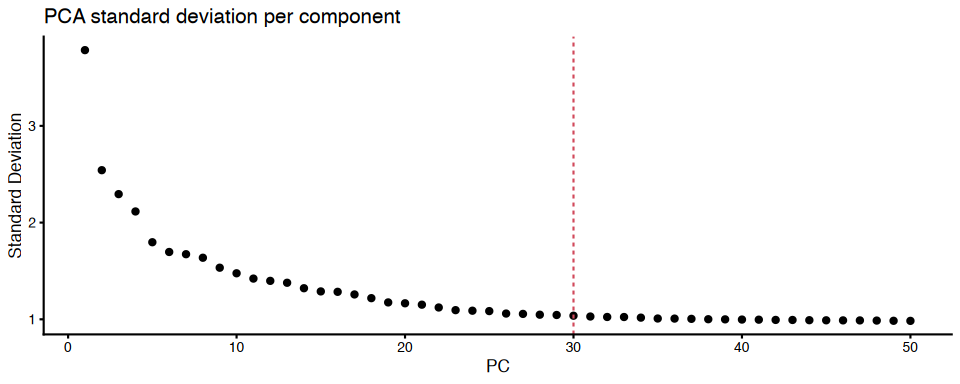

In [31]:
# Same recipe as Python Step 5: normalise to the median library size, log, scale, PCA
N_PCS <- 30
xen_qc <- NormalizeData(xen_qc, normalization.method = "LogNormalize",
                        scale.factor = median(xen_qc$nCount_Xenium), verbose = FALSE)
xen_qc <- ScaleData(xen_qc, features = rownames(xen_qc), verbose = FALSE)    # all 377 panel genes, no HVG step
xen_qc <- RunPCA(xen_qc, features = rownames(xen_qc), npcs = 50, verbose = FALSE)

options(repr.plot.width = 8, repr.plot.height = 3.2)
ElbowPlot(xen_qc, ndims = 50) + geom_vline(xintercept = N_PCS, colour = "#d1495b", linetype = "dashed") +
  ggtitle("PCA standard deviation per component") + theme_classic(base_size = 10)

### 5b. Neighbour graph, Leiden clustering at three resolutions, UMAP

Runtime ~3.5 min on ~154,000 cells (mostly UMAP).

In [ ]:
RESOLUTIONS <- c(0.3, 0.5, 1.0)
# Seurat's own verbose output is not used: in Jupyter, UMAP prints ~100 lines and a temporary file path
xen_qc <- timed("Neighbour graph (k = 15)", FindNeighbors(xen_qc, dims = 1:N_PCS, k.param = 15, verbose = FALSE))
xen_qc <- timed("Leiden at 3 resolutions", FindClusters(xen_qc, resolution = RESOLUTIONS, algorithm = 4,
                                                        random.seed = 1, verbose = FALSE))   # 4 = Leiden
xen_qc <- timed("UMAP (R-native uwot)", suppressWarnings(RunUMAP(xen_qc, dims = 1:N_PCS, seed.use = 1, verbose = FALSE)))
data.frame(resolution = RESOLUTIONS,
           clusters = sapply(RESOLUTIONS, function(r) nlevels(xen_qc[[paste0("Xenium_snn_res.", r)]][, 1])))

### 5c. Clusters on the UMAP and in the tissue

One panel per cluster shows where each sits in the tissue. Compare with the Python Step 5c: B-cell aggregates (TLS), smooth muscle tracing vessels and the pleura, ciliated cells lining an airway, and tumour programmes occupying separate regions.

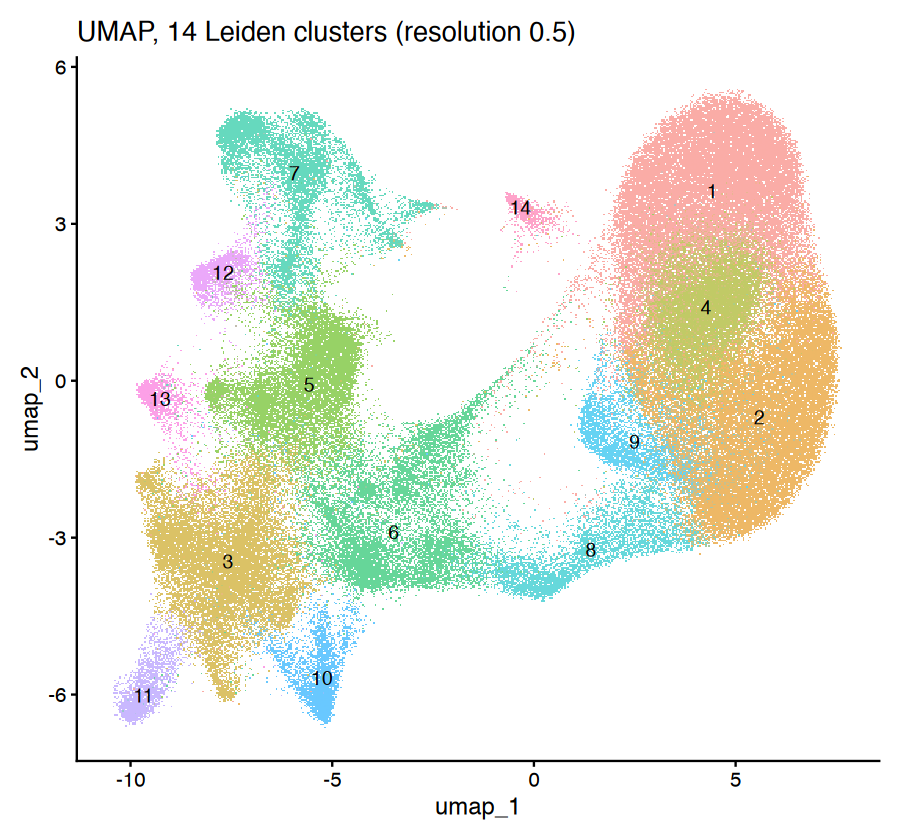

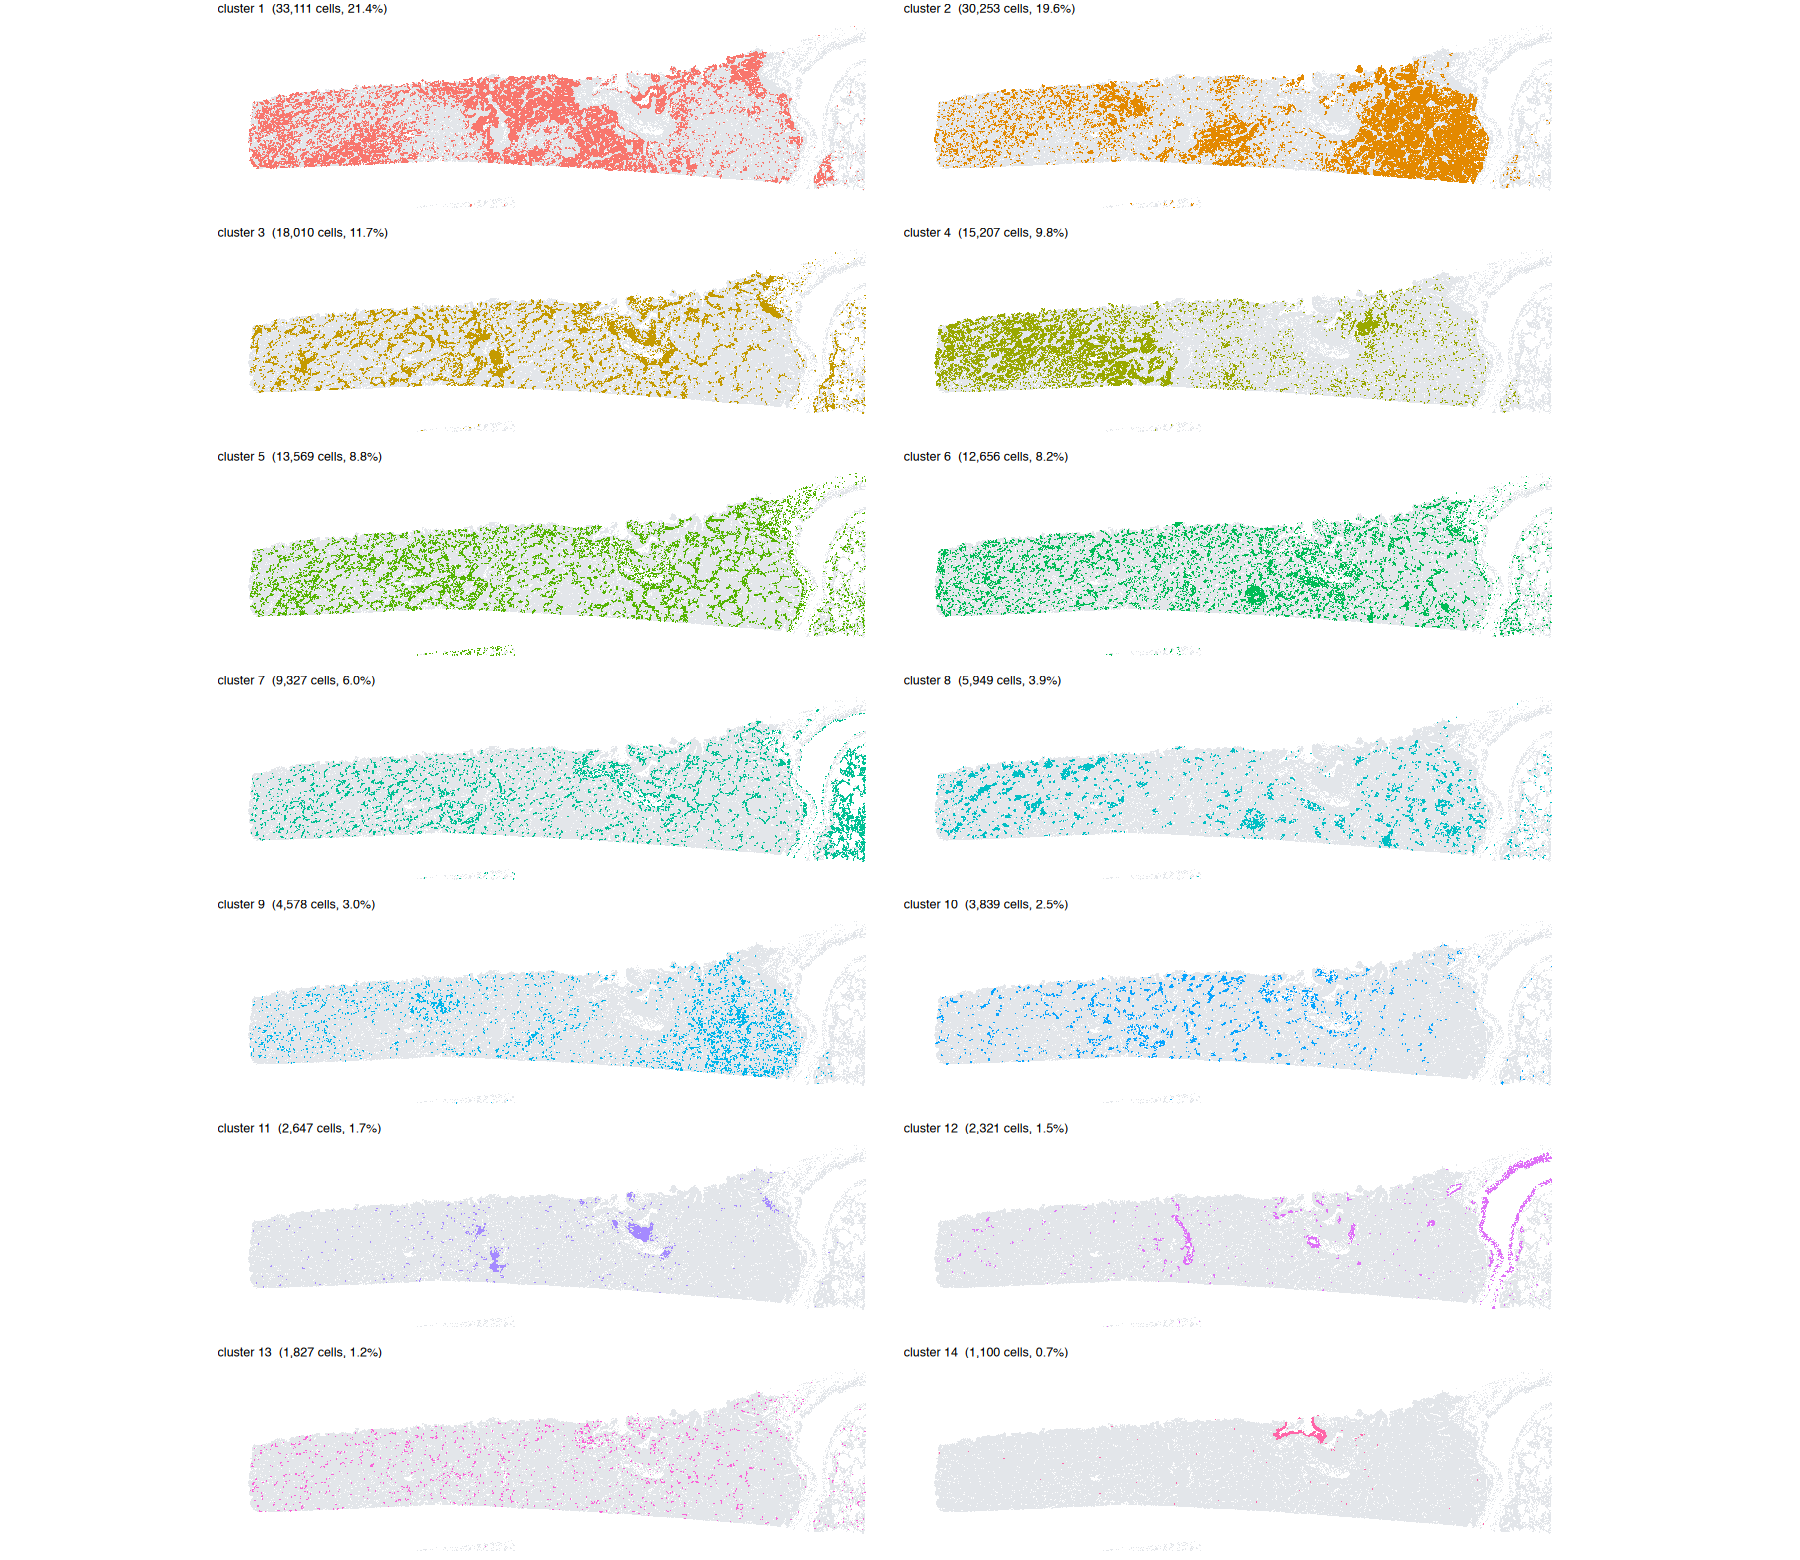

In [18]:
CLUSTER_KEY <- "Xenium_snn_res.0.5"
Idents(xen_qc) <- CLUSTER_KEY
options(repr.plot.width = 7.5, repr.plot.height = 7)
DimPlot(xen_qc, reduction = "umap", label = TRUE, label.size = 4, raster = TRUE, pt.size = 0.6) + NoLegend() +
  ggtitle(sprintf("UMAP, %d Leiden clusters (resolution 0.5)", nlevels(Idents(xen_qc))))

options(repr.plot.width = 15, repr.plot.height = 13)
cluster_panels(xen_qc, CLUSTER_KEY)

### 5d. Marker genes per cluster

With `presto` installed, Seurat's Wilcoxon test on ~154,000 cells takes seconds instead of minutes.

FindAllMarkers: 6 s


cluster,cells,top_markers
<fct>,<int>,<chr>
1,33111,"CYP2A7, CYP2B6, CFTR, TNC, ELF5, ADH1C"
2,30253,"COL17A1, MYC, STC2, KRT7, CCDC78, MET"
3,18010,"CTLA4, CD8A, CD2, GZMA, CD3D, PRF1"
4,15207,"PCSK2, PEBP4, SCGB2A1, PROX1, SFTA2, APCDD1"
5,13569,"PDGFRA, SFRP2, SFRP4, THBS2, COL5A2, LTBP2"
6,12656,"CLEC10A, CD163, CD1C, LILRB2, PLA2G7, MS4A6A"
7,9327,"CLEC14A, VWF, BTNL9, ADGRL4, ACKR1, RAMP2"
8,5949,"MARCO, MCEMP1, AQP9, LPL, ADGRE1, VSIG4"
9,4578,"TOP2A, CENPF, CCNB2, UBE2C, MKI67, CDK1"


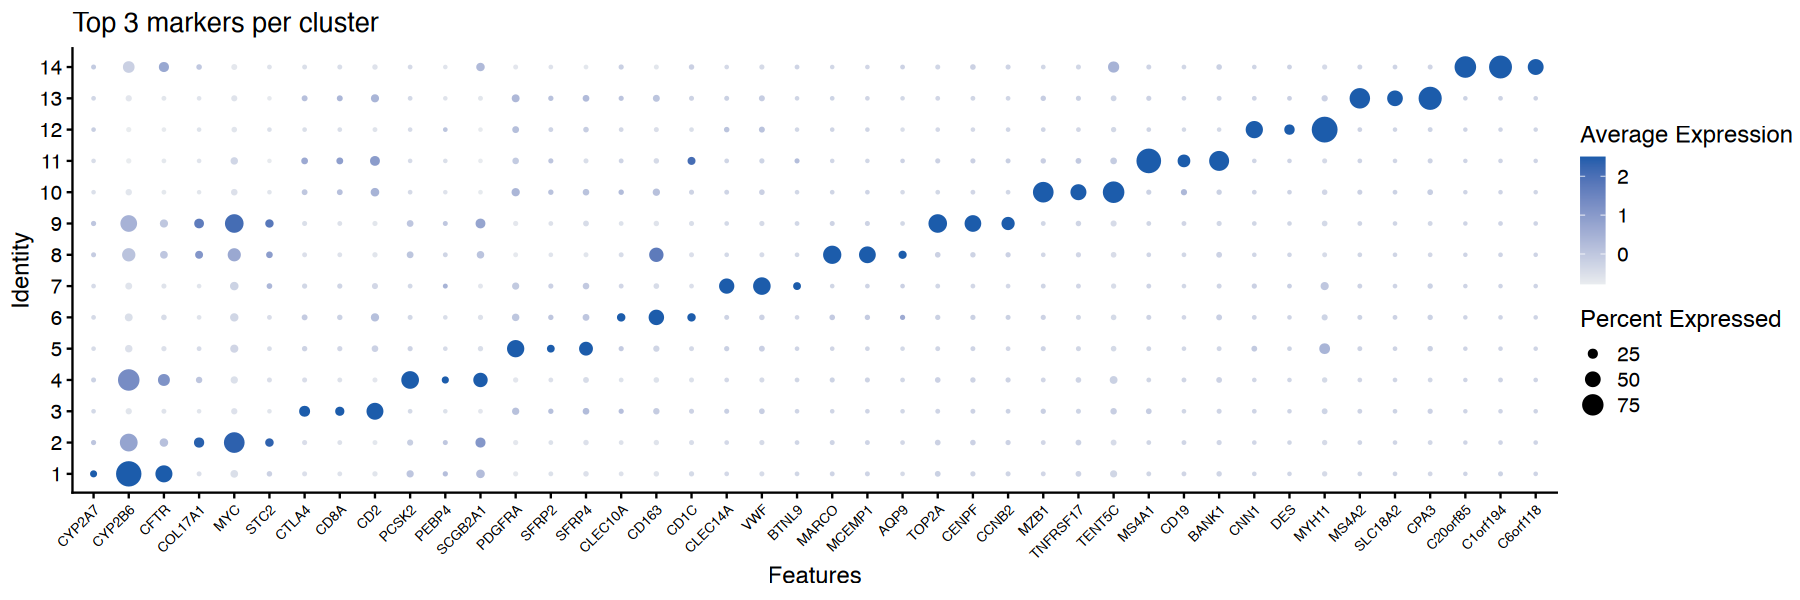

In [34]:
# Marker genes: Wilcoxon test (Seurat uses presto automatically for speed)
t0 <- Sys.time()
markers <- FindAllMarkers(xen_qc, only.pos = TRUE, logfc.threshold = 1, min.pct = 0.1, verbose = FALSE)
cat(sprintf("FindAllMarkers: %.0f s\n", as.numeric(difftime(Sys.time(), t0, units = "secs"))))
# dplyr::first() written explicitly: Bioconductor's S4Vectors (loaded with SingleR in Step 6) masks first()
top <- markers |> filter(p_val_adj < 0.01) |> group_by(cluster) |> slice_max(avg_log2FC, n = 6) |>
  summarise(cells = sum(Idents(xen_qc) == dplyr::first(cluster)), top_markers = paste(gene, collapse = ", "))
top

options(repr.plot.width = 15, repr.plot.height = 5)
top3 <- markers |> filter(p_val_adj < 0.01) |> group_by(cluster) |> slice_max(avg_log2FC, n = 3) |> pull(gene) |> unique()
DotPlot(xen_qc, features = top3, cols = c("#e9ecef", "#1c5cab")) + RotatedAxis() +
  theme(axis.text.x = element_text(size = 8)) + ggtitle("Top 3 markers per cluster")

### 5e. Cross-check against Python and the 10x clustering

The Adjusted Rand Index (ARI) measures agreement between two partitions of the same cells (1 = identical, 0 = random). The Python cluster labels are read straight from its `.h5ad` file with `hdf5r` (anndata >= 0.12 stores strings as a group of `values` + `mask`, handled by the reader).

**Result:** R and Python agree strongly (**ARI ~0.72**), and each agrees equally with the 10x clustering (**~0.51**): two independent toolchains recover the same cell populations.

In [35]:
# Cross-check against the Python (scanpy) clustering and the 10x clustering
py <- read_h5ad_obs(file.path(DATA_ROOT, "processed", paste0(SAMPLE, "_clustered.h5ad")), "leiden_0.5")
tmp <- tempfile(); untar(file.path(OUTS_DIR, "analysis.tar.gz"),
                         files = "analysis/clustering/gene_expression_graphclust/clusters.csv", exdir = tmp)
tenx <- read.csv(file.path(tmp, "analysis/clustering/gene_expression_graphclust/clusters.csv"))
tenx <- setNames(as.character(tenx$Cluster), tenx$Barcode)

shared <- intersect(colnames(xen_qc), names(py))
r_cl <- as.character(Idents(xen_qc)[shared])
data.frame(
  comparison = c("R (Seurat) vs Python (scanpy) Leiden 0.5", "R (Seurat) vs 10x graph clustering", "Python vs 10x (reference)"),
  ARI = round(c(mclust::adjustedRandIndex(r_cl, py[shared]), mclust::adjustedRandIndex(r_cl, tenx[shared]),
                mclust::adjustedRandIndex(py[shared], tenx[shared])), 3))
cat(sprintf("Same cells in both pipelines: %s\n", format(length(shared), big.mark = ",")))

saveRDS(xen_qc, file.path(R_DIR, paste0(SAMPLE, "_clustered_seurat.rds")))
cat("Saved:", show_path(file.path(R_DIR, paste0(SAMPLE, "_clustered_seurat.rds"))), "\n")

comparison,ARI
<chr>,<dbl>
R (Seurat) vs Python (scanpy) Leiden 0.5,0.716
R (Seurat) vs 10x graph clustering,0.513
Python vs 10x (reference),0.506


Same cells in both pipelines: 154,394
Saved: ~/data/xenium_lung/processed/R/Xenium_V1_humanLung_Cancer_FFPE_clustered_seurat.rds 


## Step 6: Cell-type annotation

The Python Step 6 workflow, in R, plus reference-based annotation, which the Python notebook does not have:

1. **Check marker coverage on the panel**, then score canonical marker sets per cell (6a).
2. **Coarse labels per cluster**, decided from markers + scores and guarded against cluster renumbering (6b).
3. **Subcluster the lineages that matter** for a TIME analysis, T/NK (6c) and myeloid (6d), with an explicit table of **spillover evidence** for every subcluster.
4. **SingleR** against two reference atlases as an independent check (6e).
5. **Final labels and a cell-by-cell comparison with the Python annotation** (6f).

Step 6 starts from the Step 5 object (reloaded automatically in a fresh session) and runs in ~3 min.

### 6a. Panel coverage and marker-set scores

`AddModuleScore` = mean expression of a gene set minus matched random control genes (Seurat's equivalent of scanpy's `score_genes`). **Panel-specific setting:** Seurat's default draws 100 control genes from each of 24 expression bins, but 377 genes give only ~15 genes per bin and the call fails; 12 bins with 10 control genes each fit a targeted panel.

,on_panel,missing
,<chr>,<chr>
T cell,"CD3D, CD3E, CD2, TRAC, CD247, IL7R","CD5, CD6"
CD8 T,"CD8A, GZMK, GZMA, CCL5, NKG7",CD8B
Treg,"FOXP3, IL2RA, CTLA4","TNFRSF18, IKZF2"
NK,"KLRD1, KLRC1, GNLY, PRF1",NCAM1
B cell,"MS4A1, CD19, CD79A, BANK1",PAX5
Plasma cell,"MZB1, TNFRSF17, DERL3, PRDM1","JCHAIN, XBP1"
Macrophage,"CD68, CD163, MRC1, MS4A4A","C1QA, APOE"
Alveolar mac,"MARCO, MCEMP1, PPARG",FABP4
Monocyte,"CD14, FCN1, S100A12, VCAN",S100A8


As in Python: the Multi-Tissue panel lacks SFTPC, NAPSA, KRT5, TP63 and SCGB1A1, so alveolar type 2,
 basal and club cells cannot be resolved. Sets with < 2 panel genes are not scored.


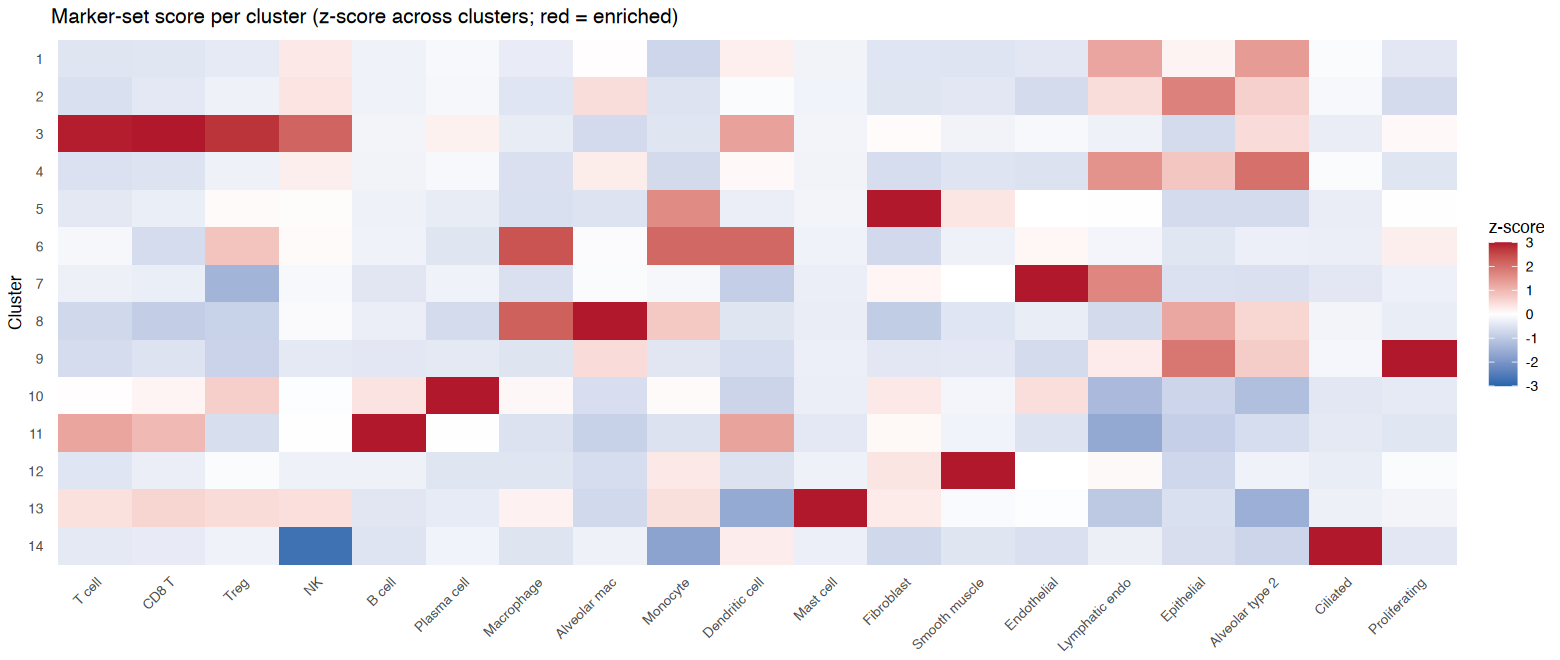

In [36]:
# Step 6 starts from the Step 5 object; reload it if this is a fresh session
if (!exists("xen_qc")) xen_qc <- readRDS(file.path(R_DIR, paste0(SAMPLE, "_clustered_seurat.rds")))
CLUSTER_KEY <- "Xenium_snn_res.0.5"
Idents(xen_qc) <- CLUSTER_KEY
if (!exists("markers"))   # Step 5d marker table, recomputed in a fresh session (~5 s)
  markers <- FindAllMarkers(xen_qc, only.pos = TRUE, logfc.threshold = 1, min.pct = 0.1, verbose = FALSE)

# Canonical marker sets (same as the Python Step 6a), restricted to genes on the panel
MARKER_SETS <- list(
  "T cell" = c("CD3D", "CD3E", "CD2", "TRAC", "CD247", "IL7R", "CD5", "CD6"),
  "CD8 T" = c("CD8A", "CD8B", "GZMK", "GZMA", "CCL5", "NKG7"),
  "Treg" = c("FOXP3", "IL2RA", "CTLA4", "TNFRSF18", "IKZF2"),
  "NK" = c("KLRD1", "KLRC1", "GNLY", "PRF1", "NCAM1"),
  "B cell" = c("MS4A1", "CD19", "CD79A", "BANK1", "PAX5"),
  "Plasma cell" = c("MZB1", "TNFRSF17", "DERL3", "PRDM1", "JCHAIN", "XBP1"),
  "Macrophage" = c("CD68", "CD163", "MRC1", "MS4A4A", "C1QA", "APOE"),
  "Alveolar mac" = c("MARCO", "MCEMP1", "PPARG", "FABP4"),
  "Monocyte" = c("CD14", "FCN1", "S100A12", "VCAN", "S100A8"),
  "Dendritic cell" = c("CD1C", "FCER1A", "CLEC10A", "LAMP3", "CCR7", "CLEC9A"),
  "Mast cell" = c("CPA3", "KIT", "MS4A2", "TPSAB1"),
  "Fibroblast" = c("PDGFRA", "FBN1", "SFRP2", "MFAP5", "DCN", "LUM", "COL1A1"),
  "Smooth muscle" = c("MYH11", "ACTA2", "CNN1", "DES", "MYLK"),
  "Endothelial" = c("PECAM1", "VWF", "CD34", "CD93", "CLEC14A", "CLDN5"),
  "Lymphatic endo" = c("PROX1", "LYVE1", "MMRN1", "CCL21"),
  "Epithelial" = c("EPCAM", "KRT7", "KRT8", "KRT18", "CEACAM6"),
  "Alveolar type 2" = c("SFTPC", "SFTPB", "NAPSA", "LAMP3", "SFTA2"),
  "Basal / club" = c("KRT5", "TP63", "SCGB1A1", "SCGB3A1"),
  "Ciliated" = c("FOXJ1", "SNTN", "C20orf85", "CCDC39", "CAPS"),
  "Proliferating" = c("MKI67", "TOP2A", "CENPF", "CDK1", "PCNA"))
panel <- rownames(xen_qc)
coverage <- data.frame(on_panel = sapply(MARKER_SETS, function(g) paste(intersect(g, panel), collapse = ", ")),
                       missing = sapply(MARKER_SETS, function(g) paste(setdiff(g, panel), collapse = ", ")))
coverage
cat("As in Python: the Multi-Tissue panel lacks SFTPC, NAPSA, KRT5, TP63 and SCGB1A1, so alveolar type 2,\n",
    "basal and club cells cannot be resolved. Sets with < 2 panel genes are not scored.\n")

# Seurat's AddModuleScore = mean expression of the set minus matched random control genes
SETS <- lapply(MARKER_SETS, intersect, panel); SETS <- SETS[lengths(SETS) >= 2]
# 377 genes in 12 expression bins ~ 30 genes per bin; Seurat's default (100 control genes from 24 bins) is too
# large for a targeted panel and fails, so draw 10 control genes per set gene
xen_qc <- AddModuleScore(xen_qc, features = SETS, name = "score_", nbin = 12, ctrl = 10, seed = 1)
score_cols <- paste0("score_", seq_along(SETS))
cl_scores <- aggregate(xen_qc@meta.data[, score_cols], by = list(cluster = Idents(xen_qc)), FUN = mean)
z <- scale(as.matrix(cl_scores[, -1])); dimnames(z) <- list(cl_scores$cluster, names(SETS))

options(repr.plot.width = 13, repr.plot.height = 5.5)
zd <- as.data.frame(as.table(pmax(pmin(z, 3), -3)))
ggplot(zd, aes(Var2, factor(Var1, levels = rev(levels(Idents(xen_qc)))), fill = Freq)) + geom_tile() +
  scale_fill_gradient2(low = "#2166ac", mid = "white", high = "#b2182b", limits = c(-3, 3), name = "z-score") +
  labs(x = NULL, y = "Cluster", title = "Marker-set score per cluster (z-score across clusters; red = enriched)") +
  theme_minimal(base_size = 10) + theme(axis.text.x = element_text(angle = 45, hjust = 1), panel.grid = element_blank())

### 6b. Coarse annotation (one label per cluster)

**Cross-check:** every R cluster maps to one Python population: the three tumour programmes (80-95% of cells carry the same Python label), fibroblasts, endothelium, smooth muscle, plasma, B, mast and ciliated cells (87-98%). Two independent toolchains found the same tissue programmes, not just similar numbers.

Each label is guarded by a marker that must appear among the cluster's top markers; if a re-run ever renumbers the clusters, the cell stops instead of mislabelling.

cluster,label,lineage,cells
<chr>,<chr>,<chr>,<int>
1,Tumour epithelial (CYP2B6/CFTR),Epithelial,33111
2,Tumour epithelial (MYC/CAPN8),Epithelial,30253
4,Tumour epithelial (MALL/TCIM),Epithelial,15207
9,Proliferating tumour,Epithelial,4578
14,Ciliated epithelial,Epithelial,1100
5,Fibroblast,Stromal,13569
12,Smooth muscle,Stromal,2321
7,Endothelial,Endothelial,9327
10,Plasma cell,B / plasma,3839


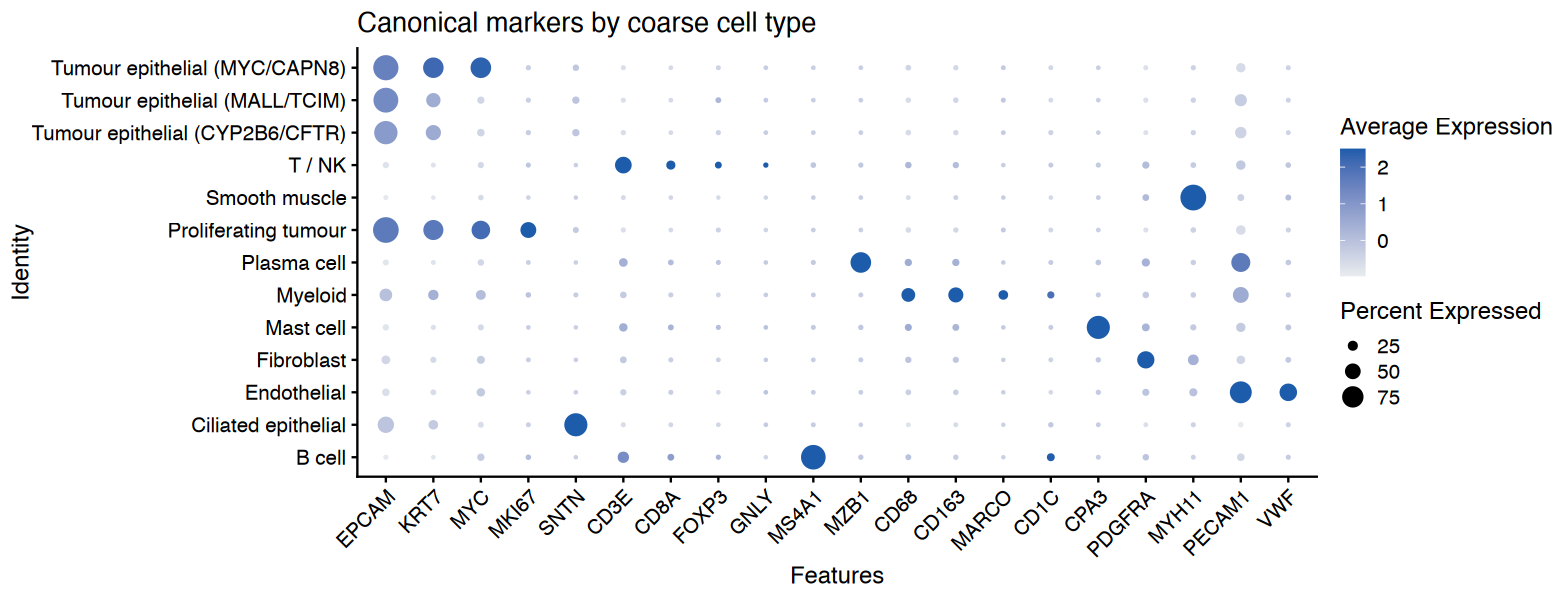

In [37]:
# Coarse labels per cluster, decided from the Step 5d markers and the 6a heatmap.
# expected = a marker that must be among the cluster's top markers (guards against renumbering)
COARSE <- data.frame(
  cluster  = c("1", "2", "4", "9", "14", "5", "12", "7", "10", "11", "13", "3", "6", "8"),
  label    = c("Tumour epithelial (CYP2B6/CFTR)", "Tumour epithelial (MYC/CAPN8)", "Tumour epithelial (MALL/TCIM)",
               "Proliferating tumour", "Ciliated epithelial", "Fibroblast", "Smooth muscle", "Endothelial",
               "Plasma cell", "B cell", "Mast cell", "T / NK", "Myeloid", "Myeloid"),
  lineage  = c(rep("Epithelial", 5), "Stromal", "Stromal", "Endothelial", "B / plasma", "B / plasma", "Mast",
               "T / NK", "Myeloid", "Myeloid"),
  expected = c("CYP2B6", "MYC", "PCSK2", "TOP2A", "C20orf85", "PDGFRA", "MYH11", "VWF", "MZB1", "MS4A1", "CPA3",
               "CD8A", "CD163", "MARCO"))
top_markers <- markers |> filter(p_val_adj < 0.01) |> group_by(cluster) |> slice_max(avg_log2FC, n = 12)
bad <- COARSE |> rowwise() |> filter(!expected %in% top_markers$gene[top_markers$cluster == cluster])
if (nrow(bad) > 0 || !setequal(COARSE$cluster, levels(Idents(xen_qc))))
  stop("Clusters changed; re-check the label table: ", paste(bad$cluster, collapse = ", "))

xen_qc$cell_type_coarse <- COARSE$label[match(Idents(xen_qc), COARSE$cluster)]
xen_qc$lineage <- COARSE$lineage[match(Idents(xen_qc), COARSE$cluster)]
COARSE |> mutate(cells = as.vector(table(Idents(xen_qc))[cluster])) |> select(cluster, label, lineage, cells)

CANONICAL <- c("EPCAM", "KRT7", "MYC", "MKI67", "SNTN", "CD3E", "CD8A", "FOXP3", "GNLY", "MS4A1", "MZB1",
               "CD68", "CD163", "MARCO", "CD1C", "CPA3", "PDGFRA", "MYH11", "PECAM1", "VWF")
options(repr.plot.width = 13, repr.plot.height = 5)
DotPlot(xen_qc, features = CANONICAL, group.by = "cell_type_coarse", cols = c("#e9ecef", "#1c5cab")) + RotatedAxis() +
  ggtitle("Canonical markers by coarse cell type")

### 6c. T / NK subclusters, with spillover evidence

The probe columns give the % of cells in each subcluster with any transcript of another lineage's markers. All T/NK subclusters are 72-92% T-marker positive (dense T-cell zones). A subcluster is **`mixed`** when its defining markers include another lineage's genes or when it holds two cell types.

**What the cross-check with Python (6f) revealed:** R's T/NK subclusters are coarser and each absorbed a neighbouring population, so the labels say so:
- `CD4 T / Treg (FOXP3+)`: Python's Tregs (72% land here) **plus** CD4 T cells. R recovers the CD4 T cells that Python could only label as mixed.
- `CCR7+ T / mregDC (TLS)`: Python's mregDCs (97% land here) plus CCR7+ T cells in the TLS. CCR7 is shared by mature dendritic cells and naive / memory T cells.
- `CD4 T / lymphatic endothelial`: CD4 T cells co-cluster with lymphatic endothelium, the same CD4 T + endothelial pairing Python showed.
- `NK / epithelial`: Python's NK cells (89% land here) plus T/NK cells with tumour spillover (KRT7, GPRC5A among the top markers).

,sub,label,confidence,expected,cells,top_markers,T,Macrophage,Epithelial,Fibroblast,B
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
4,4,CD8 T (GZMK+),high,GZMK,2257,"CD8A, GZMK, NKG7, MS4A1, DUSP2, GZMA",90,11,12,15,19
3,3,CD4 T / Treg (FOXP3+),high,FOXP3,2373,"FOXP3, CTLA4, RTKN2, SLAMF1, SELL, KLRB1",92,8,14,12,10
8,8,Proliferating T,high,MKI67,765,"TOP2A, MKI67, UBE2C, CCNB2, CENPF, CDK1",90,14,18,21,10
6,6,NK / epithelial,mixed,GNLY,1475,"GNLY, KLRC1, KLRD1, GZMB, KRT7, GPRC5A",72,10,53,15,3
5,5,CCR7+ T / mregDC (TLS),mixed,LAMP3,1792,"LAMP3, CCL19, CD83, CCR7, CSF2RA, SPIB",84,12,8,19,14
7,7,CD4 T / lymphatic endothelial,mixed,PROX1,1131,"PROX1, MMRN1, CLEC14A, ADGRL4, VWF, EGFL7",84,13,19,20,5
1,1,T / fibroblast mixed,mixed,PDGFRA,4747,"THBS2, COL5A2, PDGFRA, VCAN, SFRP4, LTBP2",85,13,21,50,7
2,2,T / myeloid mixed,mixed,CD163,3470,"CD163, CD14, MRC1, VSIG4, MS4A4A, PLA2G7",88,37,16,19,6


Probe columns = % of cells with any transcript of that lineage's markers. All subclusters are 72-92%
 T-marker positive (dense T-cell zones). 'mixed' marks subclusters whose defining markers include another
 lineage's genes, or that hold two cell types (see the cross-check in 6f): CCR7 is shared by mregDCs and
 naive / memory T cells, and CD4 T cells co-cluster with lymphatic endothelium.


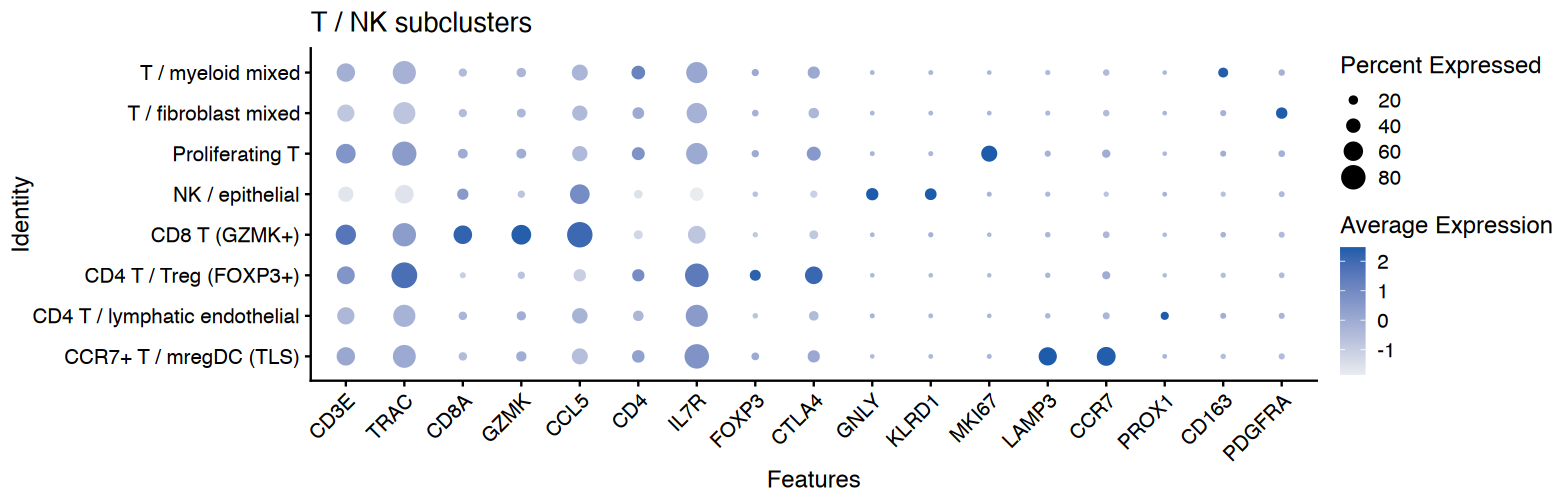

In [38]:
# Re-cluster one lineage with its own PCA, so differences hidden by the epithelial signal surface
subcluster <- function(obj, clusters, res = 0.6) {
  s <- suppressWarnings(subset(obj, idents = clusters))
  s <- ScaleData(s, features = rownames(s), verbose = FALSE)
  s <- suppressWarnings(RunPCA(s, features = rownames(s), npcs = 30, seed.use = 1, verbose = FALSE))
  s <- FindNeighbors(s, dims = 1:20, k.param = 15, verbose = FALSE)
  s <- FindClusters(s, resolution = res, algorithm = 4, random.seed = 1, verbose = FALSE)
  Idents(s) <- "seurat_clusters"
  s
}
# Evidence for spillover: % of cells in each subcluster expressing another lineage's markers
LINEAGE_PROBES <- list(T = c("CD3E", "TRAC"), Macrophage = c("CD68", "CD163"), Epithelial = c("EPCAM", "MALL"),
                       Fibroblast = c("PDGFRA", "FBN1"), B = c("MS4A1", "CD79A"))
probe_rates <- function(s) {
  cnt <- LayerData(s, layer = "counts")
  round(100 * sapply(LINEAGE_PROBES, function(g) tapply(Matrix::colSums(cnt[g, , drop = FALSE] > 0) > 0, Idents(s), mean)))
}
label_subclusters <- function(s, labels) {   # labels: data.frame(sub, label, confidence, expected)
  m <- FindAllMarkers(s, only.pos = TRUE, logfc.threshold = 0.5, min.pct = 0.1, verbose = FALSE)
  top <- m |> filter(p_val_adj < 0.01) |> group_by(cluster) |> slice_max(avg_log2FC, n = 10)
  bad <- labels |> rowwise() |> filter(!expected %in% top$gene[top$cluster == sub])
  if (nrow(bad) > 0 || !setequal(labels$sub, levels(Idents(s))))
    stop("Subclusters changed; re-check the label table: ", paste(bad$sub, collapse = ", "))
  top6 <- top |> slice_max(avg_log2FC, n = 6) |> summarise(top_markers = paste(gene, collapse = ", "))
  s$cell_type_fine <- labels$label[match(Idents(s), labels$sub)]
  s$annotation_confidence <- labels$confidence[match(Idents(s), labels$sub)]
  table_out <- labels |> mutate(cells = as.vector(table(Idents(s))[sub])) |>
    left_join(top6, by = c("sub" = "cluster")) |> cbind(probe_rates(s)[labels$sub, ])
  list(obj = s, table = table_out)
}

# ---- 6c. T / NK (cluster 3) ---------------------------------------------------------
tnk <- subcluster(xen_qc, "3")
TNK_LABELS <- data.frame(
  sub        = c("4", "3", "8", "6", "5", "7", "1", "2"),
  label      = c("CD8 T (GZMK+)", "CD4 T / Treg (FOXP3+)", "Proliferating T", "NK / epithelial", "CCR7+ T / mregDC (TLS)",
                 "CD4 T / lymphatic endothelial", "T / fibroblast mixed", "T / myeloid mixed"),
  confidence = c("high", "high", "high", "mixed", "mixed", "mixed", "mixed", "mixed"),
  expected   = c("GZMK", "FOXP3", "MKI67", "GNLY", "LAMP3", "PROX1", "PDGFRA", "CD163"))
res_tnk <- label_subclusters(tnk, TNK_LABELS); tnk <- res_tnk$obj
res_tnk$table
cat("Probe columns = % of cells with any transcript of that lineage's markers. All subclusters are 72-92%\n",
    "T-marker positive (dense T-cell zones). 'mixed' marks subclusters whose defining markers include another\n",
    "lineage's genes, or that hold two cell types (see the cross-check in 6f): CCR7 is shared by mregDCs and\n",
    "naive / memory T cells, and CD4 T cells co-cluster with lymphatic endothelium.\n")

options(repr.plot.width = 13, repr.plot.height = 4.2)
DotPlot(tnk, features = c("CD3E", "TRAC", "CD8A", "GZMK", "CCL5", "CD4", "IL7R", "FOXP3", "CTLA4", "GNLY", "KLRD1",
                          "MKI67", "LAMP3", "CCR7", "PROX1", "CD163", "PDGFRA"),
        group.by = "cell_type_fine", cols = c("#e9ecef", "#1c5cab")) + RotatedAxis() + ggtitle("T / NK subclusters")

### 6d. Myeloid subclusters

Macrophages in airspaces and tumour (alveolar, TREM2+) carry epithelial transcripts from their neighbours (51-70% of cells), but their defining markers are purely myeloid, so they stay `high`. Three subclusters are defined by another lineage's genes and are `mixed`.

**New relative to Python:** a **TREM2+ macrophage** subcluster (TREM2, LILRB4, PLA2G7), the tumour-associated macrophage state linked to immunosuppression. In 6f it maps to Python's FCGR1A+ macrophages (79%): the same population, named after different top markers.

,sub,label,confidence,expected,cells,top_markers,T,Macrophage,Epithelial,Fibroblast,B
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
5,5,Alveolar macrophage,high,MARCO,1959,"MARCO, MCEMP1, ADGRE1, LPL, PPARG, AQP9",6,92,70,6,2
3,3,TREM2+ macrophage,high,TREM2,2221,"C15orf48, TREM2, LILRB4, PLA2G7, CD83, PDPN",12,86,51,7,3
10,10,LYVE1+ macrophage,high,LYVE1,349,"LYVE1, OGN, SFRP2, C7, MEDAG, SRPX",11,85,9,34,2
12,12,CXCL9+ IFN-activated myeloid,high,CXCL9,175,"CXCL10, CXCL9, LAMP3, CD274, C15orf48, CD83",38,43,42,7,3
11,11,Neutrophil / monocyte (S100A12+),high,S100A12,178,"S100A12, CLEC4E, IL1R2, APOBEC3A, SELL, AQP9",13,15,23,9,3
6,6,Monocyte / cDC2,high,FCN1,1680,"FCN1, CLEC10A, CCR2, FCER1A, CD1C, CD1E",38,49,23,30,6
7,7,cDC2 (CD1A+),high,CD1A,1123,"CD1A, CD1E, CD1C, FCER1A, PLD4, HLA-DQB2",12,31,82,6,2
8,8,cDC1 (IRF8+),high,IRF8,655,"DNASE1L3, IRF8, SLAMF7, FGL2, SH2D3C, SERPINB9",44,22,21,35,8
9,9,Proliferating myeloid,high,MKI67,575,"MKI67, UBE2C, TOP2A, CCNB2, CENPF, CDK1",20,57,56,19,4


Macrophages in airspaces and tumour (alveolar, TREM2+) carry epithelial transcripts from their neighbours
 (51-70%), but their defining markers are purely myeloid, so they stay 'high'. The three 'mixed' groups are
 defined by another lineage's genes. New relative to Python: a TREM2+ macrophage subcluster (TREM2, LILRB4,
 PLA2G7), the tumour-associated macrophage state linked to immunosuppression.


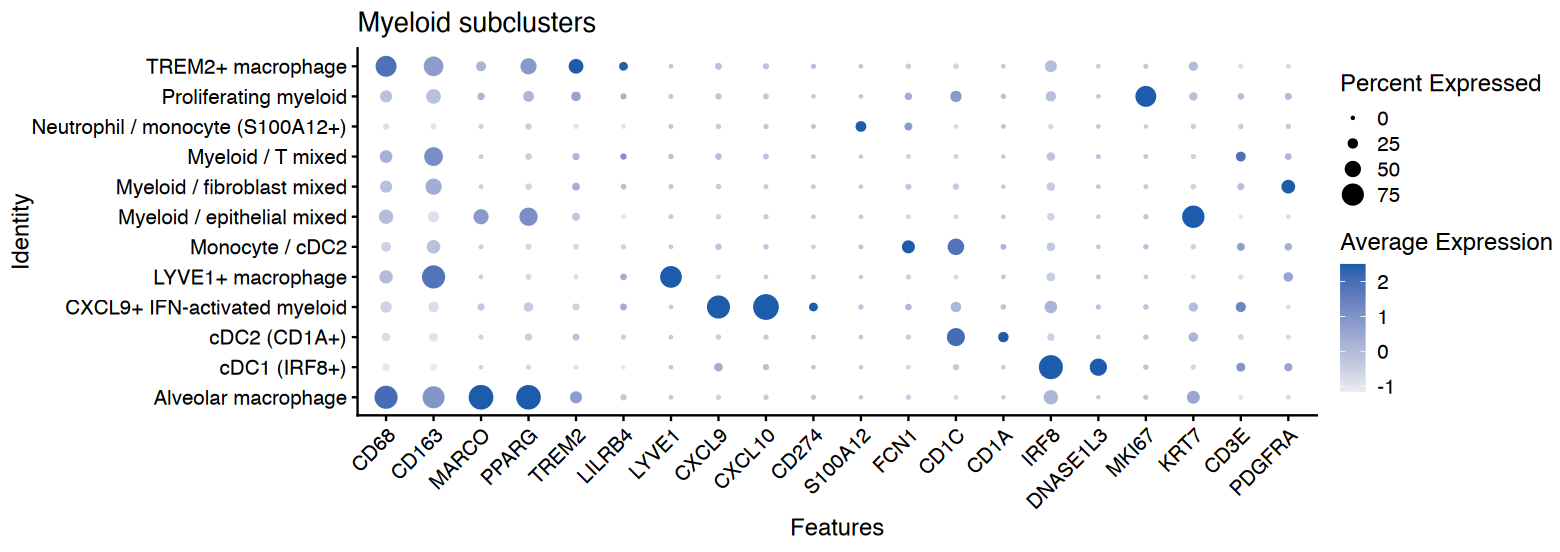

In [39]:
# ---- 6d. Myeloid (clusters 6 + 8) ------------------------------------------------------
mye <- subcluster(xen_qc, c("6", "8"))
MYE_LABELS <- data.frame(
  sub        = c("5", "3", "10", "12", "11", "6", "7", "8", "9", "1", "2", "4"),
  label      = c("Alveolar macrophage", "TREM2+ macrophage", "LYVE1+ macrophage", "CXCL9+ IFN-activated myeloid",
                 "Neutrophil / monocyte (S100A12+)", "Monocyte / cDC2", "cDC2 (CD1A+)", "cDC1 (IRF8+)", "Proliferating myeloid",
                 "Myeloid / epithelial mixed", "Myeloid / T mixed", "Myeloid / fibroblast mixed"),
  confidence = c(rep("high", 9), rep("mixed", 3)),
  expected   = c("MARCO", "TREM2", "LYVE1", "CXCL9", "S100A12", "FCN1", "CD1A", "IRF8", "MKI67",
                 "KRT7", "CD3E", "PDGFRA"))
res_mye <- label_subclusters(mye, MYE_LABELS); mye <- res_mye$obj
res_mye$table
cat("Macrophages in airspaces and tumour (alveolar, TREM2+) carry epithelial transcripts from their neighbours\n",
    "(51-70%), but their defining markers are purely myeloid, so they stay 'high'. The three 'mixed' groups are\n",
    "defined by another lineage's genes. New relative to Python: a TREM2+ macrophage subcluster (TREM2, LILRB4,\n",
    "PLA2G7), the tumour-associated macrophage state linked to immunosuppression.\n")

options(repr.plot.width = 13, repr.plot.height = 4.6)
DotPlot(mye, features = c("CD68", "CD163", "MARCO", "PPARG", "TREM2", "LILRB4", "LYVE1", "CXCL9", "CXCL10", "CD274",
                          "S100A12", "FCN1", "CD1C", "CD1A", "IRF8", "DNASE1L3", "MKI67", "KRT7", "CD3E", "PDGFRA"),
        group.by = "cell_type_fine", cols = c("#e9ecef", "#1c5cab")) + RotatedAxis() + ggtitle("Myeloid subclusters")

### 6e. Reference-based annotation with SingleR

SingleR labels each cell by correlating its expression with annotated reference profiles: an independent check that uses no clustering at all.

1. **Whole tissue vs. the Human Primary Cell Atlas** (bulk profiles of 36 primary cell types; 360 of 377 genes shared). Agreement with the manual lineages is high for epithelium (91%), myeloid (71%) and endothelium (68%), and **fails for cell types the reference lacks or represents oddly**: HPCA has no mast cells (0% agreement), and calls much of the stroma 'osteoblasts' or 'chondrocytes'. *A reference only helps if it contains your cell types.*
2. **Immune cells vs. Monaco**, a reference of sorted immune subsets. CD4 T / Treg -> CD4+ T cells (83%), B -> B cells, both cDC groups -> Dendritic cells (61-78%). **It also flags a likely mislabel in both pipelines:** the S100A12+ group (S100A12, CLEC4E, IL1R2, AQP9) is called **Neutrophils** for 69% of its cells. The classic neutrophil markers (CSF3R, FCGR3B) are not on the panel, so it is now labelled `Neutrophil / monocyte (S100A12+)`.

Runtime: ~75 s for SingleR on all 154,394 cells.

In [44]:
# ---- 6e. Reference-based annotation with SingleR (not in the Python workflow) ------------
suppressPackageStartupMessages({library(SingleR); library(celldex)})
expr <- LayerData(xen_qc, layer = "data")

# (1) Whole tissue vs. the Human Primary Cell Atlas (bulk profiles of 36 primary cell types)
hpca <- suppressMessages(HumanPrimaryCellAtlasData())
genes <- intersect(rownames(expr), rownames(hpca))
pred_hpca <- timed(sprintf("SingleR vs HPCA (%s cells, %d genes)", format(ncol(expr), big.mark = ","), length(genes)),
                   SingleR(test = expr[genes, ], ref = hpca[genes, ], labels = hpca$label.main))
HPCA_TO_LINEAGE <- c(Epithelial_cells = "Epithelial", Keratinocytes = "Epithelial", T_cells = "T / NK", NK_cell = "T / NK",
                     B_cell = "B / plasma", Macrophage = "Myeloid", Monocyte = "Myeloid", DC = "Myeloid",
                     Fibroblasts = "Stromal", Smooth_muscle_cells = "Stromal", Endothelial_cells = "Endothelial")
xen_qc$singler_hpca <- pred_hpca$pruned.labels
hp_lin <- unname(HPCA_TO_LINEAGE[pred_hpca$pruned.labels]); hp_lin[is.na(hp_lin)] <- "other / unmapped"
agree <- as.data.frame.matrix(round(100 * prop.table(table(manual = xen_qc$lineage, SingleR = hp_lin), 1)))
agree$match_pct <- sapply(rownames(agree), function(l) if (l %in% colnames(agree)) agree[l, l] else 0)
agree[order(-agree$match_pct), ]
cat("Lineage-level agreement is high for epithelium, T cells and endothelium, and fails for cell types the\n",
    "reference lacks (no mast cells in HPCA) or represents oddly (stroma as 'osteoblasts' / 'chondrocytes').\n",
    "A reference only helps if it contains your cell types.\n\n")

# (2) Immune cells vs. an immune-specific reference (Monaco: sorted immune subsets, RNA-seq)
monaco <- suppressMessages(MonacoImmuneData())
imm_types <- c("CD8 T (GZMK+)", "CD4 T / Treg (FOXP3+)", "NK / epithelial", "B cell", "Plasma cell",
               "Neutrophil / monocyte (S100A12+)", "cDC1 (IRF8+)", "cDC2 (CD1A+)")
fine <- setNames(as.character(xen_qc$cell_type_coarse), colnames(xen_qc))
fine[colnames(tnk)] <- tnk$cell_type_fine; fine[colnames(mye)] <- mye$cell_type_fine
imm_cells <- names(fine)[fine %in% imm_types]
g2 <- intersect(rownames(expr), rownames(monaco))
pred_mon <- timed(sprintf("SingleR vs Monaco (%s immune cells)", format(length(imm_cells), big.mark = ",")),
                  SingleR(test = expr[g2, imm_cells], ref = monaco[g2, ], labels = monaco$label.main))
mon_tab <- round(100 * prop.table(table(manual = fine[imm_cells], Monaco = pred_mon$pruned.labels), 1))
mon_tab[imm_types[imm_types %in% rownames(mon_tab)], ]
cat("Read across rows: the main Monaco label for each manual type is the independent check. CD4 T / Treg ->\n",
    "CD4+ T cells, B -> B cells and both cDC groups -> Dendritic cells agree. The S100A12+ group (S100A12,\n",
    "CLEC4E, IL1R2, AQP9) is called Neutrophils for most cells: the classic neutrophil markers (CSF3R, FCGR3B)\n",
    "are not on this panel, so it is labelled 'Neutrophil / monocyte'. Monaco has no plasma cells, so they\n",
    "fall back to B cells.\n")

# The references are no longer needed. Unload celldex and its 'alabaster' file readers: alabaster.base defines
# a class "package_version" that clashes with SeuratObject's, and R would otherwise print a "Found more than
# one class" notice in later steps whenever a Seurat object is touched
rm(hpca, monaco)
detach("package:celldex", unload = TRUE)
for (ns in c("alabaster.se", "alabaster.ranges", "alabaster.matrix", "gypsum", "alabaster.base", "alabaster.schemas"))
  if (isNamespaceLoaded(ns)) unloadNamespace(ns)


SingleR (HPCA) on 154,394 cells, 360 shared genes: 78 s


,B / plasma,Endothelial,Epithelial,Myeloid,other / unmapped,Stromal,T / NK,match_pct
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Epithelial,0,1,91,0,7,1,0,91
Myeloid,0,0,13,71,13,1,0,71
Endothelial,0,68,3,2,17,9,1,68
T / NK,1,1,0,11,29,3,55,55
Stromal,0,1,1,2,45,50,0,50
B / plasma,40,1,0,12,31,5,11,40
Mast,0,2,0,7,64,13,14,0


Lineage-level agreement is high for epithelium, T cells and endothelium, and fails for cell types the
 reference lacks (no mast cells in HPCA) or represents oddly (stroma as 'osteoblasts' / 'chondrocytes').
 A reference only helps if it contains your cell types.



                                  Monaco
manual                             B cells Basophils CD4+ T cells CD8+ T cells
  CD8 T (GZMK+)                          0         0           26           32
  CD4 T / Treg (FOXP3+)                  0         0           83            6
  NK / epithelial                        1         1           25           20
  B cell                                60         1            9            6
  Plasma cell                           33         4            9            7
  Neutrophil / monocyte (S100A12+)       1         2            0            0
  cDC1 (IRF8+)                           2         1            1            1
  cDC2 (CD1A+)                           1         3            0            0
                                  Monaco
manual                             Dendritic cells Monocytes Neutrophils
  CD8 T (GZMK+)                                  0         0           0
  CD4 T / Treg (FOXP3+)                          0         0 

Read across rows: the main Monaco label for each manual type is the independent check. CD4 T / Treg ->
 CD4+ T cells, B -> B cells and both cDC groups -> Dendritic cells agree. The S100A12+ group (S100A12,
 CLEC4E, IL1R2, AQP9) is called Neutrophils for most cells: the classic neutrophil markers (CSF3R, FCGR3B)
 are not on this panel, so it is labelled 'Neutrophil / monocyte'. Monaco has no plasma cells, so they
 fall back to B cells.


### 6f. Final labels, comparison with Python, tissue map, save

For each R cell type the table shows the most common Python label of the same cells. **Lineage agreement R vs. Python is ~95% of cells**; most cell types agree at 80-98%. The low-agreement rows are exactly the coarser R subclusters explained in 6c, which is why they carry `mixed` or combined labels. About 14% of cells are `mixed` in R vs. 10% in Python.

The lineage map uses the same colourblind-checked palette as the Python notebook. Labels are saved with the Seurat object and as a CSV (`cell_type_labels_R.csv`) for the next steps.

31 cell types; 14.4% of cells flagged 'mixed' (Python: 9.9%)

Lineage agreement R vs Python: 94.7% of 154,394 cells


,R_cell_type,cells,top_Python_label,pct,second_Python_label,pct2
,<chr>,<int>,<chr>,<dbl>,<chr>,<dbl>
25,Smooth muscle,2321,Smooth muscle,98,Fibroblast,1
11,Endothelial,9327,Endothelial,96,Fibroblast,2
12,Fibroblast,13569,Fibroblast,95,Tumour epithelial (MALL/TCIM),2
30,Tumour epithelial (MALL/TCIM),15207,Tumour epithelial (MALL/TCIM),95,Tumour epithelial (CYP2B6/CFTR),4
1,Alveolar macrophage,1959,Alveolar macrophage,93,Myeloid / epithelial mixed,5
9,Ciliated epithelial,1100,Ciliated epithelial,93,Tumour epithelial (CYP2B6/CFTR),4
13,LYVE1+ macrophage,349,LYVE1+ macrophage,93,Myeloid / fibroblast mixed,3
14,Mast cell,1827,Mast cell,93,Myeloid / T mixed,3
21,Plasma cell,3839,Plasma cell,92,Fibroblast,3


Saved: ~/data/xenium_lung/processed/R/Xenium_V1_humanLung_Cancer_FFPE_annotated_seurat.rds and cell_type_labels_R.csv


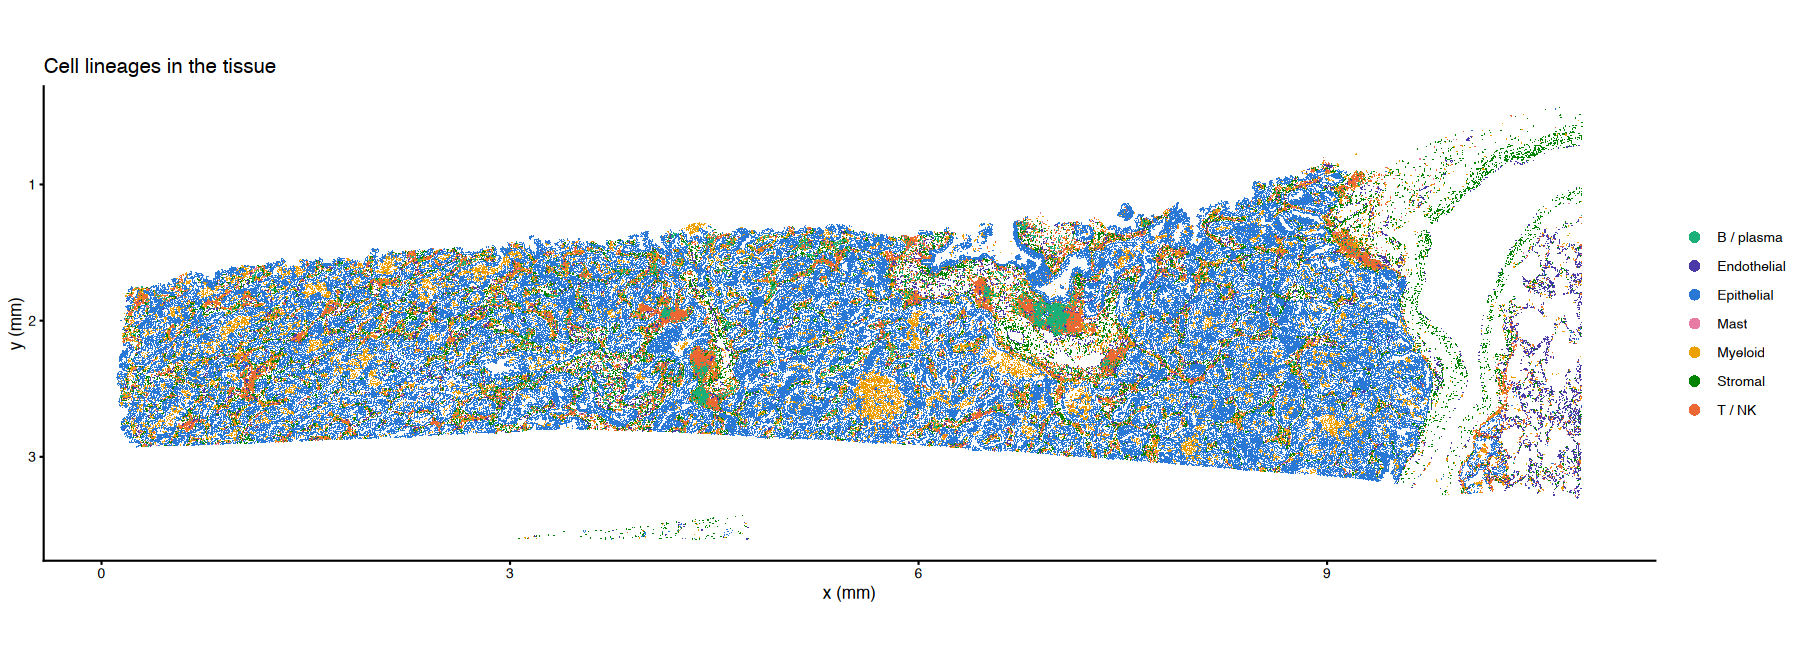

In [45]:
# ---- 6f. Final labels, comparison with the Python annotation, tissue map, save --------------
xen_qc$cell_type <- fine[colnames(xen_qc)]
conf <- setNames(rep("high", ncol(xen_qc)), colnames(xen_qc))
conf[colnames(tnk)] <- tnk$annotation_confidence; conf[colnames(mye)] <- mye$annotation_confidence
xen_qc$annotation_confidence <- conf[colnames(xen_qc)]
LINEAGE_OF <- c("CD8 T (GZMK+)" = "T / NK", "CD4 T / Treg (FOXP3+)" = "T / NK", "NK / epithelial" = "T / NK",
                "Proliferating T" = "T / NK", "T / fibroblast mixed" = "T / NK", "T / myeloid mixed" = "T / NK",
                "CCR7+ T / mregDC (TLS)" = "T / NK", "CD4 T / lymphatic endothelial" = "T / NK")
lin <- xen_qc$lineage; hit <- xen_qc$cell_type %in% names(LINEAGE_OF)
lin[hit] <- LINEAGE_OF[xen_qc$cell_type[hit]]; xen_qc$lineage <- lin
cat(sprintf("%d cell types; %.1f%% of cells flagged 'mixed' (Python: 9.9%%)\n\n",
            length(unique(xen_qc$cell_type)), 100 * mean(xen_qc$annotation_confidence == "mixed")))

# Cross-check against the Python annotation (same cells)
py_type <- read_h5ad_obs(file.path(DATA_ROOT, "processed", paste0(SAMPLE, "_annotated.h5ad")), "cell_type")
py_lin <- read_h5ad_obs(file.path(DATA_ROOT, "processed", paste0(SAMPLE, "_annotated.h5ad")), "lineage")
shared <- intersect(colnames(xen_qc), names(py_type))
cat(sprintf("Lineage agreement R vs Python: %.1f%% of %s cells\n", 100 * mean(xen_qc$lineage[match(shared, colnames(xen_qc))] == py_lin[shared]),
            format(length(shared), big.mark = ",")))
# For each R cell type: the most common Python label of the same cells, and how often they agree
r_type <- xen_qc$cell_type[match(shared, colnames(xen_qc))]
xmap <- do.call(rbind, lapply(sort(unique(r_type)), function(t) {
  p <- sort(table(py_type[shared[r_type == t]]), decreasing = TRUE)
  data.frame(R_cell_type = t, cells = sum(r_type == t), top_Python_label = names(p)[1],
             pct = round(100 * p[[1]] / sum(p)), second_Python_label = if (length(p) > 1) names(p)[2] else "-",
             pct2 = if (length(p) > 1) round(100 * p[[2]] / sum(p)) else 0)
}))
xmap[order(-xmap$pct), ]

LINEAGE_COLORS <- c("Epithelial" = "#2a78d6", "T / NK" = "#eb6834", "B / plasma" = "#1baf7a", "Myeloid" = "#eda100",
                    "Mast" = "#e87ba4", "Stromal" = "#008300", "Endothelial" = "#4a3aa7")   # same palette as Python
options(repr.plot.width = 15, repr.plot.height = 5.5)
tissue_plot(xen_qc, "lineage", "Cell lineages in the tissue") +
  scale_colour_manual(values = LINEAGE_COLORS) + guides(colour = guide_legend(override.aes = list(size = 3)))

suppressMessages(saveRDS(xen_qc, file.path(R_DIR, paste0(SAMPLE, "_annotated_seurat.rds"))))   # hides a harmless class-cache notice
write.csv(data.frame(cell_id = colnames(xen_qc), cell_type = xen_qc$cell_type, lineage = xen_qc$lineage,
                     annotation_confidence = xen_qc$annotation_confidence, singler_hpca = xen_qc$singler_hpca),
          file.path(R_DIR, "cell_type_labels_R.csv"), row.names = FALSE)
cat("Saved:", show_path(file.path(R_DIR, paste0(SAMPLE, "_annotated_seurat.rds"))), "and cell_type_labels_R.csv\n")

## Step 7: Spatial analysis of the tumour immune microenvironment

The four questions of the Python Step 7, answered with R / Bioconductor spatial tools:

| Part | Question | R method |
|---|---|---|
| 7b | Which cell types touch more (or less) than chance? | **imcRtools** `testInteractions` + a vectorised permutation test |
| 7c | What recurring tissue neighbourhoods exist? | k-means niches on the 50 µm lineage mix (as Python) + **Banksy** spatial domains |
| 7d | Do immune cells reach the tumour or are they kept out? | distance to the nearest tumour cell (`RANN`) vs. a baseline |
| 7e | Are there tertiary lymphoid structures? | DBSCAN on B-cell positions (`dbscan`), matched to the Python TLS |

Only `annotation_confidence == "high"` cells are used. R has 132,089 such cells vs. 139,129 in Python, because R's coarser subclusters flag more cells `mixed` (Step 6). The step starts from the Step 6 object and runs in ~7.5 min.

### 7a. Spatial neighbour graph

The data are moved into a Bioconductor `SpatialExperiment`. imcRtools builds a Delaunay graph with edges longer than 30 µm removed, the same rule as Python. The window plot shows the graph at the largest B-cell aggregate.

132,089 high-confidence cells of 154,394 (Python: 139,129 of 154,394; R flags more 'mixed' cells)



Found more than one class "package_version" in cache; using the first, from namespace 'SeuratObject'

Also defined by ‘alabaster.base’



Delaunay graph: 775,580 directed edges; neighbours per cell: median 6, mean 5.9; isolated cells: 94


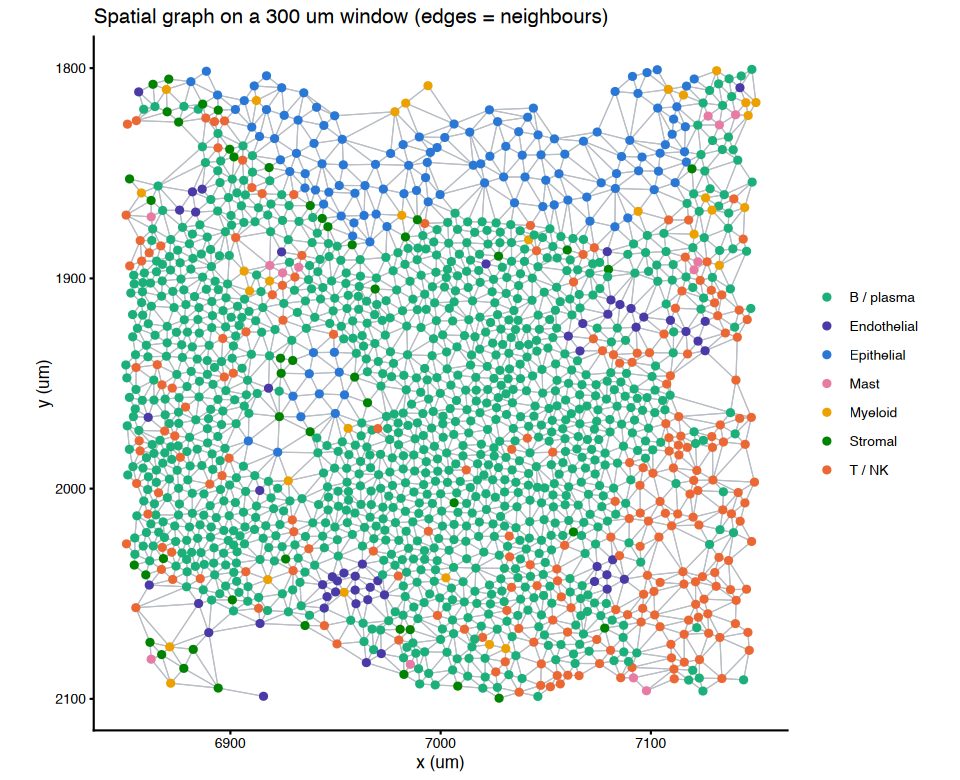

In [46]:
suppressPackageStartupMessages({library(SpatialExperiment); library(imcRtools); library(BiocParallel)})
if (!exists("xen_qc") || !"annotation_confidence" %in% colnames(xen_qc@meta.data))
  xen_qc <- readRDS(file.path(R_DIR, paste0(SAMPLE, "_annotated_seurat.rds")))   # Step 6 output
LINEAGE_COLORS <- c("Epithelial" = "#2a78d6", "T / NK" = "#eb6834", "B / plasma" = "#1baf7a", "Myeloid" = "#eda100",
                    "Mast" = "#e87ba4", "Stromal" = "#008300", "Endothelial" = "#4a3aa7")
TUMOUR_TYPES <- c("Tumour epithelial (MALL/TCIM)", "Tumour epithelial (CYP2B6/CFTR)",
                  "Tumour epithelial (MYC/CAPN8)", "Proliferating tumour")
N_WORKERS <- 8   # permutation tests run in parallel

# Spatial statistics use high-confidence cells only (as in Python); 'mixed' cells would blur contacts
hc <- suppressWarnings(subset(xen_qc, subset = annotation_confidence == "high"))
xy <- GetTissueCoordinates(hc, image = "fov"); xy <- xy[match(colnames(hc), xy$cell), ]
spe <- SpatialExperiment(assays = list(logcounts = LayerData(hc, layer = "data")),
                         colData = hc@meta.data[, c("cell_type", "lineage", "nCount_Xenium")],
                         spatialCoords = as.matrix(xy[, c("x", "y")]))
spe$sample_id <- SAMPLE
cat(sprintf("%s high-confidence cells of %s (Python: 139,129 of 154,394; R flags more 'mixed' cells)\n\n",
            format(ncol(spe), big.mark = ","), format(ncol(xen_qc), big.mark = ",")))

# Delaunay triangulation, edges longer than 30 um removed (same rule as Python Step 7a)
spe <- suppressMessages(buildSpatialGraph(spe, img_id = "sample_id", type = "delaunay", max_dist = 30, coords = c("x", "y")))
g <- colPair(spe, "delaunay_interaction_graph")
deg <- tabulate(from(g), nbins = ncol(spe))
cat(sprintf("Delaunay graph: %s directed edges; neighbours per cell: median %d, mean %.1f; isolated cells: %d\n",
            format(length(g), big.mark = ","), median(deg), mean(deg), sum(deg == 0)))

# The graph around the largest B-cell aggregate (same window as Python)
x0 <- 6850; y0 <- 1800; w <- 300
co <- spatialCoords(spe); inwin <- co[, 1] > x0 & co[, 1] < x0 + w & co[, 2] > y0 & co[, 2] < y0 + w
e <- which(inwin[from(g)] & inwin[to(g)])
seg <- data.frame(x = co[from(g)[e], 1], y = co[from(g)[e], 2], xend = co[to(g)[e], 1], yend = co[to(g)[e], 2])
pts <- data.frame(x = co[inwin, 1], y = co[inwin, 2], lineage = spe$lineage[inwin])
options(repr.plot.width = 8, repr.plot.height = 6.5)
ggplot() + geom_segment(data = seg, aes(x, y, xend = xend, yend = yend), colour = "#b9bec5", linewidth = 0.25) +
  geom_point(data = pts, aes(x, y, colour = lineage), size = 1.6) + scale_colour_manual(values = LINEAGE_COLORS) +
  coord_equal(xlim = c(x0, x0 + w), ylim = c(y0 + w, y0)) + scale_y_reverse() +
  labs(title = "Spatial graph on a 300 um window (edges = neighbours)", x = "x (um)", y = "y (um)", colour = NULL) +
  theme_classic(base_size = 10)

### 7b. Neighbourhood enrichment

**Performance lesson.** imcRtools `testInteractions` re-counts every neighbour pair in R on each shuffle: 1,000 shuffles took ~10 min for 7 lineages and did not finish in 15 min for 17 cell types. It is kept at 200 shuffles for the lineage level (min p = 0.005, enough for p < 0.01). The cell-type level uses a **vectorised permutation test**: each shuffle is one sparse matrix product (`t(onehot) %*% adjacency %*% onehot`), the same computation squidpy uses in Python, so its z-scores are directly comparable. A consistency check confirms that both methods give the same direction for every lineage pair.

**Findings (same as Python):** the three tumour programmes avoid each other most strongly (separate tumour regions); fibroblasts and endothelium avoid tumour cells and sit together; CD8 T cells co-localise with CD4 T / Treg and B cells (immune hubs).

Found more than one class "package_version" in cache; using the first, from namespace 'SeuratObject'

Also defined by ‘alabaster.base’

Found more than one class "package_version" in cache; using the first, from namespace 'SeuratObject'

Also defined by ‘alabaster.base’



  |                                                                      |   0%

R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call


R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call




  |=                                                                     |   1%

R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call




...

  |===================================================================== |  99%

R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call




  |======================================================================| 100%

R_zmq_msg_send errno: 4 strerror: Interrupted system call
R_zmq_msg_send errno: 4 strerror: Interrupted system call






imcRtools, 7 lineages, 200 permutations: 131 s
  |==================================================| 100%

Vectorised test, 7 lineages, 1,000 permutations: 28 s
Same direction (together / apart / n.s.) as imcRtools for 49 of 49 lineage pairs

  |==================================================| 100%

Vectorised test, 17 cell types, 1,000 permutations: 34 s


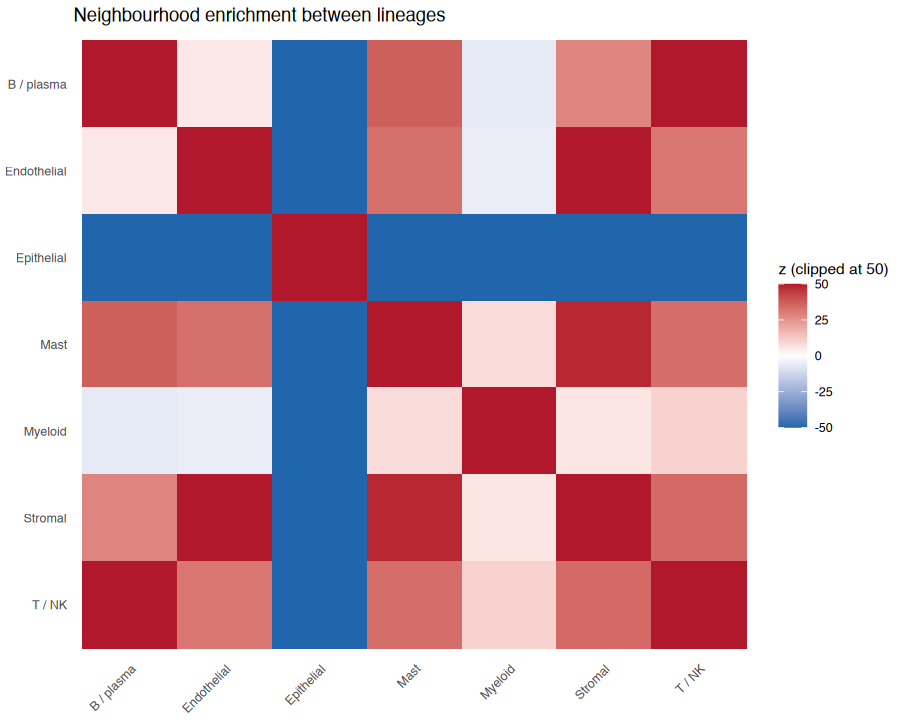

Strongest co-localised pairs:
           cell type A                   cell type B        z
  Proliferating tumour Tumour epithelial (MYC/CAPN8) 86.64823
 CD4 T / Treg (FOXP3+)                 CD8 T (GZMK+) 82.12638
           Endothelial                    Fibroblast 76.42405
                B cell                 CD8 T (GZMK+) 64.13510
   Alveolar macrophage             TREM2+ macrophage 60.76347
            Fibroblast                   Plasma cell 57.27386
 CD4 T / Treg (FOXP3+)               Proliferating T 52.19668
         CD8 T (GZMK+)               Proliferating T 46.21333

Strongest avoiding pairs:
                     cell type A                     cell type B          z
 Tumour epithelial (CYP2B6/CFTR)   Tumour epithelial (MYC/CAPN8) -144.46525
                      Fibroblast Tumour epithelial (CYP2B6/CFTR) -103.73351
                     Endothelial Tumour epithelial (CYP2B6/CFTR) -102.25163
                     Endothelial   Tumour epithelial (MYC/CAPN8)  -98.98254
     

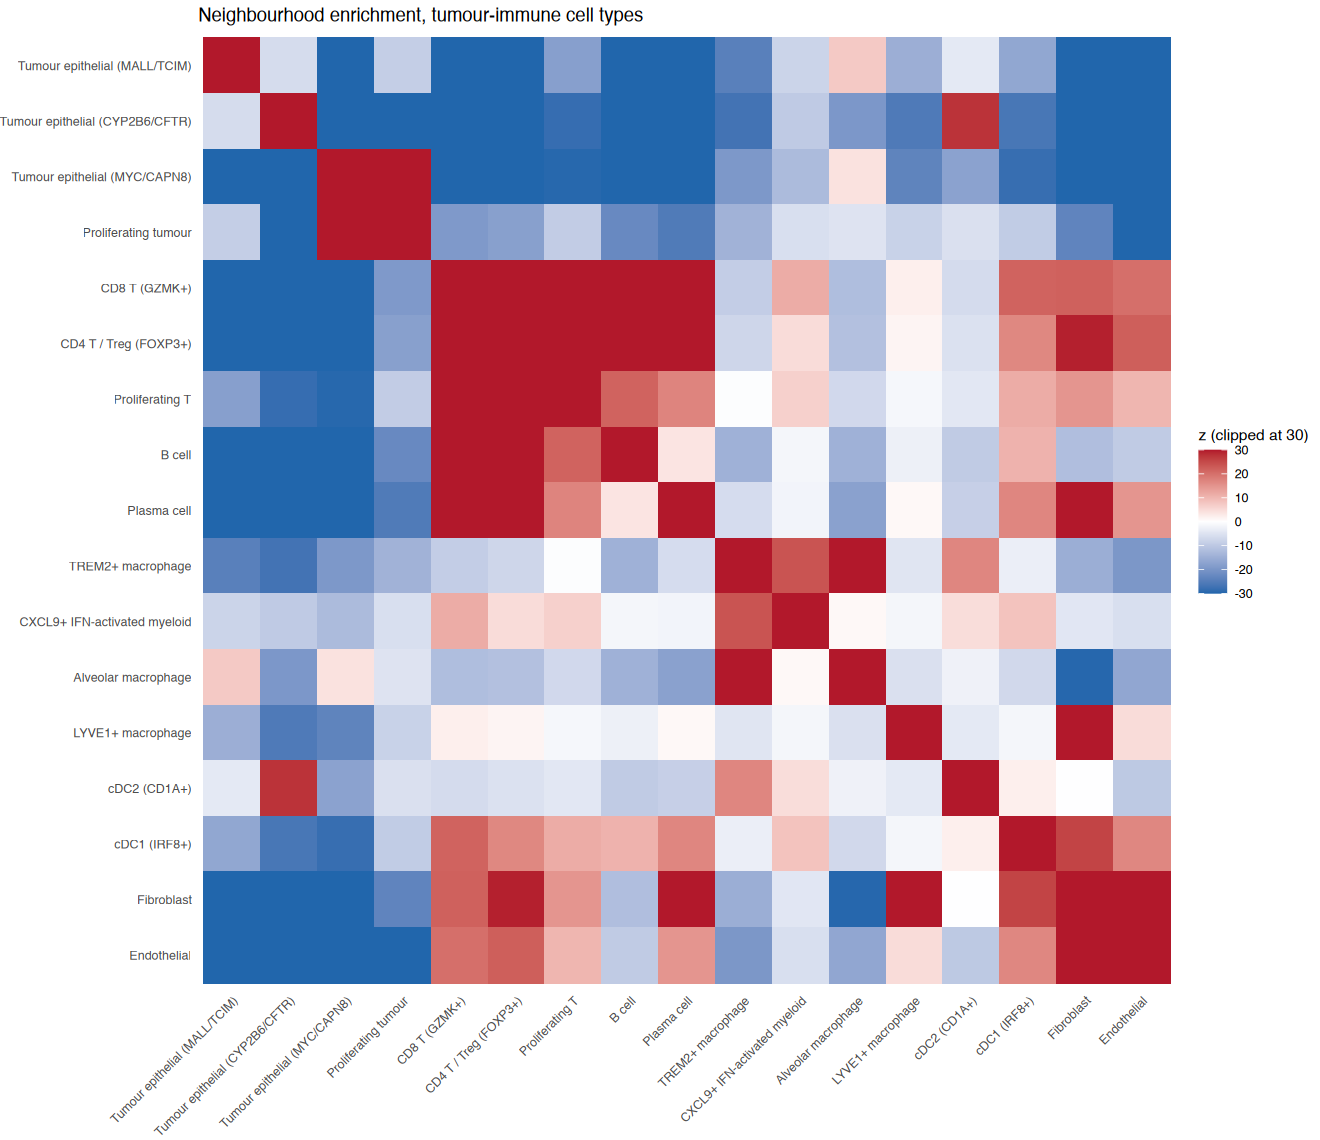

In [63]:
# ---- (i) imcRtools at lineage level ------------------------------------------------------------
# testInteractions ('classic'): mean number of B neighbours per A cell vs. label shuffles.
# sigval: +1 = together more than chance, -1 = apart, 0 = n.s. (p < 0.01).
# 200 permutations (min p = 0.005 < 0.01): 1,000 took ~10 min here because imcRtools re-counts in R each time
t0 <- Sys.time()
int_lin <- as.data.frame(testInteractions(spe, group_by = "sample_id", label = "lineage",
                                          colPairName = "delaunay_interaction_graph", method = "classic", iter = 200,
                                          p_threshold = 0.01, BPPARAM = MulticoreParam(workers = N_WORKERS, RNGseed = 1,
                                                                          progressbar = SHOW_PROGRESS)))
cat(sprintf("imcRtools, 7 lineages, 200 permutations: %.0f s\n", as.numeric(difftime(Sys.time(), t0, units = "secs"))))

# ---- (ii) Fast vectorised permutation test (same null model) -----------------------------------
# imcRtools re-counts every neighbour pair in R on each shuffle, which took > 15 min for 19 cell types.
# Here each shuffle is one sparse matrix product: counts[A, B] = t(onehot) %*% adjacency %*% onehot.
# This is the computation squidpy uses in Python (nhood_enrichment), so z-scores are comparable.
adj <- Matrix::sparseMatrix(i = from(g), j = to(g), x = 1, dims = c(ncol(spe), ncol(spe)))
nhood_enrichment <- function(labels, n_perm = 1000, seed = 1) {
  f <- factor(labels); lev <- levels(f)
  onehot <- function(fac) Matrix::sparseMatrix(i = seq_along(fac), j = as.integer(fac), x = 1, dims = c(length(fac), length(lev)))
  count <- function(fac) { M <- onehot(fac); as.matrix(Matrix::crossprod(M, adj %*% M)) }
  obs <- count(f)
  set.seed(seed)
  perm <- array(0, dim = c(dim(obs), n_perm))
  pb <- progress_bar(n_perm)
  for (k in seq_len(n_perm)) { perm[, , k] <- count(f[sample.int(length(f))]); progress_tick(pb, k) }
  progress_close(pb)
  z <- (obs - apply(perm, 1:2, mean)) / apply(perm, 1:2, sd)
  dimnames(z) <- list(lev, lev)
  z
}
t0 <- Sys.time()
z_lin <- nhood_enrichment(spe$lineage)
cat(sprintf("Vectorised test, 7 lineages, 1,000 permutations: %.0f s\n", as.numeric(difftime(Sys.time(), t0, units = "secs"))))

# Consistency check: do both methods call the same pairs together / apart?
fast_sign <- sign(z_lin[cbind(int_lin$from_label, int_lin$to_label)]) * (abs(z_lin[cbind(int_lin$from_label, int_lin$to_label)]) > 2.58)
cat(sprintf("Same direction (together / apart / n.s.) as imcRtools for %d of %d lineage pairs\n\n",
            sum(fast_sign == int_lin$sigval), nrow(int_lin)))

z_heatmap <- function(z, title, clip = 50, order = rownames(z)) {
  d <- as.data.frame(as.table(pmax(pmin(z[order, order], clip), -clip)))
  d$Var1 <- factor(d$Var1, levels = rev(order)); d$Var2 <- factor(d$Var2, levels = order)
  ggplot(d, aes(Var2, Var1, fill = Freq)) + geom_tile() +
    scale_fill_gradient2(low = "#2166ac", mid = "white", high = "#b2182b", limits = c(-clip, clip),
                         name = sprintf("z (clipped at %d)", clip)) +
    labs(title = title, x = NULL, y = NULL) + theme_minimal(base_size = 9) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1), panel.grid = element_blank())
}
options(repr.plot.width = 7.5, repr.plot.height = 6)
z_heatmap(z_lin, "Neighbourhood enrichment between lineages")

TIME_TYPES <- c(TUMOUR_TYPES, "CD8 T (GZMK+)", "CD4 T / Treg (FOXP3+)", "Proliferating T", "B cell", "Plasma cell",
                "TREM2+ macrophage", "CXCL9+ IFN-activated myeloid", "Alveolar macrophage", "LYVE1+ macrophage",
                "cDC2 (CD1A+)", "cDC1 (IRF8+)", "Fibroblast", "Endothelial")
TIME_TYPES <- TIME_TYPES[TIME_TYPES %in% spe$cell_type]
t0 <- Sys.time()
z_ct <- nhood_enrichment(ifelse(spe$cell_type %in% TIME_TYPES, spe$cell_type, "other"))
cat(sprintf("Vectorised test, %d cell types, 1,000 permutations: %.0f s\n", length(TIME_TYPES),
            as.numeric(difftime(Sys.time(), t0, units = "secs"))))
options(repr.plot.width = 11, repr.plot.height = 9.5)
z_heatmap(z_ct, "Neighbourhood enrichment, tumour-immune cell types", clip = 30, order = TIME_TYPES)

pairs <- as.data.frame(as.table(z_ct[TIME_TYPES, TIME_TYPES]))
pairs <- subset(pairs, as.character(Var1) < as.character(Var2))
names(pairs) <- c("cell type A", "cell type B", "z")
cat("Strongest co-localised pairs:\n"); print(head(pairs[order(-pairs$z), ], 8), row.names = FALSE)
cat("\nStrongest avoiding pairs:\n"); print(head(pairs[order(pairs$z), ], 5), row.names = FALSE)

### 7c. Cellular niches and Banksy spatial domains

1. **Composition niches** replicate the Python method: each cell's lineage mix within 50 µm, grouped by k-means into 10 niches. The niche structure matches Python's: a tumour core (~93% epithelial), tumour-stroma interfaces, a myeloid-rich niche, a T-cell niche and a B-cell niche. k-means uses the MacQueen algorithm; R's default (Hartigan-Wong) stalls on 130,000 cells.
2. **Banksy** (not used in Python) clusters cells on their own expression *plus* their neighbours' expression, so groups are tissue domains rather than cell mixes. Its 9 domains are anatomically meaningful: **three separate tumour regions** (the three tumour programmes), the myeloid patches, the TLS, lung parenchyma at the edge, an airway and the pleura.

The two agree weakly (ARI ~0.16) because they answer different questions: niches group by *which cells are nearby*, Banksy by *what the local tissue expresses*.

In [ ]:
# ---- (i) Cellular niches exactly as in Python: lineage mix within 50 um -> k-means (10 niches) ----
spe <- suppressMessages(buildSpatialGraph(spe, img_id = "sample_id", type = "expansion", threshold = 50, coords = c("x", "y")))
spe <- aggregateNeighbors(spe, colPairName = "expansion_interaction_graph", aggregate_by = "metadata", count_by = "lineage")
comp <- as.matrix(spe$aggregatedNeighbors); comp[is.na(comp)] <- 0
set.seed(1)
km <- kmeans(comp, centers = 10, nstart = 10, iter.max = 100, algorithm = "MacQueen")   # default Hartigan-Wong stalls on 130k cells
centres <- km$centers
niche_name <- function(v) { s <- sort(v, decreasing = TRUE)
  if (s[1] >= 0.85) sprintf("%s %.0f%%", names(s)[1], 100 * s[1])
  else sprintf("%s %.0f%% + %s %.0f%%", names(s)[1], 100 * s[1], names(s)[2], 100 * s[2]) }
ord <- order(-centres[, "Epithelial"])
names_map <- setNames(sprintf("N%d: %s", seq_along(ord), apply(centres[ord, ], 1, niche_name)), ord)
spe$niche <- factor(names_map[as.character(km$cluster)], levels = names_map)
niche_tab <- round(100 * centres[ord, ]); rownames(niche_tab) <- names_map
cbind(niche_tab, cells = as.vector(table(spe$niche)))

# ---- (ii) Banksy: spatial domains from expression + neighbourhood expression -----------------
# Unlike the composition niches, Banksy uses each cell's own expression and the mean expression of
# its 15 nearest neighbours (lambda = 0.8 weights the neighbourhood heavily -> tissue domains).
suppressPackageStartupMessages(library(Banksy))
t0 <- Sys.time()
assay(spe, "normcounts") <- assay(spe, "logcounts")
spe <- timed("Banksy neighbourhood features (k = 15)", computeBanksy(spe, assay_name = "normcounts", compute_agf = FALSE,
                                                                     k_geom = 15, coord_names = c("x", "y"), verbose = FALSE))
spe <- timed("Banksy PCA (lambda = 0.8)", suppressMessages(runBanksyPCA(spe, lambda = 0.8, npcs = 20, seed = 1)))
spe <- timed("Banksy clustering", suppressMessages(clusterBanksy(spe, lambda = 0.8, resolution = 0.3, seed = 1)))
dom_col <- grep("^clust_", colnames(colData(spe)), value = TRUE)[1]
spe$banksy_domain <- factor(spe[[dom_col]])
cat(sprintf("Banksy: %d domains in %.0f s\n", nlevels(spe$banksy_domain), as.numeric(difftime(Sys.time(), t0, units = "secs"))))
cat(sprintf("Agreement Banksy domains vs composition niches (ARI): %.2f\n",
            mclust::adjustedRandIndex(spe$banksy_domain, spe$niche)))
dom_mix <- round(100 * prop.table(table(domain = spe$banksy_domain, lineage = spe$lineage), 1))
dom_mix

panel_map <- function(group, title, ncol = 2) {
  co <- spatialCoords(spe) / 1000
  d <- data.frame(x = co[, 1], y = co[, 2], g = group)
  ggplot(d, aes(x, y)) + geom_point(data = d[, 1:2], colour = "#e3e6ea", size = 0.02, stroke = 0) +
    geom_point(colour = "#2a78d6", size = 0.1, stroke = 0) + facet_wrap(~g, ncol = ncol) +
    coord_equal() + scale_y_reverse() + theme_void(base_size = 9) + ggtitle(title) +
    theme(strip.text = element_text(hjust = 0, margin = margin(2, 0, 2, 0)))
}
options(repr.plot.width = 15, repr.plot.height = 10)
panel_map(spe$niche, "Composition niches (k-means on 50 um lineage mix)")
panel_map(spe$banksy_domain, "Banksy spatial domains (expression + neighbourhood)")

Found more than one class "package_version" in cache; using the first, from namespace 'SeuratObject'

Also defined by ‘alabaster.base’

Found more than one class "package_version" in cache; using the first, from namespace 'SeuratObject'

Also defined by ‘alabaster.base’

Found more than one class "package_version" in cache; using the first, from namespace 'SeuratObject'

Also defined by ‘alabaster.base’



,B / plasma,Endothelial,Epithelial,Mast,Myeloid,Stromal,T / NK,cells
N1: Epithelial 93%,0,1,93,0,3,2,0,38437
N2: Epithelial 77% + Stromal 9%,1,4,77,1,7,9,1,33682
N3: Epithelial 60% + Stromal 16%,4,8,60,2,7,16,4,24832
N4: Epithelial 39% + Stromal 21%,11,11,39,3,7,21,8,15008
N5: Myeloid 57% + Epithelial 38%,1,1,38,0,57,1,2,2273
N6: Stromal 34% + Endothelial 21%,12,21,9,5,9,34,10,6243
N7: T / NK 40% + B / plasma 19%,19,11,7,3,7,13,40,3468
N8: B / plasma 64% + T / NK 14%,64,5,6,1,3,7,14,3325
N9: Endothelial 69% + Stromal 16%,1,69,2,2,8,16,3,2691
N10: Stromal 84% + Endothelial 7%,1,7,1,1,5,84,1,2130


### 7d. Immune infiltration vs. exclusion

**Reproduces the Python finding.** CD8 T cells are excluded (median ~29 µm from tumour; ~17% in contact vs. a 35% baseline); B cells even more so. The tumour border is lined by cDC2, alveolar and TREM2+ macrophages and fibroblasts (50-92% in contact). LYVE1+ macrophages stay far away (median ~130 µm), consistent with a perivascular niche.

In [ ]:
# ---- Distance from every cell to the nearest tumour cell (RANN k-d tree) --------------------
CONTACT_UM <- 15
co <- spatialCoords(spe)
is_tumour <- spe$cell_type %in% TUMOUR_TYPES
spe$dist_to_tumour_um <- as.vector(RANN::nn2(co[is_tumour, ], co, k = 1)$nn.dists)
nontum <- !is_tumour
base_contact <- mean(spe$dist_to_tumour_um[nontum] <= CONTACT_UM)
cat(sprintf("Baseline (all non-tumour cells): median %.1f um, %.0f%% within %d um of a tumour cell\n\n",
            median(spe$dist_to_tumour_um[nontum]), 100 * base_contact, CONTACT_UM))

IMMUNE_TYPES <- c("CD8 T (GZMK+)", "CD4 T / Treg (FOXP3+)", "B cell", "Plasma cell", "TREM2+ macrophage",
                  "CXCL9+ IFN-activated myeloid", "Alveolar macrophage", "LYVE1+ macrophage", "cDC1 (IRF8+)",
                  "cDC2 (CD1A+)", "Monocyte / cDC2", "Fibroblast")
infil <- data.frame(cell_type = IMMUNE_TYPES[IMMUNE_TYPES %in% spe$cell_type]) |>
  rowwise() |>
  mutate(cells = sum(spe$cell_type == cell_type),
         median_um = median(spe$dist_to_tumour_um[spe$cell_type == cell_type]),
         pct_within_15um = 100 * mean(spe$dist_to_tumour_um[spe$cell_type == cell_type] <= CONTACT_UM),
         pct_beyond_100um = 100 * mean(spe$dist_to_tumour_um[spe$cell_type == cell_type] > 100)) |>
  ungroup() |>
  mutate(vs_baseline = ifelse(pct_within_15um > 120 * base_contact, "infiltrating",
                       ifelse(pct_within_15um < 80 * base_contact, "excluded", "similar"))) |>
  arrange(median_um)
infil |> mutate(across(c(median_um, pct_within_15um, pct_beyond_100um), \(v) round(v, 1)))

CURVES <- c("CD8 T (GZMK+)" = "#2a78d6", "CD4 T / Treg (FOXP3+)" = "#eb6834", "B cell" = "#1baf7a",
            "TREM2+ macrophage" = "#eda100", "Alveolar macrophage" = "#e87ba4", "Fibroblast" = "#008300")
grid <- seq(0, 150, by = 1)
ecdf_df <- do.call(rbind, c(lapply(names(CURVES), function(t) {
  d <- spe$dist_to_tumour_um[spe$cell_type == t]
  data.frame(type = sprintf("%s (median %.0f um)", t, median(d)), dist = grid, pct = 100 * ecdf(d)(grid)) }),
  list(data.frame(type = sprintf("all non-tumour (median %.0f um)", median(spe$dist_to_tumour_um[nontum])),
                  dist = grid, pct = 100 * ecdf(spe$dist_to_tumour_um[nontum])(grid)))))
cols <- c(setNames(CURVES, unique(ecdf_df$type)[seq_along(CURVES)]), setNames("#898781", tail(unique(ecdf_df$type), 1)))
options(repr.plot.width = 11, repr.plot.height = 4.6)
ggplot(ecdf_df, aes(dist, pct, colour = type, linetype = grepl("^all", type))) + geom_line(linewidth = 1) +
  geom_vline(xintercept = CONTACT_UM, colour = "#c3c2b7") + scale_colour_manual(values = cols, name = NULL) +
  scale_linetype_manual(values = c("solid", "dashed"), guide = "none") +
  labs(x = "Distance to nearest tumour cell (um)", y = "% of cells within distance",
       title = "How close each cell type gets to the tumour (left / higher = closer)") + theme_classic(base_size = 10)

### 7e. TLS-like aggregates, matched to Python

The same DBSCAN parameters as Python. **R's six largest aggregates sit within 4-8 µm of Python's TLS1-6**: two independent pipelines locate the same structures. R also finds two small extra aggregates, labelled `new in R`.

In [ ]:
# ---- TLS-like aggregates: DBSCAN on B-cell positions (same parameters as Python) ---------------
TLS_EPS_UM <- 25; TLS_MIN_B <- 20
b_idx <- which(spe$cell_type == "B cell")
db <- dbscan::dbscan(co[b_idx, ], eps = TLS_EPS_UM, minPts = TLS_MIN_B)
cat(sprintf("%s of %s B cells (%.0f%%) fall in %d dense aggregates\n\n", format(sum(db$cluster > 0), big.mark = ","),
            format(length(b_idx), big.mark = ","), 100 * mean(db$cluster > 0), max(db$cluster)))
spe$tls_id <- "none"
sizes <- sort(table(db$cluster[db$cluster > 0]), decreasing = TRUE)
tls <- do.call(rbind, lapply(seq_along(sizes), function(i) {
  pts <- co[b_idx[db$cluster == as.integer(names(sizes)[i])], , drop = FALSE]
  centre <- colMeans(pts)
  radius <- quantile(sqrt(colSums((t(pts) - centre)^2)), 0.9) + 20
  inside <- sqrt(colSums((t(co) - centre)^2)) <= radius
  spe$tls_id[inside] <<- paste0("TLS", i)
  data.frame(TLS = paste0("TLS", i), x_mm = centre[1] / 1000, y_mm = centre[2] / 1000, radius_um = radius,
             cells = sum(inside), pct_B = 100 * mean(spe$cell_type[inside] == "B cell"),
             pct_T_NK = 100 * mean(spe$lineage[inside] == "T / NK"), pct_tumour = 100 * mean(is_tumour[inside]))
}))
tls |> mutate(across(where(is.numeric), \(v) round(v, 2)))

# Cross-check: are these the same aggregates Python found? (nearest Python TLS centre)
py_tls <- read_h5ad_obs(file.path(DATA_ROOT, "processed", paste0(SAMPLE, "_spatial.h5ad")), "tls_id")
py_xy <- GetTissueCoordinates(xen_qc, image = "fov"); py_xy <- py_xy[py_xy$cell %in% names(py_tls), ]
py_xy$tls <- py_tls[py_xy$cell]
py_centres <- aggregate(cbind(x, y) ~ tls, data = subset(py_xy, tls != "none"), FUN = mean)
match_py <- sapply(seq_len(nrow(tls)), function(i) {
  d <- sqrt((py_centres$x / 1000 - tls$x_mm[i])^2 + (py_centres$y / 1000 - tls$y_mm[i])^2)
  if (min(d) <= 0.1) sprintf("%s (%.0f um away)", py_centres$tls[which.min(d)], 1000 * min(d))
  else sprintf("new in R (nearest Python TLS %.0f um away)", 1000 * min(d)) })
data.frame(R_TLS = tls$TLS, nearest_Python_TLS = match_py)

### 7f. Save

The `SpatialExperiment` (graph, niches, Banksy domains, distances, TLS ids) is saved as `.rds`, and the per-cell results as `spatial_results_R.csv`, in `~/data/xenium_lung/processed/R/`.

In [ ]:
# ---- Save spatial results with the Seurat object and as a table ------------------------------
meta <- data.frame(cell_id = colnames(spe), niche = spe$niche, banksy_domain = spe$banksy_domain,
                   dist_to_tumour_um = spe$dist_to_tumour_um, tls_id = spe$tls_id)
write.csv(meta, file.path(R_DIR, "spatial_results_R.csv"), row.names = FALSE)
suppressMessages(saveRDS(spe, file.path(R_DIR, paste0(SAMPLE, "_spatial_spe.rds"))))
cat("Saved:", show_path(file.path(R_DIR, paste0(SAMPLE, "_spatial_spe.rds"))), "(SpatialExperiment with graph, niches,",
    "Banksy domains, distances, TLS ids) and spatial_results_R.csv\n")

## Step 8: H&E alignment

The H&E slide is the same section, stained after the Xenium run and scanned separately: rotated ~90° and at a different pixel size (~0.27 vs 0.2125 µm). 10x provides a 3 x 3 affine matrix (`he_imagealignment.csv`) mapping **H&E pixels -> Xenium pixels**. The same four sub-steps as Python Step 8, with `terra` (GDAL) reading the image.

### 8a. The alignment matrix and the image pyramid

**Two R-specific findings, both verified:**
- GDAL exposes the OME-TIFF pyramid as **overviews**, so `rast(file, opts = "OVERVIEW_LEVEL=k")` opens one downsampled level directly. Reading the full-resolution image instead (45,087 x 11,580 px) was so slow that a sampling test ran for more than 30 minutes; one overview level loads in ~2 s.
- `terra` returns this TIFF **upside down**: it has no georeferencing, and GDAL's default geotransform reverses the row order. Flipped back, terra's pixels are identical to tifffile's (mean difference 0). Without the flip the warped H&E came out mirrored and the alignment check failed (r = 0.05).

In [ ]:
# ---- 8a. The alignment matrix and the image pyramid ---------------------------------------------
suppressPackageStartupMessages(library(terra))
HE_PATH <- file.path(SAMPLE_DIR, paste0(SAMPLE, "_he_image.ome.tif"))
ALIGN_PATH <- file.path(SAMPLE_DIR, paste0(SAMPLE, "_he_imagealignment.csv"))
PIXEL_SIZE <- 0.2125   # um per Xenium morphology pixel
M <- as.matrix(suppressWarnings(read.csv(ALIGN_PATH, header = FALSE)))   # file lacks a final newline   # H&E level-0 px -> Xenium px (3 x 3 affine)
dimnames(M) <- NULL

# GDAL exposes the OME pyramid as overviews: OVERVIEW_LEVEL = k opens the (k + 1)-th downsampled copy
# (2x, 4x, 8x, ...), so each level is read directly instead of the 45,087 x 11,580 full-resolution image
he_level <- function(k) suppressWarnings(rast(HE_PATH, opts = paste0("OVERVIEW_LEVEL=", k)))   # warning: no geo-extent
he0 <- suppressWarnings(rast(HE_PATH))
W0 <- ncol(he0); H0 <- nrow(he0)
levels_tab <- data.frame(level = c("full", paste0("overview ", 0:4)),
                         width = c(W0, sapply(0:4, \(k) ncol(he_level(k)))), height = c(H0, sapply(0:4, \(k) nrow(he_level(k)))))
levels_tab$um_per_px <- round(0.2738 * W0 / levels_tab$width, 2)   # H&E full resolution ~0.274 um / px
levels_tab

corners <- rbind(c(0, W0, 0, W0), c(0, 0, H0, H0), 1)
data.frame(corner = c("top-left", "top-right", "bottom-left", "bottom-right"), t(round((M %*% corners)[1:2, ])),
           row.names = NULL) |> setNames(c("H&E corner", "Xenium x (px)", "Xenium y (px)"))
cat("The H&E corners land around the ~51,200 x 17,100 px Xenium frame (the scan extends past it on one side):\n",
    "M maps H&E -> Xenium, and solve(M) maps back.\n")

# Raw thumbnail, as scanned (rotated ~90 degrees relative to Xenium)
# terra returns this TIFF upside down: it has no georeferencing, and GDAL's default geotransform
# reverses the row order (verified: flipped back, terra's pixels equal tifffile's exactly)
rgb_array <- function(r) {   # SpatRaster (3 bands) -> height x width x 3 array in [0, 1], top row first
  v <- terra::values(r, mat = TRUE)
  (array(v, dim = c(ncol(r), nrow(r), 3)) |> aperm(c(2, 1, 3)))[nrow(r):1, , ] / 255
}
thumb <- rgb_array(he_level(3))
options(repr.plot.width = 3, repr.plot.height = 6)
grid::grid.newpage(); grid::grid.raster(thumb)


### 8b. Warp the H&E into the Xenium frame and check the alignment

**Warp:** for every pixel of a 4 µm grid in Xenium coordinates, the inverse matrix gives its position in the H&E (nearest neighbour; Python interpolates bilinearly).

**Alignment check without DAPI.** Python compared the hematoxylin channel with Xenium DAPI. GDAL in this environment cannot decode the JPEG 2000 compression inside the Xenium morphology TIFFs (a GDAL JPEG 2000 plugin was tried and does not help: the codec has to be built into libtiff). The independent nuclear signal used instead is the **density of Xenium cell centroids**: wherever cells are packed, hematoxylin should be high. The correlation is computed at shifts of ±40 µm; a correct alignment peaks at zero.

**Colour deconvolution** reproduces scikit-image's `rgb2hed` exactly (log optical density times the inverse Ruifrok-Johnston stain matrix), so R and Python stain values can be compared cell for cell (8d).

In [ ]:
# ---- 8b. Warp the H&E into the Xenium frame (4 um grid) and check the alignment ------------------
# Colour deconvolution, identical to scikit-image rgb2hed (used by Python Step 8): optical density on a
# log scale, times the inverse of the Ruifrok-Johnston stain matrix. Columns: hematoxylin, eosin, DAB
HED_FROM_RGB <- solve(rbind(c(0.65, 0.70, 0.29), c(0.07, 0.99, 0.11), c(0.27, 0.57, 0.78)))
rgb2hed <- function(rgb) {   # n x 3 matrix of 0-255 values -> n x 3 stain matrix
  od <- log(pmax(rgb / 255, 1e-6)) / log(1e-6)
  pmax(od %*% HED_FROM_RGB, 0)
}
scale_m <- function(sx, sy) diag(c(sx, sy, 1))

# Warp: for every output grid pixel, find its source pixel in H&E level k (nearest neighbour)
he_on_grid <- function(k, x0_um, y0_um, res_um, nrow_out, ncol_out, window = NULL) {
  r <- he_level(k)
  to_he <- scale_m(ncol(r) / W0, nrow(r) / H0) %*% solve(M) %*% scale_m(1 / PIXEL_SIZE, 1 / PIXEL_SIZE)
  g <- expand.grid(col = seq_len(ncol_out) - 1, row = seq_len(nrow_out) - 1)
  p <- to_he %*% rbind(x0_um + res_um * g$col, y0_um + res_um * g$row, 1)
  cc <- round(p[1, ]) + 1
  rr <- nrow(r) - round(p[2, ])   # image row (top = 0) -> terra row (bottom-up, see 8a)
  window <- if (is.null(window)) c(1, nrow(r), 1, ncol(r))   # read the whole level, or only the tiles under the output
            else c(max(1, min(rr) - 1), min(nrow(r), max(rr) + 1), max(1, min(cc) - 1), min(ncol(r), max(cc) + 1))
  v <- terra::values(r, row = window[1], nrows = window[2] - window[1] + 1, col = window[3], ncols = window[4] - window[3] + 1, mat = TRUE)
  w <- window[4] - window[3] + 1
  ok <- rr >= window[1] & rr <= window[2] & cc >= window[3] & cc <= window[4]
  out <- matrix(255, nrow = length(cc), ncol = 3)            # outside the H&E -> white
  out[ok, ] <- v[(rr[ok] - window[1]) * w + (cc[ok] - window[3] + 1), ]
  list(rgb = out, nrow = nrow_out, ncol = ncol_out, cell = g)   # rows of rgb follow expand.grid order (col fastest)
}

RES_UM <- 4
XEN_W_UM <- 51200 * PIXEL_SIZE; XEN_H_UM <- 17100 * PIXEL_SIZE      # Xenium frame (approx.), um
NR <- ceiling(XEN_H_UM / RES_UM); NC <- ceiling(XEN_W_UM / RES_UM)
t0 <- Sys.time()
he_grid <- he_on_grid(2, 0, 0, RES_UM, NR, NC)                     # overview 2: ~2.2 um / px
hema <- matrix(rgb2hed(he_grid$rgb)[, 1], nrow = NR, ncol = NC, byrow = TRUE)
cat(sprintf("H&E warped onto a %d x %d grid at %.0f um / px in %.0f s\n", NC, NR, RES_UM, as.numeric(difftime(Sys.time(), t0, units = "secs"))))

# Alignment QC. Python compared hematoxylin with Xenium DAPI; this R environment cannot decode the
# JPEG 2000 compression of the Xenium morphology TIFFs, so the independent nuclear signal used here is
# the density of Xenium cell centroids (from cells.parquet, all segmented cells)
if (!exists("cells_pq")) cells_pq <- as.data.frame(read_parquet(file.path(OUTS_DIR, "cells.parquet")))   # Step 3b
cent <- cells_pq[, c("x_centroid", "y_centroid")]
dens <- matrix(0, NR, NC)
ij <- cbind(pmin(NR, floor(cent$y_centroid / RES_UM) + 1), pmin(NC, floor(cent$x_centroid / RES_UM) + 1))
for (k in seq_len(nrow(ij))) dens[ij[k, 1], ij[k, 2]] <- dens[ij[k, 1], ij[k, 2]] + 1
box3 <- function(m) {   # 3 x 3 box smoothing (cells are ~10 um, grid is 4 um)
  p <- matrix(0, nrow(m) + 2, ncol(m) + 2); p[2:(nrow(m) + 1), 2:(ncol(m) + 1)] <- m
  Reduce(`+`, lapply(0:2, \(i) Reduce(`+`, lapply(0:2, \(j) p[1:nrow(m) + i, 1:ncol(m) + j])))) / 9
}
dens <- log1p(box3(dens))
tissue <- dens > 0 | hema > median(hema)
shift <- function(m, dy, dx) {   # move a matrix by (dy, dx) pixels, padding with NA
  out <- matrix(NA_real_, nrow(m), ncol(m))
  rs <- max(1, 1 + dy):min(nrow(m), nrow(m) + dy); cs <- max(1, 1 + dx):min(ncol(m), ncol(m) + dx)
  out[rs, cs] <- m[rs - dy, cs - dx]; out
}
SHIFTS <- -10:10   # +/- 40 um
corr <- sapply(SHIFTS, \(dx) sapply(SHIFTS, \(dy) { h <- shift(hema, dy, dx)
  cor(dens[tissue], h[tissue], use = "complete.obs") }))      # rows = dy, columns = dx
best <- which(corr == max(corr), arr.ind = TRUE)
cat(sprintf("Hematoxylin vs cell-centroid density: r = %.2f at zero shift; best r = %.2f at shift (%+.0f, %+.0f) um;",
            corr[11, 11], max(corr), SHIFTS[best[1, 2]] * RES_UM, SHIFTS[best[1, 1]] * RES_UM),
    sprintf("r = %.2f at 40 um\n", mean(c(corr[1, 11], corr[21, 11], corr[11, 1], corr[11, 21]))))

he_img <- array(he_grid$rgb[order(he_grid$cell$row, he_grid$cell$col), ] / 255, dim = c(NC, NR, 3)) |> aperm(c(2, 1, 3))

options(repr.plot.width = 14, repr.plot.height = 5.5)
p1 <- ggplot() + annotation_raster(he_img, 0, XEN_W_UM / 1000, -XEN_H_UM / 1000, 0) +
  scale_x_continuous(limits = c(0, XEN_W_UM / 1000), expand = c(0, 0)) +
  scale_y_continuous(limits = c(-XEN_H_UM / 1000, 0), expand = c(0, 0), labels = \(v) -v) + coord_equal() +
  labs(title = "H&E warped into the Xenium frame", x = "x (mm)", y = "y (mm)") + theme_classic(base_size = 10)
cd <- expand.grid(dy = SHIFTS * RES_UM, dx = SHIFTS * RES_UM); cd$r <- as.vector(corr)
p2 <- ggplot(cd, aes(dx, dy, fill = r)) + geom_raster() + scale_fill_distiller(palette = "Blues", direction = 1) +
  geom_point(data = data.frame(dx = 0, dy = 0), aes(dx, dy), inherit.aes = FALSE, shape = 3, size = 3) + coord_equal() +
  labs(title = "Correlation vs shift", x = "x shift (um)", y = "y shift (um)", fill = "r") + theme_classic(base_size = 10)
p1 + p2 + plot_layout(widths = c(4, 1.2))


**Reading 8b.** The correlation peaks within one 4 µm grid step of zero shift (r ~0.49) and falls to ~0.30 at 40 µm: the 10x alignment is accurate, confirmed with a signal independent of the one Python used. Centroid density is a weaker nuclear proxy than DAPI (it ignores nucleus size and stain intensity), so its absolute r is lower than Python's 0.60.

### 8c. Xenium cell lineages on the histology

Three 400 µm windows chosen from the R results: R's own largest TLS-like aggregate (Step 7e), the densest myeloid-rich niche (Step 7c) and the window with the most balanced tumour / stroma mix. Only the H&E tiles under each window are read, from overview 0 (~0.55 µm / px).

- **TLS1** is a dense lymphoid aggregate on H&E, with Xenium B cells in its core.
- **The myeloid niche** is an airspace filled with large cells with abundant cytoplasm (alveolar macrophages), matching the transcriptomic call.
- **The border** shows glandular tumour architecture with stromal cells in the strands between glands.

In [ ]:
# ---- 8c. Xenium cell lineages on the histology: three windows chosen from the data --------------
if (!exists("spe")) spe <- readRDS(file.path(R_DIR, paste0(SAMPLE, "_spatial_spe.rds")))   # Step 7 output
co <- spatialCoords(spe)
CROP_UM <- 400; CROP_RES <- 0.5   # um per pixel; overview 0 of the H&E is ~0.55 um / px

densest_bin <- function(mask, bin = 400) {   # centre of the bin x bin square with the most cells in mask
  b <- floor(co[mask, , drop = FALSE] / bin); key <- paste(b[, 1], b[, 2])
  top <- names(which.max(table(key))); (as.numeric(strsplit(top, " ")[[1]]) + 0.5) * bin
}
bins <- floor(co / 400); key <- paste(bins[, 1], bins[, 2])
mix <- tapply(spe$lineage == "Epithelial", key, sum) |> pmin(tapply(spe$lineage == "Stromal", key, sum))
REGIONS <- list(
  "TLS1 (largest TLS-like aggregate, Step 7e)" = colMeans(co[spe$tls_id == "TLS1", ]),
  "Myeloid-rich niche (Step 7c)" = densest_bin(grepl("^N[0-9]+: Myeloid", spe$niche)),
  "Tumour-stroma border" = (as.numeric(strsplit(names(which.max(mix)), " ")[[1]]) + 0.5) * 400)

panels <- lapply(names(REGIONS), function(name) {
  cxy <- REGIONS[[name]]; x0 <- cxy[1] - CROP_UM / 2; y0 <- cxy[2] - CROP_UM / 2; n <- CROP_UM / CROP_RES
  crop <- he_on_grid(0, x0, y0, CROP_RES, n, n, window = "crop")   # reads only the tiles under the window
  img <- array(crop$rgb / 255, dim = c(n, n, 3)) |> aperm(c(2, 1, 3))
  inside <- co[, 1] > x0 & co[, 1] < x0 + CROP_UM & co[, 2] > y0 & co[, 2] < y0 + CROP_UM
  pts <- data.frame(x = co[inside, 1], y = co[inside, 2], lineage = spe$lineage[inside])
  base <- ggplot() + annotation_raster(img, x0, x0 + CROP_UM, -(y0 + CROP_UM), -y0) +
    scale_x_continuous(limits = c(x0, x0 + CROP_UM), expand = c(0, 0)) +
    scale_y_continuous(limits = c(-(y0 + CROP_UM), -y0), expand = c(0, 0)) + coord_equal() + theme_void(base_size = 10)
  list(base + annotate("segment", x = x0 + 20, xend = x0 + 120, y = -(y0 + CROP_UM - 20), yend = -(y0 + CROP_UM - 20), linewidth = 1.2) +
         annotate("text", x = x0 + 70, y = -(y0 + CROP_UM - 35), label = "100 um", size = 3) + labs(title = paste0(name, ": H&E")),
       base + geom_point(data = pts, aes(x, -y, fill = lineage), shape = 21, colour = "white", stroke = 0.2, size = 1.6) +
         scale_fill_manual(values = LINEAGE_COLORS, drop = FALSE) + labs(title = "H&E + Xenium lineages", fill = NULL))
})
options(repr.plot.width = 12, repr.plot.height = 17)
wrap_plots(unlist(panels, recursive = FALSE), ncol = 2) + plot_layout(guides = "collect")


### 8d. Per-cell H&E features, cross-check with Python, save

Each cell centroid is mapped into H&E overview 1 (~1.1 µm / px, the level Python Step 8d uses), and the hematoxylin and eosin under it are stored per cell. **Cross-check:** on the cells both workflows keep, R and Python give the same value for every cell (r = 1.0000), so the R alignment, flip and deconvolution are exact replicas of the Python ones.

In [ ]:
# ---- 8d. Per-cell H&E features: stain intensity under every cell ---------------------------------
# Each centroid is mapped into H&E overview 1 (~1.1 um / px, the level Python Step 8d uses) and the
# hematoxylin and eosin optical density of that pixel are stored per cell
r1 <- he_level(1)
to_he1 <- scale_m(ncol(r1) / W0, nrow(r1) / H0) %*% solve(M) %*% scale_m(1 / PIXEL_SIZE, 1 / PIXEL_SIZE)
p <- to_he1 %*% rbind(t(co), 1)
cc <- pmin(pmax(round(p[1, ]), 0), ncol(r1) - 1) + 1
rr <- nrow(r1) - pmin(pmax(round(p[2, ]), 0), nrow(r1) - 1)   # image row -> terra row (bottom-up, see 8a)
v1 <- terra::values(r1, mat = TRUE)
hed <- rgb2hed(v1[(rr - 1) * ncol(r1) + cc, ])
spe$he_hematoxylin <- hed[, 1]; spe$he_eosin <- hed[, 2]
rm(v1)

feat <- as.data.frame(colData(spe)) |> group_by(lineage) |>
  summarise(cells = n(), hematoxylin = median(he_hematoxylin), eosin = median(he_eosin)) |> arrange(hematoxylin)
feat |> mutate(across(c(hematoxylin, eosin), \(v) round(v, 3)))
d <- data.frame(lineage = factor(spe$lineage, levels = feat$lineage), hematoxylin = spe$he_hematoxylin, eosin = spe$he_eosin) |>
  tidyr::pivot_longer(c(hematoxylin, eosin), names_to = "stain")
options(repr.plot.width = 13, repr.plot.height = 3.8)
ggplot(d, aes(value, lineage, fill = lineage)) + geom_boxplot(outlier.shape = NA, colour = "grey20", linewidth = 0.3) +
  facet_wrap(~stain, scales = "free_x", labeller = as_labeller(c(hematoxylin = "Hematoxylin (nuclear, blue-purple)",
                                                                 eosin = "Eosin (cytoplasm / ECM, pink)"))) +
  scale_fill_manual(values = LINEAGE_COLORS, guide = "none") + coord_cartesian(xlim = c(0, 0.25)) +
  labs(x = "stain optical density at cell centroid", y = NULL) + theme_classic(base_size = 10)

# Cross-check: the same cells in Python Step 8d (same level, same deconvolution)
h5 <- H5File$new(file.path(DATA_ROOT, "processed", paste0(SAMPLE, "_he_features.h5ad")), mode = "r")
py_ids <- h5[["obs/_index"]]; py_ids <- if (inherits(py_ids, "H5Group")) py_ids[["values"]]$read() else py_ids$read()
py_he <- setNames(h5[["obs/he_hematoxylin"]]$read(), py_ids); h5$close_all()
shared <- intersect(colnames(spe), names(py_he))
cat(sprintf("\nHematoxylin per cell, R vs Python on %s shared cells: r = %.4f, max |difference| = %.1e\n",
            format(length(shared), big.mark = ","), cor(spe[, shared]$he_hematoxylin, py_he[shared]),
            max(abs(spe[, shared]$he_hematoxylin - py_he[shared]))))
cat(sprintf("Hematoxylin is highest under %s and %s (nucleus-packed lymphoid aggregates) and lowest under %s:\n",
            feat$lineage[nrow(feat)], feat$lineage[nrow(feat) - 1], feat$lineage[1]),
    "transcript-based labels track the histology, as in Python.\n")

# ---- Save -----------------------------------------------------------------------------------------
write.csv(data.frame(cell_id = colnames(spe), he_hematoxylin = spe$he_hematoxylin, he_eosin = spe$he_eosin),
          file.path(R_DIR, "he_features_R.csv"), row.names = FALSE)
suppressMessages(saveRDS(spe, file.path(R_DIR, paste0(SAMPLE, "_he_features_spe.rds"))))
cat("Saved:", show_path(file.path(R_DIR, paste0(SAMPLE, "_he_features_spe.rds"))), "and he_features_R.csv\n")


## Step 9: Tumour immune microenvironment (TIME) deep-dive

The five questions of Python Step 9, on the R cells and labels, plus one R-only analysis (9f, CellChat).

**R labels differ from Python's** (Step 6), and the code says so where it matters: Tregs are not a separate R cluster (they sit in `CD4 T / Treg (FOXP3+)`), so a Treg here is a FOXP3-positive cell of that group; the macrophage contrast uses R's `TREM2+ macrophage` vs `CXCL9+ IFN-activated myeloid`; mregDC and NK cells were flagged `mixed` in R and are therefore absent from these high-confidence cells.

### 9a. Who expresses the immune checkpoints?

**Positivity rate within each cell type, against the tumour noise floor** (top row). Counting positive cells would mislead: tumour cells are ~60% of cells, so even a 1% background rate makes them the largest positive group.

In [ ]:
# ---- 9a. Who expresses the immune checkpoints? Positivity RATE within each cell type ----------------
# Counting positive cells misleads: tumour cells are ~60% of cells, so even a 1% background rate makes
# them the largest 'positive' group. Rates per type, against the tumour noise floor, are the honest view.
if (!exists("spe") || !"he_hematoxylin" %in% colnames(colData(spe)))
  spe <- readRDS(file.path(R_DIR, paste0(SAMPLE, "_he_features_spe.rds")))   # Step 8 output
expr <- assay(spe, "logcounts")
positive <- function(gene) as.vector(expr[gene, ] > 0)   # >= 1 transcript (log-normalised > 0 <=> count > 0)
cell_type <- as.character(spe$cell_type)
is_tumour <- cell_type %in% TUMOUR_TYPES
CHECKPOINTS <- c(PDCD1 = "PD-1", CD274 = "PD-L1", CTLA4 = "CTLA-4", HAVCR2 = "TIM-3", LAG3 = "LAG-3",
                 TNFRSF9 = "4-1BB", CD86 = "B7-2", CD28 = "CD28")
SHOW <- c("Tumour (all)", "CD8 T (GZMK+)", "CD4 T / Treg (FOXP3+)", "Proliferating T", "B cell", "TREM2+ macrophage",
          "CXCL9+ IFN-activated myeloid", "Alveolar macrophage", "LYVE1+ macrophage", "cDC2 (CD1A+)", "Monocyte / cDC2",
          "Fibroblast", "Endothelial")
group <- ifelse(is_tumour, "Tumour (all)", cell_type)
rates <- sapply(names(CHECKPOINTS), \(g) 100 * tapply(positive(g), group, mean))[SHOW, ]
colnames(rates) <- sprintf("%s (%s)", names(CHECKPOINTS), CHECKPOINTS)
d <- data.frame(type = factor(rep(rownames(rates), ncol(rates)), levels = rev(SHOW)),
                gene = factor(rep(colnames(rates), each = nrow(rates)), levels = colnames(rates)), pct = as.vector(rates))
n_type <- table(group)[SHOW]
options(repr.plot.width = 11, repr.plot.height = 6)
ggplot(d, aes(gene, type, fill = pmin(pct, 40))) + geom_tile(colour = "white") +
  geom_text(aes(label = ifelse(pct >= 1, sprintf("%.0f", pct), sprintf("%.1f", pct)), colour = pct > 25), size = 3) +
  scale_colour_manual(values = c(`TRUE` = "white", `FALSE` = "grey15"), guide = "none") +
  scale_fill_distiller(palette = "Blues", direction = 1, name = "% positive\n(capped at 40)") +
  scale_y_discrete(labels = \(t) sprintf("%s  (n=%s)", t, format(as.vector(n_type[t]), big.mark = ","))) +
  geom_hline(yintercept = length(SHOW) - 0.5, linewidth = 0.8) +
  labs(title = "% of cells with >= 1 transcript, by cell type (top row = tumour noise floor)", x = NULL, y = NULL) +
  theme_minimal(base_size = 10) + theme(axis.text.x = element_text(angle = 35, hjust = 1), panel.grid = element_blank())

floor_rate <- pmax(rates["Tumour (all)", ], 0.5)
above <- sapply(colnames(rates), \(g) { r <- rates[-1, g]; paste(names(r)[r > 3 * floor_rate[g] & r >= 5], collapse = ", ") })
data.frame(checkpoint = names(above), `above 3x the tumour noise floor (and >= 5%)` = ifelse(above == "", "none", above),
           check.names = FALSE, row.names = NULL)


**Reading 9a.** As in Python, PD-L1 (CD274) sits on interferon-activated myeloid cells, not on tumour cells (tumour = noise floor). CTLA-4 and CD28 are T-cell genes; TIM-3 (HAVCR2) and B7-2 (CD86) are myeloid. PD-1 (PDCD1) never rises above the noise floor: too sparse on this panel to call per cell type.

### 9b. CD8 T-cell states by location

Four compartments from Step 7: inside a TLS, stroma (> 50 µm from tumour), border (15-50 µm), tumour contact (≤ 15 µm). Per gene: % of CD8 T cells positive, a chi-square test across compartments, BH-corrected. **EPCAM / MALL are a spillover control**: tumour genes that a T cell should not express.

In [ ]:
# ---- 9b. CD8 T-cell states by location ------------------------------------------------------------------
COMPARTMENTS <- c("TLS", "Stroma (> 50 um)", "Border (15-50 um)", "Tumour contact (<= 15 um)")
d_tum <- spe$dist_to_tumour_um
in_tls <- spe$tls_id != "none"
spe$cd8_compartment <- factor(ifelse(in_tls, COMPARTMENTS[1], ifelse(d_tum <= 15, COMPARTMENTS[4],
                              ifelse(d_tum <= 50, COMPARTMENTS[3], COMPARTMENTS[2]))), levels = COMPARTMENTS)
cd8 <- cell_type == "CD8 T (GZMK+)"
comp <- spe$cd8_compartment[cd8]
STATES <- list("Cytotoxic" = c("PRF1", "GZMA", "GZMB", "NKG7"), "Checkpoint / exhaustion" = c("CTLA4", "HAVCR2", "LAG3", "TNFRSF9", "PDCD1"),
               "Activation" = "CD69", "Naive / memory / homing" = c("CCR7", "IL7R", "SELL"),
               "CONTROL: epithelial spillover" = c("EPCAM", "MALL"))
states <- do.call(rbind, lapply(names(STATES), \(s) do.call(rbind, lapply(STATES[[s]], \(g) {
  p <- positive(g)[cd8]
  tab <- table(comp, factor(p, levels = c(FALSE, TRUE)))
  pval <- if (all(colSums(tab) > 0)) suppressWarnings(chisq.test(tab)$p.value) else 1
  data.frame(state = s, gene = g, t(100 * tapply(p, comp, mean)), p = pval, check.names = FALSE)
}))))
states$`FDR q` <- p.adjust(states$p, method = "BH"); states$p <- NULL
cat(sprintf("%s CD8 T cells by location: %s\n\n", format(sum(cd8), big.mark = ","),
            paste(sprintf("%s %d", COMPARTMENTS, as.vector(table(comp))), collapse = " | ")))
states |> mutate(across(all_of(COMPARTMENTS), \(v) round(v, 1)), `FDR q` = signif(`FDR q`, 2))
g <- states[, COMPARTMENTS]; rownames(g) <- states$gene
first <- COMPARTMENTS[1]; last <- COMPARTMENTS[4]
cat(sprintf("\nTLS -> tumour contact: CCR7 %.0f%% -> %.0f%%, GZMA %.0f%% -> %.0f%%, CTLA4 %.0f%% -> %.0f%%; spillover control EPCAM %.1f%% -> %.1f%%\n",
            g["CCR7", first], g["CCR7", last], g["GZMA", first], g["GZMA", last], g["CTLA4", first], g["CTLA4", last],
            g["EPCAM", first], g["EPCAM", last]))


**Reading 9b, R vs Python.** The homing / memory programme falls toward the tumour in both: CCR7 21% -> 3% (Python 36% -> 11%), SELL and IL7R with it. Unlike Python, cytotoxic GZMA does **not** rise toward the tumour in R (51% -> 56%; Python 30% -> 45%): R's CD8 group is smaller and purer (2,257 cells vs 3,811) and already highly cytotoxic everywhere. The spillover control rises the same way in both (EPCAM 2% -> 8%), so small increases of tumour-expressed genes at the border cannot be read as T-cell biology.

### 9c. Spatial ligand-receptor contact test

Do cells expressing a ligand **touch** cells expressing its receptor more than chance? Edges of the Step 7 Delaunay graph are counted; the null shuffles each gene's positivity **within each cell type** (1,000 times), which keeps composition and per-type expression rates. The same pairs and test as Python.

In [ ]:
# ---- 9c. Spatial ligand-receptor contact test --------------------------------------------------------------
# For each pair: count graph edges where a ligand+ sender touches a receptor+ receiver. Null: each gene's
# positivity shuffled WITHIN each cell type (keeps composition and per-type rates), 1,000 times.
N_PERMS <- 1000
lineage <- as.character(spe$lineage)
gr <- colPair(spe, "delaunay_interaction_graph")       # both directions of every edge (Step 7a)
src <- from(gr); dst <- to(gr)
groups <- split(seq_along(cell_type), cell_type)
shuffle_within <- function(v) { for (ix in groups) v[ix] <- v[ix[sample.int(length(ix))]]; v }
PAIRS <- list(
  list("CD274", "PDCD1", c("Epithelial", "Myeloid"), "T / NK", "PD-L1 -> PD-1: checkpoint inhibition"),
  list("CD86", "CTLA4", c("Myeloid", "B / plasma"), "T / NK", "B7-2 -> CTLA-4: checkpoint inhibition"),
  list("CD86", "CD28", c("Myeloid", "B / plasma"), "T / NK", "B7-2 -> CD28: T-cell co-stimulation"),
  list("CCL19", "CCR7", c("Stromal", "Myeloid", "T / NK", "Endothelial"), c("T / NK", "B / plasma", "Myeloid"), "CCL19 -> CCR7: lymphoid homing"),
  list("HLA-DQB2", "CD4", c("Myeloid", "B / plasma"), c("T / NK", "Myeloid"), "MHC-II -> CD4: antigen presentation"),
  list("EDN1", "EDNRB", c("Epithelial", "Endothelial"), c("Endothelial", "Stromal"), "Endothelin-1 -> EDNRB: vascular"))
set.seed(0)
pb <- progress_bar(length(PAIRS) * N_PERMS)
lr <- do.call(rbind, lapply(seq_along(PAIRS), \(k) {
  p <- PAIRS[[k]]
  L <- positive(p[[1]]) & lineage %in% p[[3]]; R <- positive(p[[2]]) & lineage %in% p[[4]]
  obs <- sum(L[src] & R[dst])
  null <- vapply(seq_len(N_PERMS), \(i) { progress_tick(pb, (k - 1) * N_PERMS + i)
    sum(shuffle_within(L)[src] & shuffle_within(R)[dst]) }, numeric(1))
  data.frame(pair = paste(p[[1]], "->", p[[2]]), biology = p[[5]], senders = sum(L), receivers = sum(R), observed = obs,
             expected = mean(null), obs_over_exp = obs / max(mean(null), 1e-9), z = (obs - mean(null)) / max(sd(null), 1e-9),
             p_perm = (1 + sum(null >= obs)) / (N_PERMS + 1))
}))
progress_close(pb)
lr$FDR_q <- p.adjust(lr$p_perm, method = "BH")
lr |> mutate(across(c(expected, obs_over_exp, z), \(v) round(v, 2)), across(c(p_perm, FDR_q), \(v) signif(v, 2)))


**Reading 9c.** The same three results as Python: **CCL19 -> CCR7** contacts are enriched ~3x (Python 2.35x), the lymphoid-homing axis of the TLS; **MHC-II -> CD4** is mildly enriched (1.15x; Python 1.14x); the checkpoint pairs are null. PD-1 has only 48 positive T cells here: a power problem, not evidence of absence.

### 9d. Immune phenotype per tumour region: inflamed / excluded / desert

Per 400 µm tile with ≥ 50 tumour cells (Chen & Mellman 2017): *desert* = < 50 CD8 T cells per mm² of cell area; *inflamed* = CD8 density inside tumour ≥ 0.5x the stromal density; otherwise *excluded*. Same cutoffs as Python, plus a sensitivity grid.

In [ ]:
# ---- 9d. Immune phenotype per 400 um tumour tile: inflamed / excluded / desert (Chen & Mellman 2017) ------
TILE_UM <- 400; MIN_TUMOUR <- 50; DESERT <- 50; INFLAMED_RATIO <- 0.5   # same cutoffs as Python
if (!exists("cells_pq")) cells_pq <- as.data.frame(read_parquet(file.path(OUTS_DIR, "cells.parquet")))
area <- cells_pq$cell_area[match(colnames(spe), cells_pq$cell_id)]
co <- spatialCoords(spe)
tile <- paste(floor(co[, 1] / TILE_UM), floor(co[, 2] / TILE_UM))
cd8_intra <- cd8 & d_tum <= 15; cd8_str <- cd8 & d_tum > 15
tiles <- data.frame(tile, is_tumour, cd8_intra, cd8_str, a_t = area * is_tumour, a_s = area * !is_tumour,
                    prog = ifelse(is_tumour, cell_type, NA)) |>
  group_by(tile) |>
  summarise(tumour = sum(is_tumour), cd8_intra = sum(cd8_intra), cd8_stroma = sum(cd8_str), a_t = sum(a_t), a_s = sum(a_s),
            programme = names(which.max(table(prog))) %||% NA_character_, .groups = "drop") |>
  filter(tumour >= MIN_TUMOUR) |>
  mutate(intra = cd8_intra / (a_t / 1e6), stroma = cd8_stroma / pmax(a_s / 1e6, 1e-9),
         total = (cd8_intra + cd8_stroma) / ((a_t + a_s) / 1e6))
classify <- function(t, desert = DESERT, ratio = INFLAMED_RATIO)
  ifelse(t$total < desert, "desert", ifelse(t$intra >= ratio * t$stroma, "inflamed", "excluded"))
tiles$phenotype <- factor(classify(tiles), levels = c("inflamed", "excluded", "desert"))
by_prog <- round(100 * prop.table(table(tiles$programme, tiles$phenotype), 1))
rbind(by_prog, `All tumour tiles` = round(100 * prop.table(table(tiles$phenotype))))

sens <- t(sapply(c(25, 50, 100), \(dd) sapply(c(0.3, 0.5, 0.7), \(rr) {
  f <- prop.table(table(factor(classify(tiles, dd, rr), levels = c("inflamed", "excluded", "desert")))); sprintf("%.0f / %.0f / %.0f", 100 * f[1], 100 * f[2], 100 * f[3]) })))
dimnames(sens) <- list(paste("desert <", c(25, 50, 100)), paste("ratio >=", c(0.3, 0.5, 0.7)))
cat("\nSensitivity, % inflamed / excluded / desert:\n"); print(noquote(sens))

xy_t <- do.call(rbind, strsplit(tiles$tile, " ")) |> apply(2, as.numeric)
tiles$x <- xy_t[, 1] * TILE_UM / 1000; tiles$y <- xy_t[, 2] * TILE_UM / 1000
options(repr.plot.width = 14, repr.plot.height = 4.8)
ggplot() + geom_point(data = data.frame(x = co[, 1] / 1000, y = co[, 2] / 1000), aes(x, y), colour = "#e3e6ea", size = 0.02, stroke = 0) +
  geom_tile(data = tiles, aes(x + TILE_UM / 2000, y + TILE_UM / 2000, fill = phenotype), width = TILE_UM / 1000, height = TILE_UM / 1000,
            alpha = 0.8, colour = "white") +
  scale_fill_manual(values = c(inflamed = "#eb6834", excluded = "#2a78d6", desert = "#c3c2b7"),
                    labels = \(l) sprintf("%s (%d tiles)", l, as.vector(table(tiles$phenotype)[l]))) +
  coord_equal() + scale_y_reverse() + labs(title = "CD8 immune phenotype per 400 um tumour tile", x = "x (mm)", y = "y (mm)", fill = NULL) +
  theme_classic(base_size = 10)


**Reading 9d.** **Identical to Python: 65% excluded, 26% desert, 9% inflamed**, with the same regional pattern (the MYC/CAPN8 tumour programme is mostly desert). The sensitivity grid shows the conclusion, excluded > desert > inflamed, holds for every reasonable cutoff.

### 9e. Immunosuppressive balance with distance from tumour

In [ ]:
# ---- 9e. Immunosuppressive balance with distance from tumour --------------------------------------------
# R's labels differ from Python's: Tregs are not a separate cluster (R Step 6 merged them into
# "CD4 T / Treg (FOXP3+)"), so a Treg here is a FOXP3-positive cell of that group; the M2-like vs
# interferon-activated macrophage contrast uses R's TREM2+ macrophages vs CXCL9+ IFN-activated myeloid cells.
BANDS <- c("TLS", "<= 15 um", "15-50 um", "50-100 um", "> 100 um")
band <- ifelse(in_tls, BANDS[1], ifelse(d_tum <= 15, BANDS[2], ifelse(d_tum <= 50, BANDS[3], ifelse(d_tum <= 100, BANDS[4], BANDS[5]))))
treg <- cell_type == "CD4 T / Treg (FOXP3+)" & positive("FOXP3")
RATIOS <- list("Treg (FOXP3+) : CD8 T" = list(treg, cd8),
               "TREM2+ macrophage : CXCL9+ IFN-activated myeloid" = list(cell_type == "TREM2+ macrophage", cell_type == "CXCL9+ IFN-activated myeloid"))
bal <- do.call(rbind, lapply(names(RATIOS), \(nm) data.frame(ratio = nm, location = factor(BANDS, levels = BANDS),
  numerator = sapply(BANDS, \(b) sum(RATIOS[[nm]][[1]] & band == b)), denominator = sapply(BANDS, \(b) sum(RATIOS[[nm]][[2]] & band == b)))))
bal$value <- bal$numerator / pmax(bal$denominator, 1)
options(repr.plot.width = 14, repr.plot.height = 3.8)
ggplot(bal, aes(location, value)) + geom_col(fill = "#2a78d6", width = 0.6) +
  geom_text(aes(label = sprintf("%.2f\n(%d:%d)", value, numerator, denominator)), vjust = -0.15, size = 3) +
  geom_hline(yintercept = 1, linetype = "dashed", colour = "grey60") + facet_wrap(~ratio, scales = "free_y") +
  scale_y_continuous(expand = expansion(mult = c(0, 0.35))) + labs(x = "distance to nearest tumour cell", y = "ratio (cell counts)") +
  theme_classic(base_size = 10)
rownames(bal) <- NULL
bal |> transmute(ratio, location, cells = sprintf("%d : %d", numerator, denominator), value = round(value, 2))


**Reading 9e.** The Treg : CD8 ratio rises from the TLS (0.20) to tumour contact (0.52), the same direction as Python (0.07 -> 0.38): relatively more suppression where T cells meet tumour. TREM2+ macrophages outnumber CXCL9+ interferon-activated myeloid cells more than 10 to 1 near the tumour. The counts in brackets matter: small denominators make some ratios noisy.

### 9f. Spatially constrained cell-cell communication with CellChat (R only)

CellChat v2 scores every ligand-receptor pair of its curated database between cell types. In spatial mode it uses the cells' positions: secreted signals count up to 250 µm apart, contact-dependent pairs (PD-L1 -> PD-1, B7 -> CTLA-4) only within 15 µm. It answers a different question from 9c: *could these cell types signal, given expression and distance?* (9c: *do the expressing cells actually touch more than chance?*). The result is cached (`RECOMPUTE_CELLCHAT`, ~5 min to recompute).

In [ ]:
# ---- 9f. Spatially constrained cell-cell communication with CellChat v2 (not in the Python workflow) ----
# CellChat scores every ligand-receptor pair of its curated database between cell types, here with the
# cells' positions: secreted signals only count up to 250 um apart, and contact-dependent pairs (e.g.
# PD-L1 -> PD-1) only between cells within 15 um. Significance: label permutations (nboot = 100).
# Runtime scales linearly with cells (27 s for 15k, 72 s for 40k at nboot = 20; ~5 min for all cells at nboot = 100).
suppressPackageStartupMessages(library(CellChat))
RECOMPUTE_CELLCHAT <- FALSE   # TRUE = recompute (~5 min); FALSE = reuse the saved result
CC_FILE <- file.path(R_DIR, paste0(SAMPLE, "_cellchat.rds"))
if (RECOMPUTE_CELLCHAT || !file.exists(CC_FILE)) {
  t0 <- Sys.time()
  co_cc <- spatialCoords(spe); rownames(co_cc) <- colnames(spe)
  meta_cc <- data.frame(labels = droplevels(factor(cell_type)), samples = factor(SAMPLE), row.names = colnames(spe))
  invisible(capture.output(suppressMessages({   # CellChat prints its progress; keep the output to results
    cc <- createCellChat(object = assay(spe, "logcounts"), meta = meta_cc, group.by = "labels", datatype = "spatial",
                         coordinates = co_cc, spatial.factors = data.frame(ratio = 1, tol = 5))
    cc@DB <- subsetDB(CellChatDB.human, search = c("Secreted Signaling", "Cell-Cell Contact", "ECM-Receptor"), key = "annotation")
    cc <- subsetData(cc)
    cc <- identifyOverExpressedGenes(cc, do.fast = TRUE)
    cc <- identifyOverExpressedInteractions(cc, variable.both = FALSE)
    cc <- computeCommunProb(cc, type = "truncatedMean", trim = 0.1, distance.use = TRUE, interaction.range = 250,
                            scale.distance = 1, contact.dependent = TRUE, contact.range = 15, nboot = 100)
    cc <- filterCommunication(cc, min.cells = 10)
    cc <- aggregateNet(computeCommunProbPathway(cc))
  })))
  suppressMessages(saveRDS(cc, CC_FILE))
  cat(sprintf("CellChat computed in %.1f min\n", as.numeric(difftime(Sys.time(), t0, units = "mins"))))
}
cc <- readRDS(CC_FILE)
cc_df <- subsetCommunication(cc)
cat(sprintf("CellChatDB genes on the panel: %d; ligand-receptor pairs over-expressed and testable: %d;\n",
            nrow(cc@data.signaling), nrow(cc@LR$LRsig)),
    sprintf("significant sender -> receiver interactions (p < 0.05): %s\n\n", format(nrow(cc_df), big.mark = ",")))

# Strongest signalling pathways, and the comparison with the Step 9c contact test
path_strength <- sort(sapply(cc@netP$pathways, \(p) sum(cc@netP$prob[, , p])), decreasing = TRUE)
cat("Pathways by total communication probability:", paste(names(path_strength), collapse = ", "), "\n\n")
cmp <- do.call(rbind, lapply(seq_len(nrow(lr)), \(i) {
  nm <- sub(" -> ", "_", lr$pair[i]); hits <- cc_df[cc_df$interaction_name == nm, ]
  in_db <- nm %in% CellChatDB.human$interaction$interaction_name
  top <- if (nrow(hits)) hits[which.max(hits$prob), ] else NULL
  data.frame(pair = lr$pair[i],
             CellChat = if (!in_db) "not in CellChatDB" else if (nrow(hits)) sprintf("significant for %d sender -> receiver pairs", nrow(hits))
                        else "tested, not significant / not expressed",
             `CellChat strongest` = if (is.null(top)) "-" else paste(top$source, "->", top$target),
             `contact test obs/exp` = round(lr$obs_over_exp[i], 2), `contact test FDR q` = signif(lr$FDR_q[i], 2), check.names = FALSE)
}))
cmp
options(repr.plot.width = 9, repr.plot.height = 8)
# Interaction strength between cell types (sum of communication probabilities over all pairs). Drawn with
# ggplot: CellChat's own netVisual_heatmap fails to render inside Jupyter (a grid viewport error)
w <- cc@net$weight
wd <- data.frame(sender = factor(rep(rownames(w), ncol(w)), levels = rev(rownames(w))),
                 receiver = factor(rep(colnames(w), each = nrow(w)), levels = colnames(w)), weight = as.vector(w))
ggplot(wd, aes(receiver, sender, fill = weight)) + geom_tile(colour = "white") +
  scale_fill_distiller(palette = "Blues", direction = 1, name = "interaction\nstrength") +
  labs(title = "CellChat: communication strength, sender (rows) -> receiver (columns)", x = NULL, y = NULL) +
  theme_minimal(base_size = 9) + theme(axis.text.x = element_text(angle = 45, hjust = 1), panel.grid = element_blank())


**Reading 9f.** Only 81 CellChatDB genes are on the 377-gene panel, so 16 ligand-receptor pairs are testable. The comparison with the contact test mirrors Python's `ligrec` vs contact-test result (Python Step 10):
- **CCL19 -> CCR7** is significant in both: expressed, in range, *and* in contact.
- **CD86 -> CTLA4 / CD28** and **EDN1 -> EDNRB** are significant in CellChat but null in the contact test: the cell types express the pair and sit within range, but the individual expressing cells do not touch more than other cells of the same types do.
- Group-level communication methods flag *possible* interactions; a cell-level spatial test narrows them down.

### 9g. Save

In [ ]:
# ---- 9g. Save -----------------------------------------------------------------------------------------
spe$immune_tile_phenotype <- factor(setNames(as.character(tiles$phenotype), tiles$tile)[tile], levels = c("inflamed", "excluded", "desert"))
write.csv(lr, file.path(R_DIR, "lr_contact_test_R.csv"), row.names = FALSE)
write.csv(data.frame(cell_id = colnames(spe), cd8_compartment = spe$cd8_compartment, immune_tile_phenotype = spe$immune_tile_phenotype),
          file.path(R_DIR, "time_results_R.csv"), row.names = FALSE)
suppressMessages(saveRDS(spe, file.path(R_DIR, paste0(SAMPLE, "_time_spe.rds"))))
cat("Saved:", show_path(file.path(R_DIR, paste0(SAMPLE, "_time_spe.rds"))), "plus lr_contact_test_R.csv, time_results_R.csv",
    "and the CellChat object (", basename(CC_FILE), ")\n")


## Step 10: Spatial statistics

The analyses of Python Step 10 (squidpy), with R tools: Moran's I (spdep formula), cross-type pair correlation and Ripley's L (spatstat), graph centrality (igraph). **Where R adds something:** spatstat works inside a real tissue window, which changes the long-range results.

### 10a. Moran's I: which genes form spatial patterns?

Moran's I measures whether a gene's expression is similar in neighbouring cells (1 = perfectly patterned, 0 = random). All 377 genes are computed at once with one sparse matrix product on the Step 7 Delaunay graph; the analytic p-value is spdep's formula, verified against `spdep::moran.test` on two genes.

In [ ]:
# ---- 10a. Moran's I for every gene on the Delaunay graph ---------------------------------------------
# Moran's I = (n / S0) * z'Wz / z'z, with z = centred expression and W = the neighbour graph (row-standardised).
# One sparse matrix product gives all 377 genes at once; the analytic p-value (normality assumption) is
# the same formula spdep::moran.test uses, checked on two genes below.
if (!exists("spe") || !"cd8_compartment" %in% colnames(colData(spe)))
  spe <- readRDS(file.path(R_DIR, paste0(SAMPLE, "_time_spe.rds")))   # Step 9 output
suppressPackageStartupMessages({library(spdep); library(spatstat.geom); library(spatstat.explore); library(igraph)})
gr <- colPair(spe, "delaunay_interaction_graph")
n <- ncol(spe)
A <- Matrix::sparseMatrix(i = from(gr), j = to(gr), x = 1, dims = c(n, n))
deg <- Matrix::rowSums(A)
keep <- deg > 0                                       # isolated cells have no neighbours to compare with
W <- Matrix::Diagonal(x = 1 / deg[keep]) %*% A[keep, keep]   # row-standardised weights
Z <- t(as.matrix(assay(spe, "logcounts")[, keep]))     # cells x genes
Z <- sweep(Z, 2, colMeans(Z))
m <- nrow(W); S0 <- sum(W)
I <- (m / S0) * colSums(Z * as.matrix(W %*% Z)) / colSums(Z^2)
S1 <- 0.5 * sum((W + Matrix::t(W))^2); S2 <- sum((Matrix::rowSums(W) + Matrix::colSums(W))^2)
EI <- -1 / (m - 1)
VI <- (m^2 * S1 - m * S2 + 3 * S0^2) / ((m^2 - 1) * S0^2) - EI^2
moran <- data.frame(gene = names(I), I = I, z = (I - EI) / sqrt(VI))
moran$p <- pnorm(moran$z, lower.tail = FALSE)
moran$FDR_q <- p.adjust(moran$p, method = "BH")
moran <- moran[order(-moran$I), ]; moran$rank <- seq_len(nrow(moran))

# Check the vectorised formula against spdep on two genes
lw <- mat2listw(W, style = "W", zero.policy = TRUE)
chk <- sapply(c("CXCL9", "MS4A1"), \(g) moran.test(Z[, g], lw, randomisation = FALSE, zero.policy = TRUE)$estimate[1])
cat(sprintf("spdep check: CXCL9 I = %.4f (vectorised %.4f), MS4A1 I = %.4f (vectorised %.4f)\n\n",
            chk[1], I["CXCL9"], chk[2], I["MS4A1"]))

# Cross-check with Python Step 10 (squidpy, same graph rule)
py_moran <- read.csv(file.path(DATA_ROOT, "processed", "step10_squidpy", "moran_i.csv"), row.names = 1)
shared <- intersect(moran$gene, rownames(py_moran))
cat(sprintf("Moran's I, R vs Python on %d genes: Pearson r = %.3f, Spearman rho = %.3f\n",
            length(shared), cor(moran$I[match(shared, moran$gene)], py_moran[shared, "I"]),
            cor(moran$I[match(shared, moran$gene)], py_moran[shared, "I"], method = "spearman")))
key <- c("CXCL9", "CCL19", "CD274", "PDCD1")
data.frame(gene = key, R_I = round(moran$I[match(key, moran$gene)], 3), R_rank = moran$rank[match(key, moran$gene)],
           Python_I = round(py_moran[key, "I"], 3), Python_rank = match(key, rownames(py_moran)))
head(moran, 12) |> mutate(I = round(I, 3), z = round(z, 0))


**Reading 10a.** R and Python rank the genes almost identically (Spearman ρ = 0.996). Spatial structure is dominated by tissue compartments (ciliated airway genes, tumour programmes, B-cell MS4A1, smooth muscle MYH11). CXCL9 forms hotspots (rank 26; Python rank 11, where more immune cells were kept as high-confidence), and PD-1 has no spatial signal.

### 10b. Co-occurrence by distance, inside the real tissue

**The window.** spatstat needs the region where cells *could* be. squidpy's statistics effectively use the whole bounding area; here the window is a 20 µm pixel mask of where cells actually are, so holes, airspaces and the ragged edge are excluded.

**The statistic.** The cross-type pair-correlation function g(r): density of epithelial cells at distance r from an immune cell, divided by their overall density (1 = chance). It is the formal version of squidpy's co-occurrence ratio, with an **edge correction** for cells near the tissue border.

In [ ]:
# ---- 10b. The tissue as a spatstat window, and cross-type co-occurrence by distance ----------------------
# spatstat needs a window: the region where cells COULD have been. A convex hull (squidpy's default)
# includes holes, airspaces and the ragged edge, so 'random' points would land where no tissue is.
# Here the window is a 20 um pixel mask of where cells actually are (holes > 20 um stay empty).
co <- spatialCoords(spe)
MASK_UM <- 20
xr <- range(co[, 1]) + c(-MASK_UM, MASK_UM); yr <- range(co[, 2]) + c(-MASK_UM, MASK_UM)
nx <- ceiling(diff(xr) / MASK_UM); ny <- ceiling(diff(yr) / MASK_UM)
occ <- matrix(FALSE, ny, nx)
occ[cbind(pmin(ny, floor((co[, 2] - yr[1]) / MASK_UM) + 1), pmin(nx, floor((co[, 1] - xr[1]) / MASK_UM) + 1))] <- TRUE
occ <- occ | rbind(occ[-1, ], FALSE) | rbind(FALSE, occ[-ny, ]) | cbind(occ[, -1], FALSE) | cbind(FALSE, occ[, -nx])   # close 1-px gaps
tissue_win <- owin(mask = occ, xrange = c(xr[1], xr[1] + nx * MASK_UM), yrange = c(yr[1], yr[1] + ny * MASK_UM))
hull_win <- convexhull.xy(co[, 1], co[, 2])
cat(sprintf("Tissue window: %.1f mm^2; convex hull: %.1f mm^2 (the hull adds %.0f%% area with no tissue)\n\n",
            area(tissue_win) / 1e6, area(hull_win) / 1e6, 100 * (area(hull_win) / area(tissue_win) - 1)))

# Co-occurrence = cross-type pair-correlation function g_AB(r): density of B cells at distance r from an
# A cell, divided by B's overall density (1 = as expected by chance). squidpy's co_occurrence is the same
# idea computed in distance bins. Seeded 40,000-cell subsample, as in Python.
set.seed(0); sub <- sample(ncol(spe), 40000)
X <- ppp(co[sub, 1], co[sub, 2], window = tissue_win, marks = factor(spe$lineage[sub]), check = FALSE)
R_UM <- seq(0, 300, by = 5)
anchors <- c("T / NK", "B / plasma", "Myeloid")
g <- do.call(rbind, lapply(anchors, \(a) {
  # suppressWarnings: spatstat notes that pcfcross defaults changed in 3.8; the settings used are explicit here
  f <- suppressWarnings(pcfcross(X, i = a, j = "Epithelial", r = R_UM, correction = "translate", divisor = "d"))
  data.frame(anchor = a, r = f$r, g = f$trans)
}))
options(repr.plot.width = 9, repr.plot.height = 4)
print(ggplot(subset(g, r >= 10), aes(r, g, colour = anchor)) + geom_line(linewidth = 1) +
  geom_hline(yintercept = 1, linetype = "dashed", colour = "grey55") +
  scale_colour_manual(values = LINEAGE_COLORS[anchors]) +
  labs(title = "Epithelium around immune cells: cross-type pair correlation (1 = chance)", x = "distance (um)",
       y = "g(epithelium | anchor)", colour = "anchor") + theme_classic(base_size = 10))
at <- function(a, r) g$g[g$anchor == a & g$r == r]
# Python reference: the Snakemake pipeline's squidpy co-occurrence table (the notebook prints but does not save it)
py_file <- file.path(DATA_ROOT, "pipeline", "tables", "step10_co_occurrence_epithelium.csv")
co_tab <- data.frame(anchor = anchors, `R g @10 um` = sapply(anchors, at, 10), `R g @100 um` = sapply(anchors, at, 100),
                     `R g @300 um` = sapply(anchors, at, 300), check.names = FALSE, row.names = NULL)
co_tab |> mutate(across(where(is.numeric), \(v) round(v, 2)))
if (file.exists(py_file)) { cat("Python (squidpy co_occurrence ratio, 40,000-cell subsample):\n")
  print(round(read.csv(py_file, row.names = 1, check.names = FALSE), 2)) }

# Why R and Python differ at long range: edge correction and the window, T / NK -> epithelium at 300 um
X_hull <- ppp(co[sub, 1], co[sub, 2], window = hull_win, marks = factor(spe$lineage[sub]), check = FALSE)
diag <- expand.grid(window = c("tissue mask", "convex hull"), edge_correction = c("translate", "none"), stringsAsFactors = FALSE)
diag$`g at 300 um` <- mapply(\(w, ec) { Y <- if (w == "tissue mask") X else X_hull
  f <- suppressWarnings(pcfcross(Y, i = "T / NK", j = "Epithelial", r = R_UM, correction = ec, divisor = "d"))
  round((if (ec == "none") f$un else f$trans)[R_UM == 300], 2) }, diag$window, diag$edge_correction)
diag


**Reading 10b.** Both toolchains show the main result: epithelium is strongly depleted around T / NK and B cells at short range (g at 10 µm 0.14 and 0.05; Python's first 5-17 µm bin 0.08 and 0.04), so immune cells sit in tumour-poor zones, while myeloid cells sit close to tumour. They differ at long range: Python's ratio stays well below 1 even at 300 µm (0.73), R's edge-corrected value returns to 1.0. The diagnostic table shows why: **without edge correction R also stays below 1 (0.84)**, because cells near the tissue border have part of their 300 µm circle outside the tissue. In the convex hull, values are inflated (1.31) because the hull's extra 42% of empty area lowers the expected density. Long-range co-occurrence values should be read with the window and the edge correction stated.

### 10c. Ripley's L: which lineages cluster with themselves?

L(r) above the random envelope means a lineage clusters at scale r. Every lineage gets the same number of cells (the smallest lineage sets it), and the same points are tested in the tissue mask and in the convex hull.

In [ ]:
# ---- 10c. Ripley's L per lineage: tissue mask vs convex hull ----------------------------------------
# L(r) > r means a lineage clusters with itself at scale r. Equal cells per lineage so every
# lineage is tested with the same power (the smallest lineage sets the number); 39 simulations of random placement give a 95% envelope.
# The same points are tested in both windows: the hull's empty area makes everything look clustered.
set.seed(0)
lin <- as.character(spe$lineage)
N_PER <- min(2000, floor(min(table(lin)) / 100) * 100)   # R has 1,827 mast cells; Python used 2,000 per lineage
rip <- do.call(rbind, lapply(sort(unique(lin)), \(l) {
  idx <- sample(which(lin == l), N_PER)
  do.call(rbind, lapply(c("tissue mask", "convex hull"), \(w) {
    P <- ppp(co[idx, 1], co[idx, 2], window = if (w == "tissue mask") tissue_win else hull_win, check = FALSE)
    e <- envelope(P, Lest, nsim = 39, r = c(0, 50, 100, 150), correction = "translate", verbose = FALSE)
    data.frame(lineage = l, window = w, `L(100) / upper random band` = e$obs[3] / e$hi[3], check.names = FALSE)
  }))
}))
rip_wide <- tidyr::pivot_wider(rip, names_from = window, values_from = `L(100) / upper random band`) |>
  arrange(desc(`tissue mask`)) |> mutate(across(where(is.numeric), \(v) round(v, 2)))
rip_wide
cat("\nValues > 1: more clustered than random placement at 100 um. Ranking by the tissue mask:",
    paste(rip_wide$lineage, collapse = " > "), "\n")


**Reading 10c.** The ranking matches Python: B / plasma and T / NK cells are by far the most clustered (TLS and lymphoid aggregates). The convex hull inflates every lineage by ~15%, because random points are spread over empty area too, so in the hull everything looks more clustered than it is. The ranking survives the window, the absolute values do not.

### 10d. Network centrality and the interaction matrix

In [ ]:
# ---- 10d. Graph centrality per lineage and the interaction matrix (igraph) ---------------------------
# Group measures, as squidpy computes them: degree = share of the other cells adjacent to the group;
# closeness = how few steps the group needs to reach every other cell (one multi-source breadth-first
# search from a virtual node joined to the whole group); clustering = mean local transitivity.
G <- graph_from_edgelist(cbind(from(gr), to(gr)), directed = FALSE) |> simplify()
G <- add_vertices(G, ncol(spe) - vcount(G))       # isolated cells at the end, if any
trans <- transitivity(G, type = "local", isolates = "zero")
lins <- sort(unique(lin))
cent <- do.call(rbind, lapply(lins, \(l) {
  S <- which(lin == l)
  nb <- unique(unlist(adjacent_vertices(G, S)))
  H <- add_vertices(G, 1); v0 <- vcount(H); H <- add_edges(H, rbind(v0, S))
  d <- distances(H, v = v0)[1, ]; d <- d[-c(S, v0)] - 1
  d <- d[is.finite(d)]
  data.frame(lineage = l, degree_centrality = length(setdiff(nb, S)) / (ncol(spe) - length(S)),
             closeness_centrality = length(d) / sum(d), average_clustering = mean(trans[S]))
}))
cent <- cent[order(-cent$closeness_centrality), ]
py_cent <- read.csv(file.path(DATA_ROOT, "processed", "step10_squidpy", "centrality_lineage.csv"), row.names = 1)
cent$python_closeness <- py_cent[cent$lineage, "closeness_centrality"]
cent |> mutate(across(where(is.numeric), \(v) round(v, 3)))

# Interaction matrix: share of each lineage's graph edges that go to each lineage (rows sum to 1)
im <- prop.table(table(factor(lin[from(gr)], lins), factor(lin[to(gr)], lins)), 1)
py_im <- as.matrix(read.csv(file.path(DATA_ROOT, "processed", "step10_squidpy", "interaction_matrix_lineage.csv"), row.names = 1, check.names = FALSE))
cat(sprintf("\nInteraction matrix, R vs Python: r = %.3f (49 lineage pairs)\n", cor(as.vector(im), as.vector(py_im[lins, lins]))))
round(unclass(im), 2)


**Reading 10d.** Myeloid cells have the highest closeness (they bridge tumour, stroma and immune cells, the network form of the myeloid-lined tumour border of Step 7), as in Python. The interaction matrix (what a typical cell actually touches) agrees with Python at r = 0.99.

### 10e. Summary: R vs Python

In [ ]:
# ---- 10e. R vs Python: does Step 10 tell the same story? -----------------------------------------------
py_rank <- function(df, col) rownames(df)[order(-df[[col]])]
summary_10 <- data.frame(
  analysis = c("Moran's I (377 genes)", "Interaction matrix (49 lineage pairs)", "Ripley's L ranking", "Highest closeness",
               "T / NK -> epithelium, short range", "T / NK -> epithelium, 300 um"),
  R = c(sprintf("Spearman rho %.3f with Python", cor(moran$I[match(shared, moran$gene)], py_moran[shared, "I"], method = "spearman")),
        sprintf("r = %.3f with Python", cor(as.vector(im), as.vector(py_im[lins, lins]))),
        paste(rip_wide$lineage[1:3], collapse = " > "),
        sprintf("%s (%.2f)", cent$lineage[1], cent$closeness_centrality[1]),
        sprintf("g(10 um) = %.2f", at("T / NK", 10)),
        sprintf("g(300 um) = %.2f (edge-corrected, tissue mask)", at("T / NK", 300))),
  Python = c("-", "-", "B / plasma > T / NK > Mast", "Myeloid (0.39)", "ratio(~17 um) = 0.08", "ratio(~300 um) = 0.73 (no edge correction, hull)"),
  verdict = c("same genes, same order", "same contacts", "same top two", "same", "strong depletion in both", sprintf("long-range deficit is partly an edge artefact (R without correction: %.2f)", diag$`g at 300 um`[diag$window == "tissue mask" & diag$edge_correction == "none"])))
summary_10


**Step 10 conclusion.** Two independent toolchains, with different cell labels and different high-confidence sets, give the same spatial statistics: the same patterned genes, the same contact structure, the same clustering ranking, the same central lineage. Where they differ (long-range co-occurrence, absolute Ripley values), the difference is explained by the analysis window and edge correction, which spatstat makes explicit.